# Lección 15.1 · Estructura de proteínas y el Protein Data Bank

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-15-estructural/15.1_estructura_pdb.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 15 — Bioinformática estructural** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 2.2 (bases de datos y PDB desde Python), 3.x (alineamiento por pares) y álgebra lineal básica (vectores, producto cruz, matrices) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Describir** los cuatro niveles de organización de una proteína y **reconocerlos** en estructuras reales
   (ubiquitina, hemoglobina).
2. **Explicar** por qué el enlace peptídico es plano y **calcular** a mano y en código los ángulos diedros
   $\phi$, $\psi$ y $\omega$ con la fórmula del $\operatorname{atan2}$.
3. **Interpretar** un diagrama de Ramachandran construido con 19 460 residuos reales y **explicar** los casos
   especiales de la glicina y la prolina.
4. **Asignar** estructura secundaria con la energía de puente de hidrógeno de DSSP, programada desde cero, y
   **leer** un mapa de contactos.
5. **Comparar** la cristalografía de rayos X, la RMN y la crio-EM; **leer** en un archivo PDB/mmCIF el método, la
   resolución, el factor $R$ y el factor $B$, y **convertir** $B$ en un desplazamiento en ångström.
6. **Derivar y programar** el algoritmo de Kabsch (SVD), **calcular** el RMSD y el TM-score, y **explicar** por qué
   miden cosas distintas.
7. **Aplicar** todo lo anterior a dos problemas reales: la flexibilidad de la ubiquitina medida por dos técnicas y
   el contacto molecular que causa la anemia falciforme.

## 🗺️ Mapa de la clase

1. Por qué la forma importa: fármacos y una mutación de un solo aminoácido
2. Cuatro niveles de organización
3. El enlace peptídico y los ángulos diedros
4. El diagrama de Ramachandran (🔍 interactivo)
5. Hélices, láminas y DSSP desde cero
6. Mapas de contactos (🔍 interactivo)
7. Cómo se determina una estructura: rayos X, RMN y crio-EM
8. El Protein Data Bank y el formato mmCIF
9. El factor $B$ y el ejemplo de la ubiquitina: cristal frente a disolución (🔍 interactivo, 🧬 visor 3D)
10. Superponer dos estructuras: el algoritmo de Kabsch (🎬 animación)
11. Más allá del RMSD: TM-score, mioglobina frente a hemoglobina (🔍 interactivo, 🎬 animación)
12. 🧪 Caso real: la hemoglobina falciforme
13. Clasificar el universo de plegamientos: SCOP y CATH
14. Ejercicios, resumen y lecturas

> 📖 Esta lección acompaña la sección «Estructura de proteínas y el Protein Data Bank» del capítulo 15 del libro del
> curso. Usamos su misma notación ($\phi_i,\psi_i,\omega_i$, $\mathbf b_1,\mathbf b_2,\mathbf b_3$, $\mathbf n_1,\mathbf n_2$,
> $q_1,q_2,f$, $B$, $\langle u^2\rangle$, $\mathbf p_k,\mathbf q_k$, $\mathbf H=\mathbf U\boldsymbol\Sigma\mathbf V^\top$,
> $\mathbf R^\ast=\mathbf V\mathbf D\mathbf U^\top$, $d$, $d_0(L)$) y sus mismos ejemplos resueltos: «Cristal frente a
> disolución: la ubiquitina», «Kabsch a mano, en el plano» y «Mioglobina frente a hemoglobina», con las mismas cifras.
> Cuando citemos una ecuación del libro la escribiremos también aquí: el cuaderno se puede leer solo.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import io, gzip, json, math, warnings
import matplotlib as mpl
from matplotlib.patches import FancyArrowPatch, Rectangle
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
from Bio.PDB import PDBParser, MMCIFParser, PPBuilder, NeighborSearch
from Bio.PDB.MMCIF2Dict import MMCIF2Dict
from Bio.PDB.vectors import calc_dihedral
from Bio.SeqUtils import seq1
warnings.filterwarnings("ignore")

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None, timeout=90):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original; 3) copia de respaldo en GitHub."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=timeout) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:75]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

def pdb_text(pdb_id, fmt="pdb"):
    """Texto de una entrada del PDB (formato 'pdb' o 'cif'): copia del curso → RCSB → GitHub."""
    data = course_bytes(f"151_{pdb_id}.{fmt}.gz", f"https://files.rcsb.org/download/{pdb_id}.{fmt}")
    if data[:2] == b"\x1f\x8b":                   # la copia del curso está comprimida con gzip
        data = gzip.decompress(data)
    return data.decode()

def load_structure(pdb_id):
    """Estructura de Biopython (jerarquía modelo → cadena → residuo → átomo)."""
    return PDBParser(QUIET=True).get_structure(pdb_id, io.StringIO(pdb_text(pdb_id)))

def protein_residues(chain):
    """Residuos de aminoácidos estándar (descarta agua y ligandos: id[0] != ' ')."""
    return [r for r in chain if r.id[0] == " " and "CA" in r]

def ca_coords(chain):
    res = protein_residues(chain)
    return np.array([r["CA"].coord for r in res], float), res

print("Utilidades listas · Lección 15.1")

Entorno listo ✔  |  Colab: False
Utilidades listas · Lección 15.1


## 1. Por qué la forma importa

### 1.1 La intuición: un collar de placas rígidas con bisagras

Tome un collar hecho de pequeñas **placas planas** unidas por sus esquinas con **remaches que sólo pueden girar**.
Cada placa es rígida; toda la flexibilidad del collar está en los remaches. Si lo deja caer sobre la mesa adopta
una forma cualquiera, pero si las placas llevaran **imanes** de distintas intensidades, algunas formas serían mucho
más estables que otras, y el collar tendería a «encontrarlas» por sí solo.

Una proteína es ese collar. Las placas son los **enlaces peptídicos**, planos por razones químicas; los remaches son
los dos enlaces de cada **carbono alfa**, alrededor de los cuales la cadena puede girar; y los imanes son los
**puentes de hidrógeno**, el **efecto hidrofóbico** y las **interacciones electrostáticas**. Describir una
estructura es, en el fondo, dar la lista de los ángulos de giro de cada remache. Anfinsen lo resumió así: la
conformación nativa está determinada por la secuencia de aminoácidos, en un ambiente dado.

### 1.2 Dos situaciones reales en las que la estructura decide

**Diseño de fármacos basado en estructura.** Los inhibidores de la proteasa del VIH, que convirtieron el sida en una
enfermedad crónica a mediados de los años noventa, y el imatinib, que transformó el pronóstico de la leucemia
mieloide crónica, se optimizaron mirando **estructuras cristalográficas** de su proteína blanco: qué bolsillo
ocupa la molécula, qué puentes de hidrógeno forma, qué grupo choca con una pared. Nada de eso se ve en la
secuencia. Para trabajar así hay que saber **leer** una estructura: cuánto confiar en cada átomo (resolución, factor
$B$), cómo compararla con otra (Kabsch, RMSD, TM-score) y cómo validarla (Ramachandran).

**Una enfermedad causada por un contacto.** En la anemia falciforme, un único cambio en la cadena $\beta$ de la
hemoglobina, **ácido glutámico → valina en la posición 6**, hace que la hemoglobina desoxigenada polimerice en
fibras largas que deforman el glóbulo rojo en forma de hoz. ¿Por qué un solo aminoácido, en la superficie, tiene
un efecto tan drástico? Al final de la clase lo responderemos con dos estructuras reales del PDB (4HHB y 2HBS),
midiendo distancias entre átomos.

> 🤔 **Antes de seguir, prediga.** Si comparamos la cadena $\beta$ de la hemoglobina normal con la de la
> hemoglobina falciforme, ¿esperaría que la mutación cambie mucho el **plegamiento** de la cadena (un RMSD grande,
> varios ångström) o casi nada? Anote su respuesta; la comprobaremos en la sección 12.

## 2. Cuatro niveles de organización

Desde los trabajos de Linderstrøm-Lang en los años cincuenta, la estructura de una proteína se describe en cuatro
niveles jerárquicos:

| Nivel | Qué describe | Ejemplo en esta clase |
|---|---|---|
| **Primaria** | la secuencia de aminoácidos, del extremo N al C | los 76 residuos de la ubiquitina |
| **Secundaria** | patrones locales y repetitivos del esqueleto, estabilizados por puentes de hidrógeno N–H···O=C: hélice $\alpha$, lámina $\beta$, giros y lazos | la hélice 23–34 de la ubiquitina |
| **Terciaria** | la disposición 3D completa de una cadena: cómo se empaquetan hélices y láminas; sus unidades independientes son los **dominios** (50–250 residuos) | el plegamiento β-agarre de la ubiquitina |
| **Cuaternaria** | la asociación de varias cadenas en un complejo | las 4 subunidades ($\alpha_2\beta_2$) de la hemoglobina |

La jerarquía no es sólo un recurso didáctico: refleja la **física** del plegamiento (la estructura secundaria se
forma en microsegundos por interacciones locales; la terciaria exige que partes distantes de la secuencia se
encuentren) y la **evolución** (los dominios se recombinan como piezas, y dos proteínas pueden compartir un
plegamiento aunque sus secuencias ya no se parezcan).

Carguemos nuestras dos primeras estructuras reales: la **ubiquitina** humana por cristalografía (1UBQ, 1,8 Å) y la
**hemoglobina** humana desoxigenada (4HHB, 1,74 Å).

In [2]:
ubq = load_structure("1UBQ")
hbA = load_structure("4HHB")

ubq_chain = ubq[0]["A"]
X_ubq, ubq_res = ca_coords(ubq_chain)
ubq_seq = "".join(seq1(r.get_resname()) for r in ubq_res)
print(f"1UBQ: {len(ubq_res)} residuos de proteína · secuencia:\n{ubq_seq}")

# Estructura secundaria declarada por los autores en los registros HELIX / SHEET del archivo PDB
def header_ss(text, chain_id, n):
    ss = np.array(["-"] * (n + 1))
    for line in text.splitlines():
        if line.startswith("HELIX ") and line[19] == chain_id:
            ss[int(line[21:25]):int(line[33:37]) + 1] = "H"
        elif line.startswith("SHEET ") and line[21] == chain_id:
            ss[int(line[22:26]):int(line[33:37]) + 1] = "E"
    return ss[1:]

ubq_ss_header = header_ss(pdb_text("1UBQ"), "A", len(ubq_res))
print("SS (autores):", "".join(ubq_ss_header))
for ch in hbA[0]:
    r = protein_residues(ch)
    print(f"4HHB cadena {ch.id}: {len(r):3d} residuos · empieza por {''.join(seq1(x.get_resname()) for x in r[:10])}…")

1UBQ: 76 residuos de proteína · secuencia:
MQIFVKTLTGKTITLEVEPSDTIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG
SS (autores): EEEEEEE--EEEEEEEE-----HHHHHHHHHHHH-----EEEEEE--EEE-----HHHH----EEEEEEEEE----
4HHB cadena A: 141 residuos · empieza por VLSPADKTNV…
4HHB cadena B: 146 residuos · empieza por VHLTPEEKSA…
4HHB cadena C: 141 residuos · empieza por VLSPADKTNV…
4HHB cadena D: 146 residuos · empieza por VHLTPEEKSA…


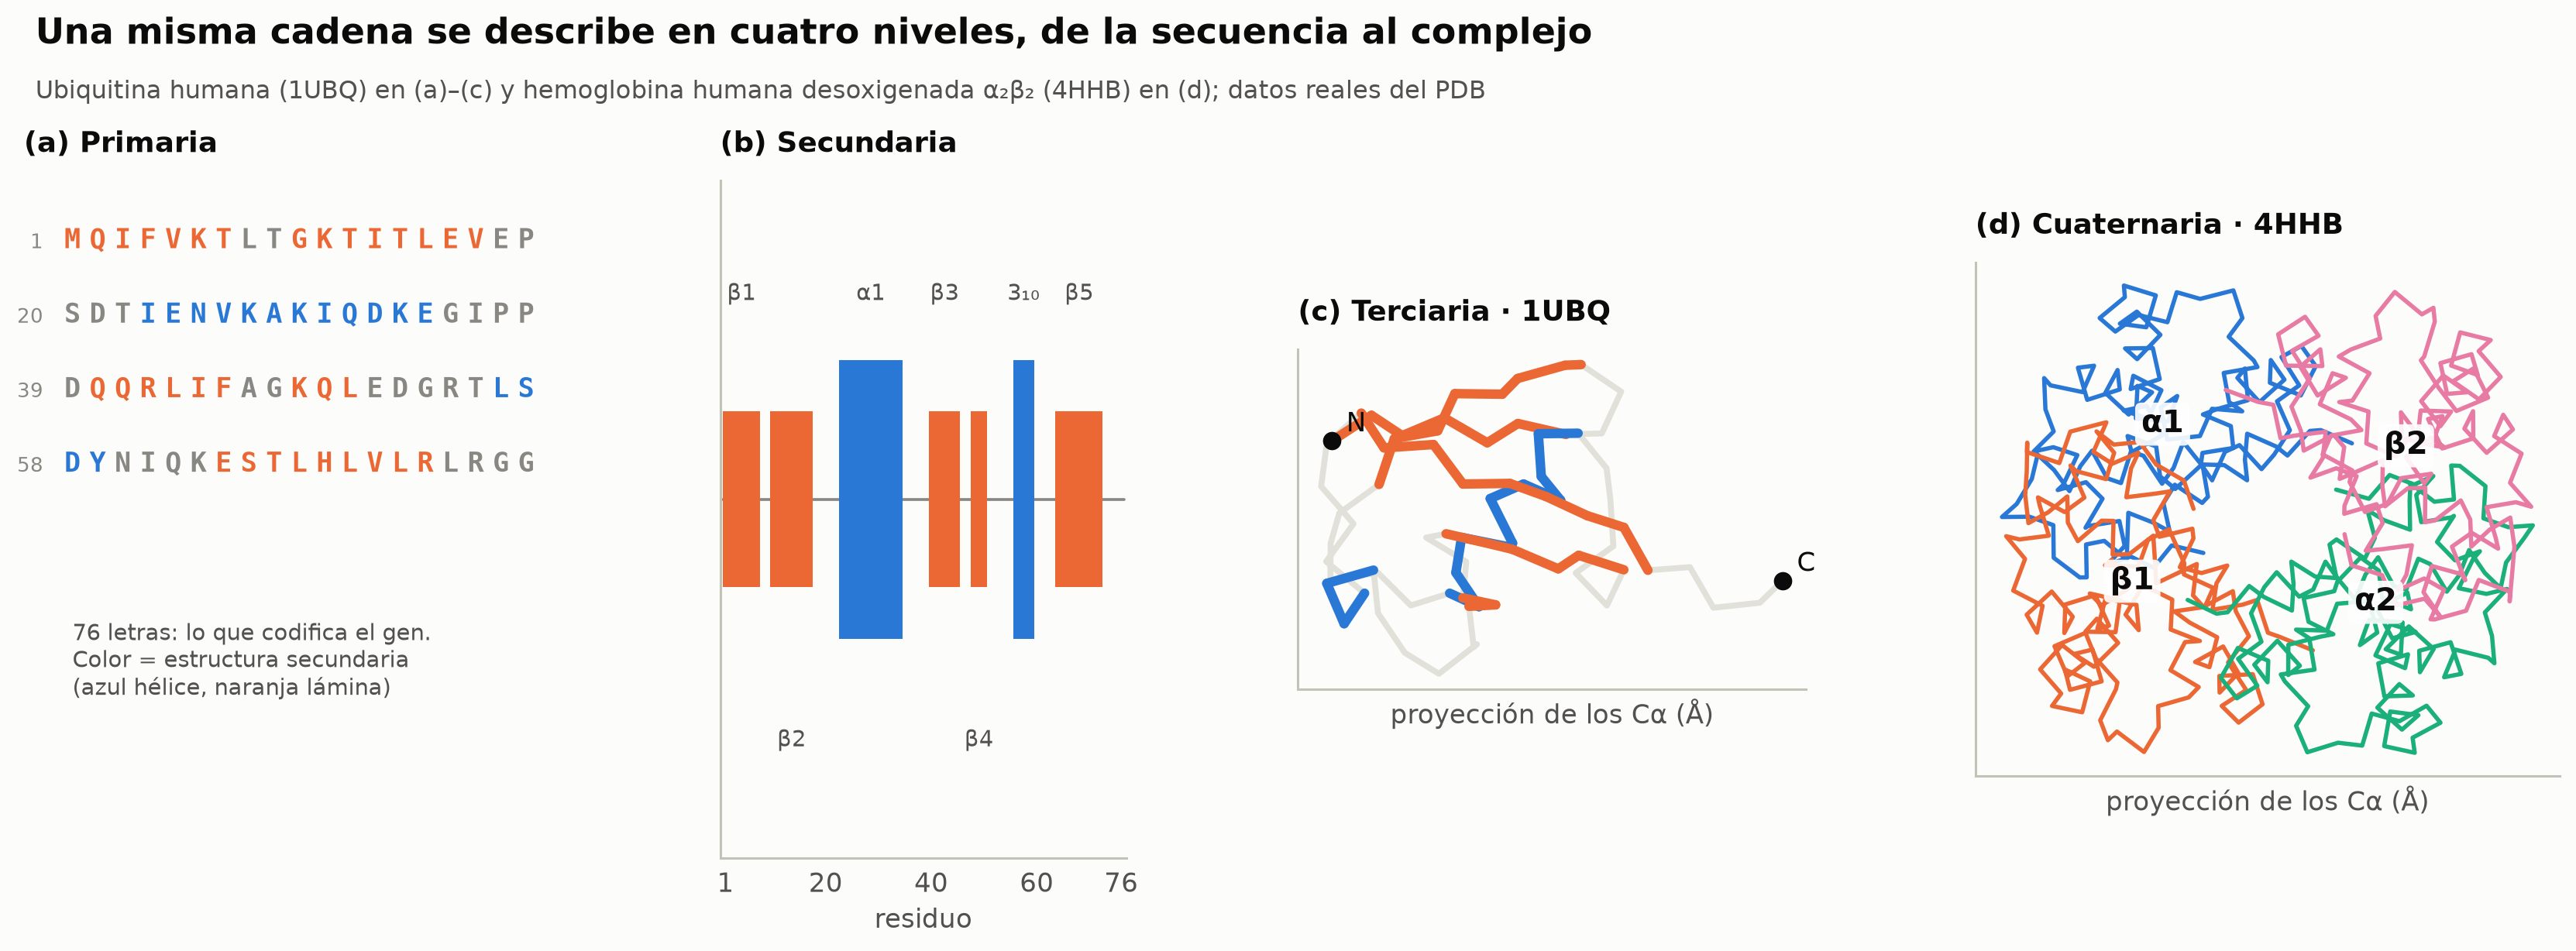

In [3]:
def pca_project(X, ref=None):
    """Proyecta coordenadas 3D sobre el plano de máxima varianza (para dibujarlas en 2D)."""
    ref = X if ref is None else ref
    c = ref.mean(0)
    _, _, Vt = np.linalg.svd(ref - c, full_matrices=False)
    return (X - c) @ Vt[:2].T

SS_COL = {"H": ec.BLUE, "E": ec.ORANGE, "-": ec.MUTED}
fig = plt.figure(figsize=(15, 4.8))
gs = fig.add_gridspec(1, 4, width_ratios=[1.05, 0.8, 1, 1.15], wspace=0.25)

# (a) primaria: la secuencia en filas de 19
ax = fig.add_subplot(gs[0]); ax.axis("off")
for k, aa in enumerate(ubq_seq):
    row, col = divmod(k, 19)
    ax.text(col * 0.052, 0.9 - row * 0.11, aa, fontsize=11.5, family="monospace", ha="center",
            color=SS_COL[ubq_ss_header[k]], fontweight="bold")
    if col == 0:
        ax.text(-0.06, 0.9 - row * 0.11, f"{k + 1}", fontsize=8.5, color=ec.MUTED, ha="right")
ax.text(0.0, 0.35, "76 letras: lo que codifica el gen.\nColor = estructura secundaria\n"
        "(azul hélice, naranja lámina)", fontsize=9.5, color=ec.INK_2, va="top")
ax.set_xlim(-0.1, 1.0); ax.set_ylim(0, 1)
ax.set_title("(a) Primaria", loc="left", fontsize=12)

# (b) secundaria: pista lineal de elementos
ax = fig.add_subplot(gs[1])
for k, s in enumerate(ubq_ss_header):
    if s == "H":
        ax.add_patch(Rectangle((k + 0.5, -0.35), 1, 0.7, color=ec.BLUE, lw=0))
    elif s == "E":
        ax.add_patch(Rectangle((k + 0.5, -0.22), 1, 0.44, color=ec.ORANGE, lw=0))
ax.plot([0.5, 76.5], [0, 0], color=ec.MUTED, lw=1.2, zorder=0)
for (a, b, lab) in [(1, 7, "β1"), (10, 17, "β2"), (23, 34, "α1"), (40, 45, "β3"), (48, 50, "β4"),
                    (56, 59, "3₁₀"), (64, 72, "β5")]:
    ax.text((a + b) / 2, 0.5 if lab[0] != "β" or lab in ("β1", "β3", "β5") else -0.62, lab, ha="center",
            fontsize=9.5, color=ec.INK_2)
ax.set_xlim(0, 77); ax.set_ylim(-0.9, 0.8); ax.set_yticks([])
ax.set_xticks([1, 20, 40, 60, 76]); ax.set_xlabel("residuo")
ax.set_title("(b) Secundaria", loc="left", fontsize=12)
ax.grid(False)

# (c) terciaria: traza de Cα proyectada
ax = fig.add_subplot(gs[2])
xy = pca_project(X_ubq)
ax.plot(xy[:, 0], xy[:, 1], color=ec.GRID, lw=2.5, zorder=1)
for k in range(len(xy) - 1):
    s = ubq_ss_header[k]
    if s != "-" and ubq_ss_header[k + 1] == s:
        ax.plot(xy[k:k + 2, 0], xy[k:k + 2, 1], color=SS_COL[s], lw=4, zorder=2, solid_capstyle="round")
ax.scatter(*xy[0], s=60, color=ec.INK, zorder=3); ax.annotate("N", xy[0], xytext=(6, 4), textcoords="offset points")
ax.scatter(*xy[-1], s=60, color=ec.INK, zorder=3); ax.annotate("C", xy[-1], xytext=(6, 4), textcoords="offset points")
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_xlabel("proyección de los Cα (Å)")
ax.set_title("(c) Terciaria · 1UBQ", loc="left", fontsize=12)

# (d) cuaternaria: 4 cadenas de la hemoglobina
ax = fig.add_subplot(gs[3])
allX = np.vstack([ca_coords(ch)[0] for ch in hbA[0]])
cols = {"A": ec.BLUE, "B": ec.ORANGE, "C": ec.AQUA, "D": ec.MAGENTA}
names = {"A": "α1", "B": "β1", "C": "α2", "D": "β2"}
for ch in hbA[0]:
    xy = pca_project(ca_coords(ch)[0], allX)
    ax.plot(xy[:, 0], xy[:, 1], color=cols[ch.id], lw=1.8)
    ax.text(*xy.mean(0), names[ch.id], fontsize=13, fontweight="bold", color=ec.INK, ha="center",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=cols[ch.id], alpha=0.9))
ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_xlabel("proyección de los Cα (Å)")
ax.set_title("(d) Cuaternaria · 4HHB", loc="left", fontsize=12)
ec.fig_title(fig, "Una misma cadena se describe en cuatro niveles, de la secuencia al complejo",
             "Ubiquitina humana (1UBQ) en (a)–(c) y hemoglobina humana desoxigenada α₂β₂ (4HHB) en (d); datos reales del PDB")
plt.show()

> 🔎 **Qué observamos.** La misma información aparece a cuatro escalas. En (a) la secuencia ya «contiene» la
> estructura, pero no la muestra; en (b) vemos que la ubiquitina alterna cinco hebras $\beta$ con una hélice $\alpha$
> larga (23–34) y una hélice corta $3_{10}$; en (c) esas piezas se empaquetan en un glóbulo compacto, con la
> hélice cruzando sobre la lámina, y la **cola C-terminal** asoma fuera del núcleo (la veremos moverse en la
> sección 9); en (d) cuatro cadenas, dos $\alpha$ y dos $\beta$, forman el tetrámero de la hemoglobina.

## 3. El enlace peptídico y los ángulos diedros

### 3.1 Tres átomos por residuo y un enlace que no gira

Cada aminoácido aporta al esqueleto tres átomos pesados: el **nitrógeno amida** (N), el **carbono alfa**
(C$_\alpha$), que porta la cadena lateral R, y el **carbono carbonílico** (C). Los residuos se unen por un enlace
amida entre el C de uno y el N del siguiente: el **enlace peptídico**.

Por resonancia entre las formas C=O / C–N y C–O$^-$ / C=N$^+$, ese enlace tiene carácter de **doble enlace parcial**:
mide unos **1,33 Å**, más corto que un enlace C–N simple (**1,47 Å**), y **no gira libremente**. En consecuencia, los
seis átomos C$_\alpha$, C, O, N, H y el C$_\alpha$ siguiente quedan en un mismo plano, el **plano peptídico**: son las
placas rígidas del collar. El ángulo de giro alrededor de ese enlace, $\omega$, vale casi siempre **180°**
(configuración *trans*), y toda la libertad del esqueleto se concentra en **dos giros por residuo**:

* $\phi$ (phi), alrededor del enlace N–C$_\alpha$;
* $\psi$ (psi), alrededor del enlace C$_\alpha$–C.

### 3.2 Qué es un ángulo diedro

Imagine un libro abierto apoyado sobre el lomo. Cada tapa es un plano, y el ángulo entre las dos tapas, medido
alrededor del lomo, es un **ángulo diedro**. Con cuatro átomos enlazados en cadena, a–b–c–d, las «tapas» son los
planos (a, b, c) y (b, c, d), y el «lomo» es el enlace central b–c.

**Definición (ecuación 15-diedro del libro).** Dados cuatro átomos consecutivos con posiciones
$\mathbf a,\mathbf b,\mathbf c,\mathbf d\in\mathbb R^3$, sean $\mathbf b_1=\mathbf b-\mathbf a$,
$\mathbf b_2=\mathbf c-\mathbf b$, $\mathbf b_3=\mathbf d-\mathbf c$, y $\mathbf n_1=\mathbf b_1\times\mathbf b_2$,
$\mathbf n_2=\mathbf b_2\times\mathbf b_3$ las normales de los dos planos. El ángulo diedro es

$$
\boxed{\;\theta = \operatorname{atan2}\!\Big( \big(\mathbf n_1\times\mathbf n_2\big)\cdot\frac{\mathbf b_2}{\lVert\mathbf b_2\rVert},\;\; \mathbf n_1\cdot\mathbf n_2 \Big)\in(-180^\circ,180^\circ]\;}
$$

y, para el residuo $i$:

$$
\phi_i=\theta(\mathrm C_{i-1},\mathrm N_i,\mathrm C_{\alpha,i},\mathrm C_i),\qquad
\psi_i=\theta(\mathrm N_i,\mathrm C_{\alpha,i},\mathrm C_i,\mathrm N_{i+1}),\qquad
\omega_i=\theta(\mathrm C_{\alpha,i},\mathrm C_i,\mathrm N_{i+1},\mathrm C_{\alpha,i+1}).
$$

| Símbolo | Significado |
|---|---|
| $\mathbf a,\mathbf b,\mathbf c,\mathbf d$ | coordenadas cartesianas (en Å) de cuatro átomos enlazados en secuencia |
| $\mathbf b_1,\mathbf b_2,\mathbf b_3$ | vectores de enlace; $\mathbf b_2$ es el eje de giro (el «lomo») |
| $\mathbf n_1,\mathbf n_2$ | normales a los planos $(\mathbf a,\mathbf b,\mathbf c)$ y $(\mathbf b,\mathbf c,\mathbf d)$ |
| $\operatorname{atan2}(y,x)$ | arco tangente de dos argumentos: devuelve el ángulo con el signo correcto en los cuatro cuadrantes |
| $\phi_i,\psi_i,\omega_i$ | diedros del esqueleto del residuo $i$ |

¿Por qué $\operatorname{atan2}$ y no simplemente el arco coseno de $\mathbf n_1\cdot\mathbf n_2$? Porque el arco
coseno sólo da valores entre 0° y 180°: no distingue un giro de +60° de uno de −60°. El primer argumento, la
proyección de $\mathbf n_1\times\mathbf n_2$ sobre el eje, aporta el **signo**: mirando a lo largo de $\mathbf b_2$,
un diedro positivo corresponde a un giro en sentido horario del enlace lejano respecto al cercano.

### 3.3 Un diedro a mano

Tomemos cuatro puntos sencillos: $\mathbf a=(1,0,0)$, $\mathbf b=(0,0,0)$, $\mathbf c=(0,0,1)$, $\mathbf d=(0,1,1)$.

1. Vectores de enlace: $\mathbf b_1=\mathbf b-\mathbf a=(-1,0,0)$, $\mathbf b_2=(0,0,1)$, $\mathbf b_3=(0,1,0)$.
2. Normales: $\mathbf n_1=\mathbf b_1\times\mathbf b_2=(0,1,0)$ y $\mathbf n_2=\mathbf b_2\times\mathbf b_3=(-1,0,0)$.
3. $\mathbf n_1\times\mathbf n_2=(0,0,1)$; su proyección sobre $\mathbf b_2/\lVert\mathbf b_2\rVert=(0,0,1)$ vale $y=1$.
4. $x=\mathbf n_1\cdot\mathbf n_2=0$.
5. $\theta=\operatorname{atan2}(1,0)=+90^\circ$.

Si reflejamos $\mathbf d$ a $(0,-1,1)$, el mismo cálculo da $-90^\circ$: el arco coseno habría dado 90° en ambos
casos. Ahora lo programamos y lo comprobamos contra la función de Biopython.

In [4]:
def dihedral(a, b, c, d):
    """Ángulo diedro (grados) de cuatro puntos, ecuación 15-diedro del libro."""
    b1, b2, b3 = b - a, c - b, d - c
    n1, n2 = np.cross(b1, b2), np.cross(b2, b3)
    y = np.dot(np.cross(n1, n2), b2 / np.linalg.norm(b2))
    x = np.dot(n1, n2)
    return math.degrees(math.atan2(y, x))

a, b, c = np.array([1., 0, 0]), np.array([0., 0, 0]), np.array([0., 0, 1])
for d in (np.array([0., 1, 1]), np.array([0., -1, 1])):
    print(f"d = {d} → θ = {dihedral(a, b, c, d):+.1f}°")

# Comprobación con un diedro real: φ del residuo 2 de la ubiquitina
r1, r2 = ubq_chain[1], ubq_chain[2]
mine = dihedral(r1["C"].coord, r2["N"].coord, r2["CA"].coord, r2["C"].coord)
bio = math.degrees(calc_dihedral(r1["C"].get_vector(), r2["N"].get_vector(), r2["CA"].get_vector(), r2["C"].get_vector()))
print(f"φ(Gln2) · nuestra fórmula = {mine:.3f}° · Biopython = {bio:.3f}°")

d = [0. 1. 1.] → θ = +90.0°
d = [ 0. -1.  1.] → θ = -90.0°
φ(Gln2) · nuestra fórmula = -91.020° · Biopython = -91.020°


Con la función validada, calculamos $\phi$, $\psi$ y $\omega$ de **todos** los residuos de la ubiquitina. El libro
lo hace con el constructor de péptidos de Biopython (`PPBuilder`, programa `phi_psi.py`); lo repetimos también así
para comprobar que nuestra implementación coincide con la de la biblioteca.

In [5]:
def backbone_angles(residues):
    """Tabla con φ, ψ, ω (grados) por residuo; NaN en los extremos de la cadena."""
    rows = []
    for k, r in enumerate(residues):
        prev = residues[k - 1] if k > 0 else None
        nxt = residues[k + 1] if k + 1 < len(residues) else None
        phi = dihedral(prev["C"].coord, r["N"].coord, r["CA"].coord, r["C"].coord) if prev else np.nan
        psi = dihedral(r["N"].coord, r["CA"].coord, r["C"].coord, nxt["N"].coord) if nxt else np.nan
        omg = dihedral(r["CA"].coord, r["C"].coord, nxt["N"].coord, nxt["CA"].coord) if nxt else np.nan
        rows.append({"resnum": r.id[1], "resname": r.get_resname(), "aa": seq1(r.get_resname()),
                     "phi": phi, "psi": psi, "omega": omg})
    return pd.DataFrame(rows)

ang_ubq = backbone_angles(ubq_res)
ang_ubq["ss_header"] = ubq_ss_header

# El programa phi_psi.py del libro (PPBuilder), leyendo la copia local en lugar de PDBList
bio_phi_psi = {}
for pp in PPBuilder().build_peptides(ubq[0]):
    for res, (phi, psi) in zip(pp, pp.get_phi_psi_list()):
        if phi is None or psi is None:        # extremos de cadena
            continue
        bio_phi_psi[res.id[1]] = (math.degrees(phi), math.degrees(psi))
cmp = ang_ubq.set_index("resnum").loc[list(bio_phi_psi)]
d_phi = np.abs(cmp["phi"].values - np.array([v[0] for v in bio_phi_psi.values()])).max()
d_psi = np.abs(cmp["psi"].values - np.array([v[1] for v in bio_phi_psi.values()])).max()
print(f"{len(bio_phi_psi)} residuos comparados · diferencia máxima con PPBuilder: φ {d_phi:.1e}°, ψ {d_psi:.1e}°")
ang_ubq.head(8).round(1)

74 residuos comparados · diferencia máxima con PPBuilder: φ 5.3e-06°, ψ 7.3e-06°


,resnum,resname,aa,phi,psi,omega,ss_header
0,1,MET,M,NaN,149.6,178.3,E
1,2,GLN,Q,-91.0,138.3,173.4,E
2,3,ILE,I,-131.1,163.0,179.6,E
3,4,PHE,F,-116.0,140.2,175.8,E
4,5,VAL,V,-118.0,114.2,-178.1,E
5,6,LYS,K,-95.2,127.5,179.9,E
6,7,THR,T,-99.6,170.8,-178.0,E
7,8,LEU,L,-73.4,-6.9,179.9,-


> 🤔 **Antes de ejecutar, prediga.** Si medimos en dos estructuras de alta resolución todas las longitudes de enlace
> del esqueleto, ¿cuál saldrá más corta: N–C$_\alpha$, C$_\alpha$–C o el enlace peptídico C–N? ¿Y cómo se
> repartirán los valores de $\omega$?

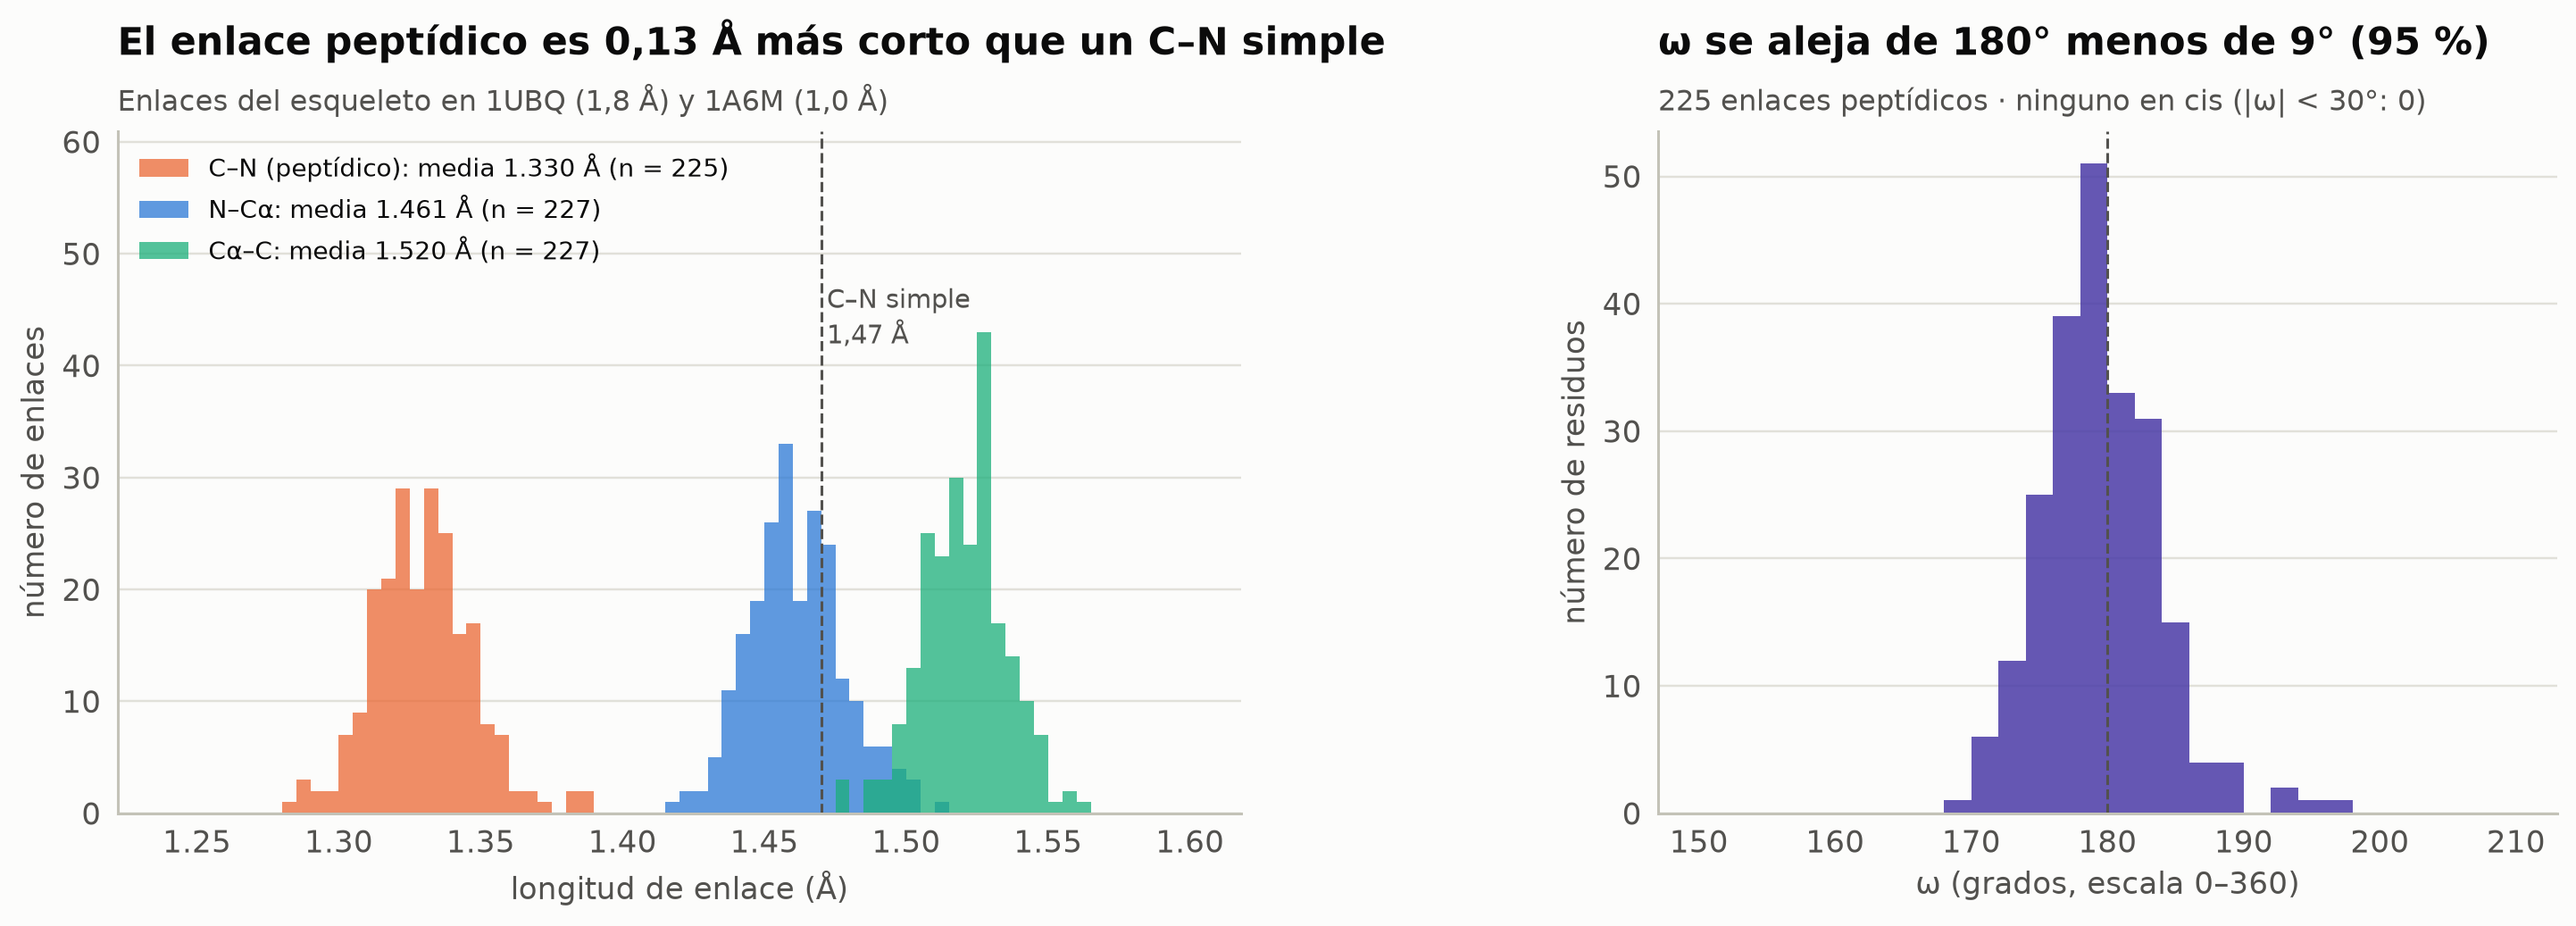

In [6]:
mb_struct = load_structure("1A6M")          # mioglobina de cachalote, 1,0 Å (la usaremos en la sección 11)
bonds = {"C–N (peptídico)": [], "N–Cα": [], "Cα–C": []}
omegas = []
for chain in (ubq_chain, mb_struct[0]["A"]):
    res = protein_residues(chain)
    for k, r in enumerate(res):
        bonds["N–Cα"].append(r["N"] - r["CA"]); bonds["Cα–C"].append(r["CA"] - r["C"])
        if k + 1 < len(res) and res[k + 1].id[1] == r.id[1] + 1:
            bonds["C–N (peptídico)"].append(r["C"] - res[k + 1]["N"])
    omegas += list(backbone_angles(res)["omega"].dropna())
omegas = np.array(omegas)

fig, axs = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw=dict(width_ratios=[1.25, 1], wspace=0.25))
ax = axs[0]
bins = np.linspace(1.24, 1.60, 73)
for (lab, v), col in zip(bonds.items(), [ec.ORANGE, ec.BLUE, ec.AQUA]):
    v = np.array(v)
    ax.hist(v, bins=bins, color=col, alpha=0.75, label=f"{lab}: media {v.mean():.3f} Å (n = {len(v)})")
ax.axvline(1.47, color=ec.INK_2, ls="--", lw=1)
ax.text(1.472, ax.get_ylim()[1] * 0.93, "C–N simple\n1,47 Å", fontsize=9.5, color=ec.INK_2)
ax.set_xlabel("longitud de enlace (Å)"); ax.set_ylabel("número de enlaces")
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.set_ylim(0, ax.get_ylim()[1] * 1.35)
ec.title(ax, "El enlace peptídico es 0,13 Å más corto que un C–N simple",
         "Enlaces del esqueleto en 1UBQ (1,8 Å) y 1A6M (1,0 Å)")
ax = axs[1]
w = ((omegas + 360) % 360)                    # 0–360 para que el pico de 180° no se parta en dos
ax.hist(w, bins=np.arange(150, 211, 2), color=ec.VIOLET, alpha=0.85)
ax.axvline(180, color=ec.INK_2, ls="--", lw=1)
ax.set_xlabel("ω (grados, escala 0–360)"); ax.set_ylabel("número de residuos")
ec.title(ax, f"ω se aleja de 180° menos de {np.percentile(np.abs(180 - w), 95):.0f}° (95 %)",
         f"{len(w)} enlaces peptídicos · ninguno en cis (|ω| < 30°: {np.sum(np.abs(omegas) < 30)})")
plt.show()

> 🔎 **Qué observamos.** El enlace peptídico C–N mide ~1,33 Å, claramente más corto que N–C$_\alpha$ (~1,46 Å) y
> C$_\alpha$–C (~1,52 Å): es el doble enlace parcial en acción. Y $\omega$ se concentra alrededor de 180° con una
> desviación de pocos grados: el plano peptídico es real, no una idealización. Con $\omega$ fijo, una proteína de $n$
> residuos queda descrita, en primera aproximación, por $2n$ números, sus pares $(\phi_i,\psi_i)$, en lugar de las
> $3\times 8n$ coordenadas de sus átomos pesados. Por eso tantas ideas de este capítulo, desde el diagrama de
> Ramachandran hasta los métodos de predicción, trabajan en el espacio de los ángulos.

> ✅ **Compruebe su comprensión.** Las distribuciones de la mioglobina (1,0 Å) son más estrechas que las de la
> ubiquitina (1,8 Å). ¿Por qué? *(Pista: a peor resolución, el refinamiento se apoya más en la geometría ideal y
> los datos restringen menos cada enlace.)*

## 4. El diagrama de Ramachandran

No todos los pares $(\phi,\psi)$ son posibles. En 1963, G. N. Ramachandran, C. Ramakrishnan y V. Sasisekharan
modelaron los átomos como **esferas rígidas** con distancias mínimas de contacto y calcularon, para un dipéptido,
qué combinaciones de ángulos provocan choques entre los átomos del esqueleto y el C$_\beta$ de la cadena lateral.
El resultado, un mapa de regiones permitidas en el plano $(\phi,\psi)$, es el **diagrama de Ramachandran**. Lo
notable es que se obtuvo **antes** de que existieran suficientes estructuras para comprobarlo: es una predicción de
pura estereoquímica, del mismo modo que uno puede saber qué posturas del brazo son imposibles sin ver a nadie
moverse, sólo mirando el esqueleto y las articulaciones.

Usaremos los mismos datos que la figura del libro: **19 460 residuos** de **79 estructuras cristalográficas** del
PDB con resolución igual o mejor que **1,0 Å**, con su estructura secundaria asignada por DSSP (el programa que
reconstruiremos en la sección 5). Los datos se descargaron del RCSB y se procesaron con `figuras/cap15/generar.py`
del libro; aquí cargamos la tabla resultante.

In [7]:
rama = np.load(io.BytesIO(course_bytes("151_rama_libro.npz")))
phi, psi, ss, aa = rama["phi"], rama["psi"], rama["ss"], rama["aa"]
hel = np.isin(ss, ["H", "G", "I"]); lam = np.isin(ss, ["E", "B"]); gly = aa == "G"; pro = aa == "P"
print(f"residuos: {len(phi):,}")
print(f"hélice (H/G/I) = {hel.mean():.1%} · lámina (E/B) = {lam.mean():.1%} · giros y lazos = {1 - hel.mean() - lam.mean():.1%}")
H_, E_ = ss == "H", ss == "E"
print(f"hélice α (H):  φ̄ = {phi[H_].mean():6.1f}°, ψ̄ = {psi[H_].mean():6.1f}°")
print(f"lámina (E):    φ̄ = {phi[E_].mean():6.1f}°, ψ̄ = {psi[E_].mean():6.1f}°")
print(f"φ > 0: glicina {np.mean(phi[gly] > 0):.1%} · resto {np.mean(phi[~gly] > 0):.1%}")
print(f"prolina: φ̄ = {phi[pro].mean():.1f}°, desviación típica {phi[pro].std():.1f}°")

residuos: 19,460
hélice (H/G/I) = 30.9% · lámina (E/B) = 25.8% · giros y lazos = 43.3%
hélice α (H):  φ̄ =  -64.6°, ψ̄ =  -39.8°
lámina (E):    φ̄ = -110.5°, ψ̄ =  121.0°
φ > 0: glicina 55.1% · resto 3.4%
prolina: φ̄ = -67.3°, desviación típica 10.7°


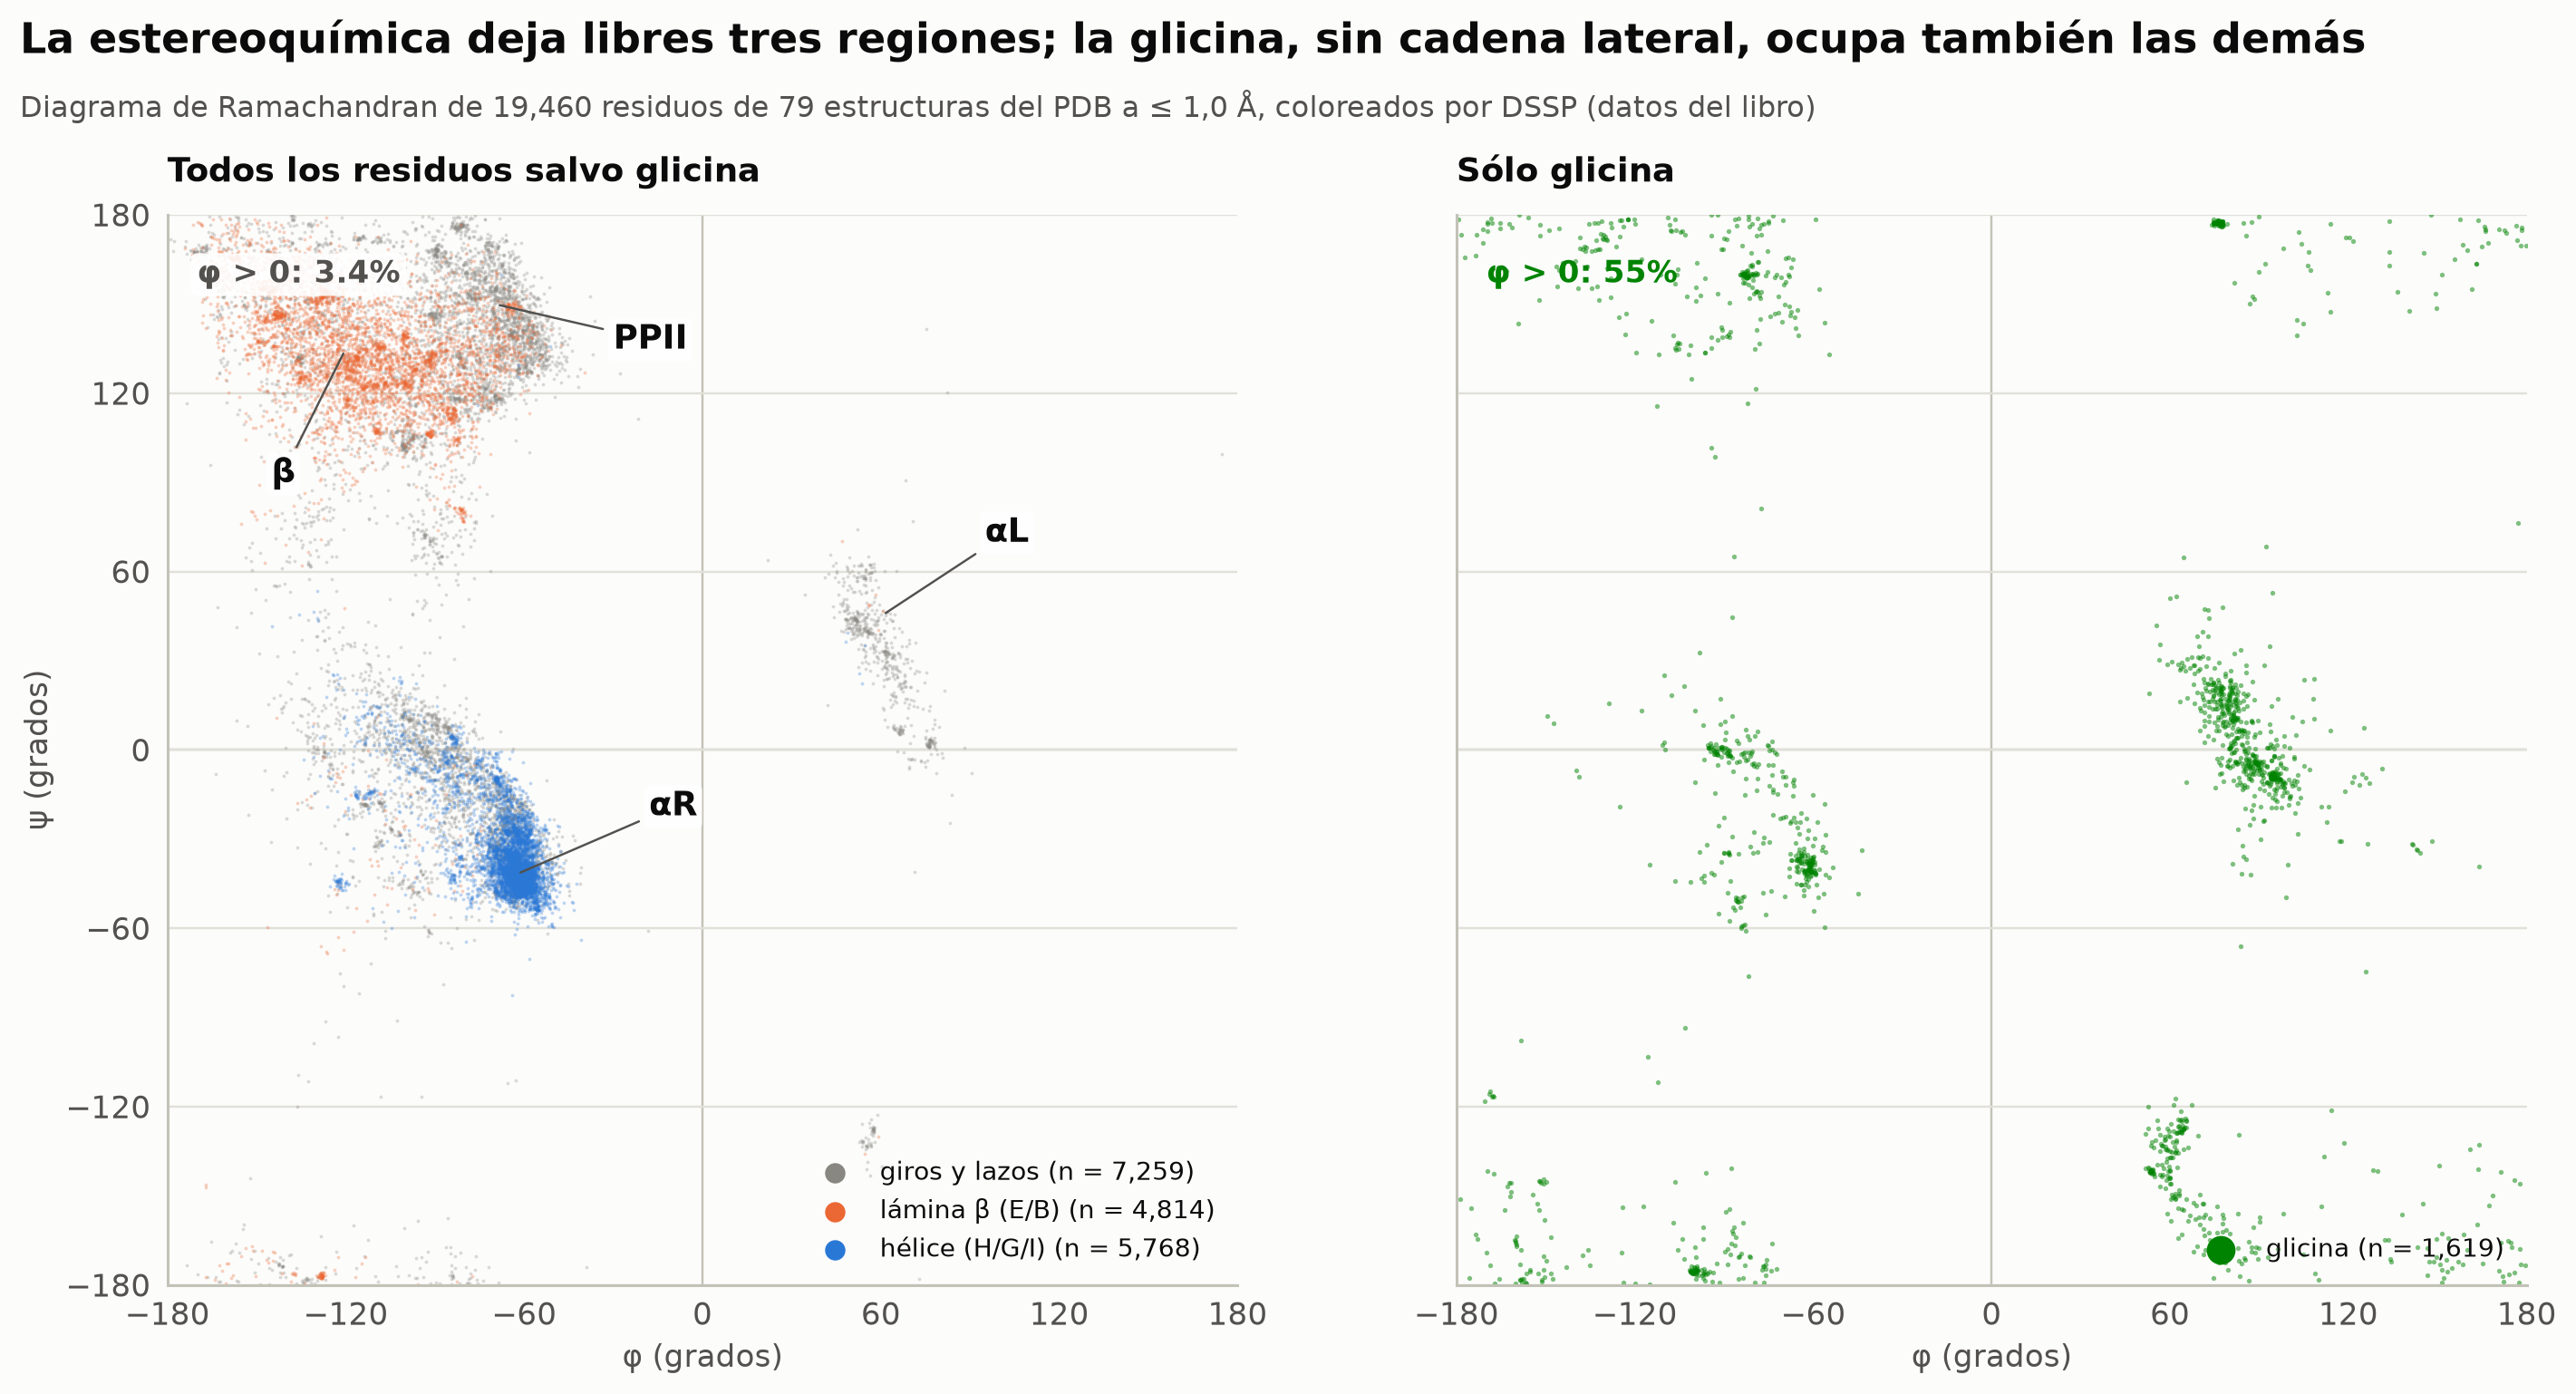

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 6.2), sharey=True, gridspec_kw=dict(wspace=0.08))
oth = ~(hel | lam)
for ax, sets, ttl in [
        (axs[0], [(oth & ~gly, ec.MUTED, "giros y lazos"), (lam & ~gly, ec.ORANGE, "lámina β (E/B)"),
                  (hel & ~gly, ec.BLUE, "hélice (H/G/I)")], "Todos los residuos salvo glicina"),
        (axs[1], [(gly, ec.GREEN, "glicina")], "Sólo glicina")]:
    for m, col, lab in sets:
        ax.scatter(phi[m], psi[m], s=3 if lab == "glicina" else 1.5, c=col, alpha=0.5 if lab == "glicina" else 0.3,
                   lw=0, rasterized=True, label=f"{lab} (n = {m.sum():,})")
    ax.set_xlim(-180, 180); ax.set_ylim(-180, 180)
    ax.set_xticks(range(-180, 181, 60)); ax.set_yticks(range(-180, 181, 60))
    ax.axhline(0, color=ec.BASELINE, lw=0.8, zorder=0); ax.axvline(0, color=ec.BASELINE, lw=0.8, zorder=0)
    ax.set_xlabel("φ (grados)"); ax.set_aspect("equal")
    ax.set_title(ttl, loc="left", fontsize=12)
    leg = ax.legend(loc="lower right", fontsize=9, markerscale=6, framealpha=0.95)
    for lh in leg.legend_handles:
        lh.set_alpha(1)
axs[0].set_ylabel("ψ (grados)")
for txt, x, y, dx, dy in [("αR", -63, -42, 45, 20), ("β", -120, 135, -25, -45), ("αL", 60, 45, 35, 25),
                          ("PPII", -70, 150, 40, -15)]:
    axs[0].annotate(txt, (x, y), xytext=(x + dx, y + dy), fontsize=12, fontweight="bold", color=ec.INK,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85),
                    arrowprops=dict(arrowstyle="-", lw=0.8, color=ec.INK_2))
axs[1].text(-170, 165, f"φ > 0: {np.mean(phi[gly] > 0):.0%}", fontsize=11, color=ec.GREEN, fontweight="bold", va="top")
axs[0].text(-170, 165, f"φ > 0: {np.mean(phi[~gly] > 0):.1%}", fontsize=11, color=ec.INK_2, fontweight="bold", va="top",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.9))
ec.fig_title(fig, "La estereoquímica deja libres tres regiones; la glicina, sin cadena lateral, ocupa también las demás",
             f"Diagrama de Ramachandran de {len(phi):,} residuos de 79 estructuras del PDB a ≤ 1,0 Å, coloreados por DSSP (datos del libro)")
plt.show()

> 🔎 **Qué observamos.** Tres regiones concentran casi todos los puntos:
>
> * **Hélice derecha** ($\alpha_R$), en torno a $(-63^\circ,-42^\circ)$; en estos datos los residuos en hélice $\alpha$
>   tienen $\bar\phi=-64{,}6^\circ$ y $\bar\psi=-39{,}8^\circ$.
> * **Región $\beta$**, amplia, en el cuadrante $\phi<0,\ \psi>0$: $\bar\phi=-110{,}5^\circ$, $\bar\psi=121{,}0^\circ$.
>   En su borde, cerca de $(-75^\circ,145^\circ)$, está la **hélice de poliprolina II** (PPII), frecuente en lazos y
>   regiones desordenadas.
> * **Hélice izquierda** ($\alpha_L$), cerca de $(60^\circ,45^\circ)$, poco poblada y ocupada sobre todo por glicina,
>   asparagina y aspartato.
>
> Dos residuos son especiales. La **glicina**, cuya «cadena lateral» es un solo hidrógeno, no sufre el choque con el
> C$_\beta$: el **55 %** de sus residuos tiene $\phi>0$, frente al **3,4 %** del resto, y por eso es la bisagra
> preferida de los giros cerrados. La **prolina** tiene un anillo que se cierra sobre su propio nitrógeno y
> **bloquea** $\phi$: $\bar\phi_{\mathrm{Pro}}=-67{,}3^\circ$ con una desviación típica de sólo 10,7°. Por eso rompe
> hélices y aparece en los extremos de las láminas.

### 4.1 Nuestra ubiquitina sobre el mapa de referencia

> 🤔 **Antes de ejecutar, prediga.** ¿Dónde caerán los residuos 23–34 de la ubiquitina (su hélice)? ¿Y las
> glicinas 10, 35, 47, 75 y 76? ¿Habrá algún residuo que no sea glicina con $\phi>0$?

En la figura interactiva, las curvas de nivel muestran la densidad de los 19 460 residuos de referencia (sin
glicina) y cada punto es un residuo de 1UBQ. **Pase el cursor** por los puntos: verá el residuo, sus ángulos y
la estructura secundaria declarada por los autores.

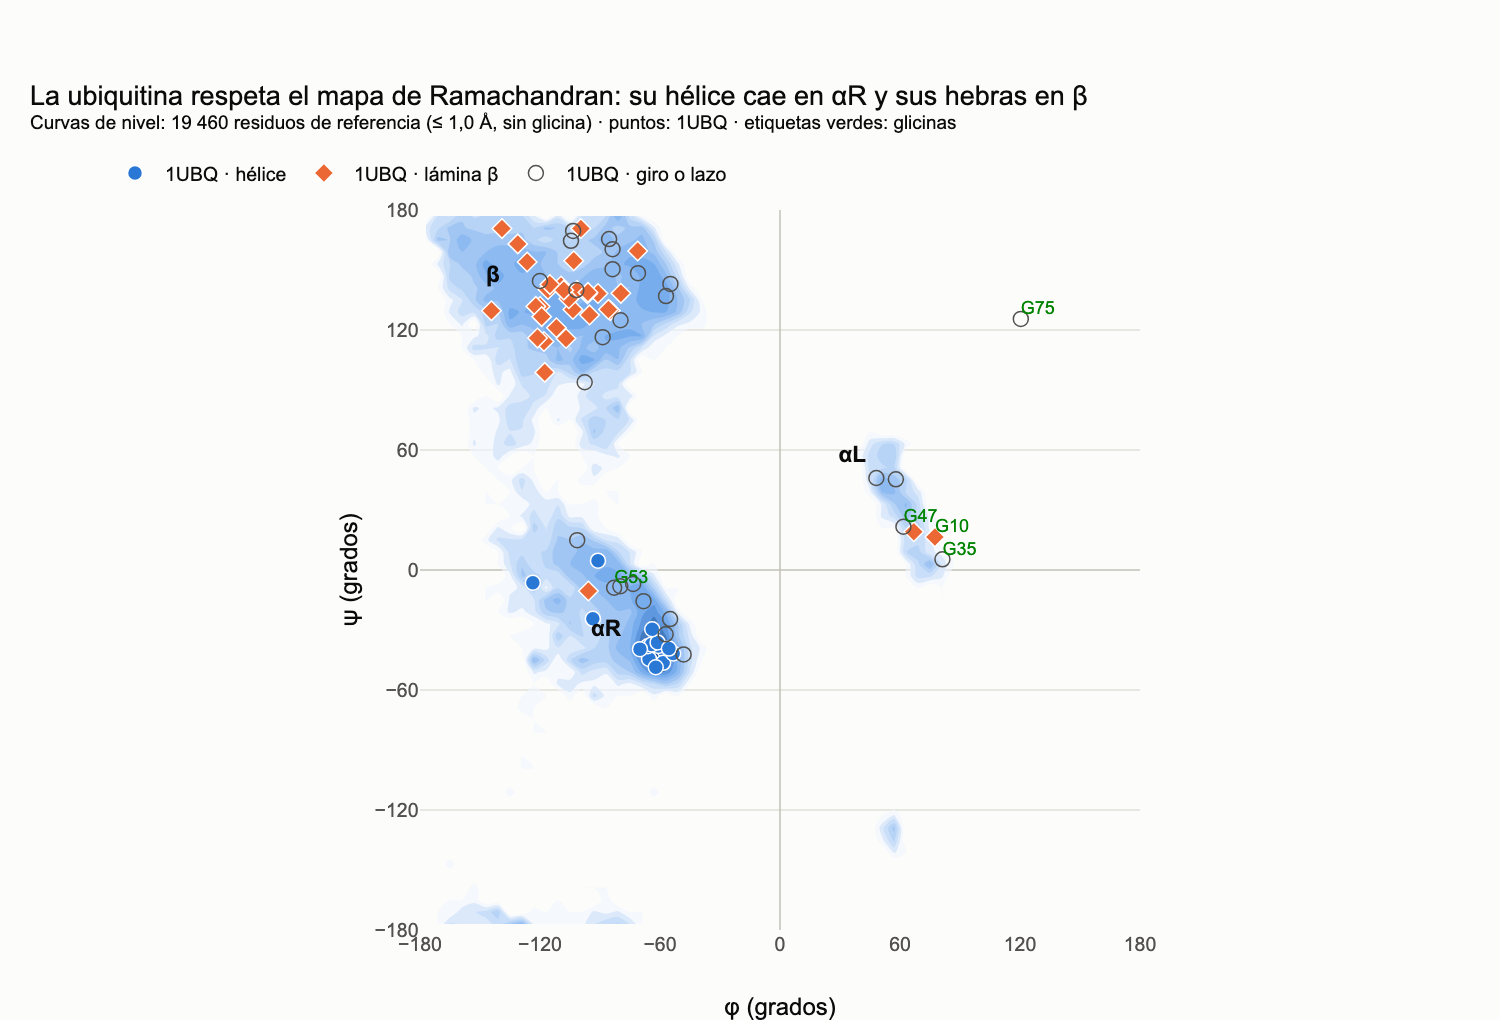

Residuos de 1UBQ con φ > 0: GLY10 (φ=77°, ψ=17°), GLY35 (φ=81°, ψ=5°), ALA46 (φ=48°, ψ=46°), GLY47 (φ=62°, ψ=22°), ASN60 (φ=58°, ψ=45°), GLU64 (φ=67°, ψ=19°), GLY75 (φ=120°, ψ=126°), GLY76 (φ=174°, ψ indefinido: último residuo)


In [9]:
ref = ~gly
fig = go.Figure()
# densidad de referencia en escala logarítmica (así se ven también las regiones poco pobladas)
edges = np.arange(-180, 181, 6)
Hd, _, _ = np.histogram2d(phi[ref], psi[ref], bins=[edges, edges])
centers = (edges[:-1] + edges[1:]) / 2
fig.add_trace(go.Contour(
    x=centers, y=centers, z=np.log10(1 + Hd.T), zmin=0.3, zmax=np.log10(1 + Hd.max()),
    colorscale=[[0, "rgba(252,252,251,0)"], [0.08, "#e8f1fc"], [0.35, "#b7d3f6"], [0.7, "#6da7ec"], [1, "#184f95"]],
    contours=dict(coloring="fill", showlines=False, start=0.3, end=float(np.log10(1 + Hd.max())), size=0.25),
    showscale=False, hoverinfo="skip", line_smoothing=0.8, name="referencia (19 460 residuos, sin Gly)"))
ss_name = {"H": "hélice", "E": "lámina β", "-": "giro o lazo"}
for s, col, sym in [("H", ec.BLUE, "circle"), ("E", ec.ORANGE, "diamond"), ("-", ec.INK_2, "circle-open")]:
    d = ang_ubq[(ang_ubq["ss_header"] == s)].dropna(subset=["phi", "psi"])
    fig.add_trace(go.Scatter(
        x=d["phi"], y=d["psi"], mode="markers", name=f"1UBQ · {ss_name[s]}",
        marker=dict(color=col, size=10, symbol=sym, line=dict(color="white", width=1)),
        customdata=np.c_[d["resname"], d["resnum"], d["omega"]],
        hovertemplate=("<b>%{customdata[0]} %{customdata[1]}</b> · " + ss_name[s] +
                       "<br>φ = %{x:.1f}°, ψ = %{y:.1f}°<br>ω = %{customdata[2]:.1f}°<extra></extra>")))
gl = ang_ubq[ang_ubq["aa"] == "G"].dropna(subset=["phi", "psi"])
fig.add_trace(go.Scatter(x=gl["phi"], y=gl["psi"], mode="text", text=["G" + str(n) for n in gl["resnum"]],
                         textposition="top right", textfont=dict(color=ec.GREEN, size=12), showlegend=False,
                         hoverinfo="skip"))
for txt, x, y in [("αR", -63, -42), ("β", -120, 135), ("αL", 60, 45)]:
    fig.add_annotation(x=x, y=y, text=f"<b>{txt}</b>", showarrow=False, font=dict(size=15, color=ec.INK),
                       xshift=-32, yshift=18)
fig.update_layout(
    title="La ubiquitina respeta el mapa de Ramachandran: su hélice cae en αR y sus hebras en β"
          "<br><sup>Curvas de nivel: 19 460 residuos de referencia (≤ 1,0 Å, sin glicina) · puntos: 1UBQ · etiquetas verdes: glicinas</sup>",
    xaxis=dict(title="φ (grados)", range=[-180, 180], dtick=60, zeroline=True, zerolinecolor=ec.BASELINE,
               constrain="domain"),
    yaxis=dict(title="ψ (grados)", range=[-180, 180], dtick=60, zeroline=True, zerolinecolor=ec.BASELINE,
               scaleanchor="x", scaleratio=1),
    height=680, width=820, legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
    margin=dict(t=140, l=70, r=30, b=60))
fig.show()

pos = ang_ubq[(ang_ubq["phi"] > 0)]
print("Residuos de 1UBQ con φ > 0:", ", ".join(f"{r.resname}{r.resnum} (φ={r.phi:.0f}°" + (f", ψ={r.psi:.0f}°)" if not np.isnan(r.psi) else ", ψ indefinido: último residuo)") for r in pos.itertuples()))

> 🔎 **Qué observamos.** Los residuos de la hélice 23–34 se apiñan en $\alpha_R$ y los de las hebras en la región
> $\beta$, justo sobre las zonas más densas del mapa de referencia. De los ocho residuos con $\phi>0$, **cinco son
> glicinas** (G10 en el giro entre β1 y β2, G35 al final de la hélice, G47 en el giro entre β3 y β4, y G75–G76 en
> la cola). Los otros tres (A46, N60 y E64) caen en la isla $\alpha_L$, y uno de ellos es una asparagina, como
> anunciaba el libro. La G75 incluso ocupa una región ($\phi\approx120^\circ$, $\psi\approx126^\circ$) prohibida
> para cualquier residuo con C$_\beta$.

> ⚠️ **Un residuo en zona prohibida no es necesariamente un error.** El diagrama de Ramachandran es la primera
> herramienta de validación de una estructura: un modelo con muchos residuos fuera de las regiones permitidas
> probablemente está mal construido. Pero una fracción pequeña de residuos atípicos (*outliers*) aparece incluso en
> estructuras excelentes, casi siempre por una razón funcional: un residuo tensionado en un sitio activo, o una
> conformación forzada por la unión de un ligando. La pregunta correcta ante un *outlier* es si la **densidad
> electrónica** lo respalda.

## 5. Hélices, láminas y DSSP desde cero

### 5.1 Por qué esas regiones y no otras

Las regiones $\alpha_R$ y $\beta$ son las que permiten que los grupos N–H y C=O del esqueleto, que de otro modo
quedarían «insatisfechos» en el interior hidrofóbico de la proteína, formen **puentes de hidrógeno entre sí de forma
regular**. En 1951, antes de que se resolviera ninguna estructura de proteína, Pauling, Corey y Branson dedujeron la
**hélice $\alpha$** a partir de tres restricciones: enlace peptídico plano, puentes de hidrógeno lineales entre el
C=O del residuo $i$ y el N–H del residuo $i+4$, y equivalencia de todos los residuos. La hélice resultante avanza
unos **1,5 Å por residuo** y tiene **3,6 residuos por vuelta**, un paso de $3{,}6\times1{,}5=5{,}4$ Å. Todos los N–H
apuntan hacia el extremo N y todos los C=O hacia el C: la hélice entera es un pequeño **dipolo**. En las **láminas
$\beta$**, en cambio, los puentes se forman *entre* hebras extendidas vecinas, paralelas o antiparalelas.

> 📜 **El modelo antes que el dato.** Pauling contaba que concibió la hélice $\alpha$ en 1948, convaleciente de un
> resfriado en Oxford, doblando una hoja de papel en la que había dibujado una cadena con las distancias y ángulos
> correctos. Cuando Kendrew y colaboradores publicaron en 1958 el primer modelo tridimensional de una proteína, la
> **mioglobina** de cachalote a 6 Å, las varillas de densidad que recorrían la molécula eran, precisamente, hélices
> $\alpha$. Usaremos la mioglobina moderna (1A6M, 1,0 Å) en la sección 11.

### 5.2 La energía de puente de hidrógeno de DSSP

Mirar una estructura y decir «esto es una hélice» parece trivial, pero dos expertos pueden discrepar en los extremos.
Kabsch y Sander (1983) sustituyeron el juicio visual por un algoritmo, **DSSP**, que primero identifica los puentes
de hidrógeno del esqueleto con un modelo electrostático sencillo y después reconoce patrones en ellos.

**Definición (ecuación 15-dssp del libro).** Para un grupo C=O y un grupo N–H del esqueleto, se colocan cargas
parciales $\pm q_1$ en C y O, y $\pm q_2$ en N y H. La energía electrostática de interacción es

$$
\boxed{\;E = f\,q_1 q_2\left(\frac{1}{r_{\mathrm{ON}}}+\frac{1}{r_{\mathrm{CH}}}-\frac{1}{r_{\mathrm{OH}}}-\frac{1}{r_{\mathrm{CN}}}\right)\;}
$$

y se declara un puente de hidrógeno si $E<-0{,}5$ kcal/mol.

| Símbolo | Significado |
|---|---|
| $q_1,\,q_2$ | cargas parciales: $q_1=0{,}42e$ en el carbonilo y $q_2=0{,}20e$ en la amida |
| $f$ | factor dimensional, 332 kcal·Å/(mol·$e^2$), que expresa la energía en kcal/mol |
| $r_{XY}$ | distancia (en Å) entre los átomos $X$ e $Y$ de los dos grupos |

Así, $f\,q_1q_2=332\times0{,}42\times0{,}20=27{,}888$ kcal·Å/mol. Los términos con signo $+$ son pares de cargas del
mismo signo (O$^-$ y N$^-$, C$^+$ y H$^+$), que se repelen; los de signo $-$ son pares opuestos (O$^-$ y H$^+$, C$^+$ y
N$^-$), que se atraen. Un puente de hidrógeno bien formado acerca mucho el O al H, y el término $-1/r_{\mathrm{OH}}$
domina.

Los archivos de rayos X de esta época casi nunca traen los hidrógenos. DSSP los coloca por convención: a 1,0 Å del
N, en la dirección opuesta al C=O del residuo anterior (porque el enlace peptídico es plano),
$\mathbf H_i = \mathbf N_i + (\mathbf C_{i-1}-\mathbf O_{i-1})/\lVert\mathbf C_{i-1}-\mathbf O_{i-1}\rVert$. La prolina
no tiene H en el nitrógeno y no puede donar puentes.

**A mano, con un puente real de la hélice de la ubiquitina.** Tomemos el par canónico $i\to i+4$ del centro de la
hélice: el C=O de la Lys27 y el N–H de la Gln31. El código sólo mide las cuatro distancias; la cuenta la hacemos
nosotros, término a término, igual que en el papel.

In [10]:
F_Q1Q2 = 332 * 0.42 * 0.20        # f·q1·q2 = 27,888 kcal·Å/mol

def backbone_arrays(residues):
    """Coordenadas N, CA, C, O e hidrógeno amida colocado a la manera de DSSP (NaN en Pro y en el primer residuo)."""
    N = np.array([r["N"].coord for r in residues], float)
    CA = np.array([r["CA"].coord for r in residues], float)
    C = np.array([r["C"].coord for r in residues], float)
    O = np.array([r["O"].coord for r in residues], float)
    Hn = np.full_like(N, np.nan)
    for k in range(1, len(residues)):
        if residues[k].get_resname() != "PRO":
            v = C[k - 1] - O[k - 1]
            Hn[k] = N[k] + v / np.linalg.norm(v)
    return N, CA, C, O, Hn

def hbond_energy_matrix(residues):
    """E[i, j] = energía (kcal/mol) entre el C=O del residuo i y el N–H del residuo j (ecuación 15-dssp)."""
    N, CA, C, O, Hn = backbone_arrays(residues)
    dist = lambda A, B: np.linalg.norm(A[:, None, :] - B[None, :, :], axis=2)
    with np.errstate(invalid="ignore"):
        E = F_Q1Q2 * (1 / dist(O, N) + 1 / dist(C, Hn) - 1 / dist(O, Hn) - 1 / dist(C, N))
    n = len(residues)
    ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    E[np.abs(ii - jj) < 3] = 0.0                 # vecinos inmediatos: no cuentan
    return np.nan_to_num(E, nan=0.0), (N, CA, C, O, Hn)

E_ubq, (N_, CA_, C_, O_, H_) = hbond_energy_matrix(ubq_res)
i, j = 26, 30                                    # índices 0-based: Lys27 (C=O) y Gln31 (N–H)
r = {"ON": np.linalg.norm(O_[i] - N_[j]), "CH": np.linalg.norm(C_[i] - H_[j]),
     "OH": np.linalg.norm(O_[i] - H_[j]), "CN": np.linalg.norm(C_[i] - N_[j])}
print(f"C=O de {ubq_res[i].get_resname()}{ubq_res[i].id[1]} → N–H de {ubq_res[j].get_resname()}{ubq_res[j].id[1]}")
for k_, v in r.items():
    print(f"  r_{k_} = {v:.3f} Å   1/r = {1 / v:.4f}")
suma = 1 / r["ON"] + 1 / r["CH"] - 1 / r["OH"] - 1 / r["CN"]
print(f"  suma = {suma:+.4f} Å⁻¹  →  E = 27,888 × ({suma:+.4f}) = {F_Q1Q2 * suma:+.2f} kcal/mol "
      f"({'SÍ' if F_Q1Q2 * suma < -0.5 else 'no'} es puente, umbral −0,5)")

C=O de LYS27 → N–H de GLN31
  r_ON = 2.926 Å   1/r = 0.3418
  r_CH = 3.092 Å   1/r = 0.3235
  r_OH = 2.042 Å   1/r = 0.4898
  r_CN = 4.046 Å   1/r = 0.2472
  suma = -0.0718 Å⁻¹  →  E = 27,888 × (-0.0718) = -2.00 kcal/mol (SÍ es puente, umbral −0,5)


### 5.3 De los puentes a los patrones

Con la matriz de puentes, DSSP define:

* un **giro $n$** en $i$ si hay un puente entre el C=O de $i$ y el N–H de $i+n$ ($n=3,4,5$);
* una **hélice $\alpha$** (código `H`) cuando hay dos giros de tipo 4 consecutivos, en $i-1$ e $i$: los residuos
  $i,\dots,i+3$ se marcan `H`; con giros de tipo 3 se obtiene la hélice $3_{10}$ (`G`), y con los de tipo 5, la
  hélice $\pi$ (`I`);
* un **puente $\beta$** entre $i$ y $j$ cuando dos puentes de hidrógeno los unen según uno de dos patrones:
  antiparalelo [$i\to j$ y $j\to i$] o [$i-1\to j+1$ y $j-1\to i+1$]; paralelo [$i-1\to j$ y $j\to i+1$] o
  [$j-1\to i$ y $i\to j+1$];
* una **lámina** (`E`) cuando hay una escalera de puentes consecutivos, y un **puente aislado** (`B`) si no.

Los códigos `T` (giro), `S` (curvatura) y el espacio en blanco completan el alfabeto. Programamos una versión
reducida (H, G, E, B) y la comparamos con la asignación que los autores escribieron en el archivo de 1UBQ.

In [11]:
def mini_dssp(E, threshold=-0.5):
    """Asignación reducida de DSSP (H, G, E, B, '-') a partir de la matriz de energías E[i, j]."""
    n = len(E)
    hb = E < threshold
    HB = lambda a, b: 0 <= a < n and 0 <= b < n and hb[a, b]
    turn = {m: np.array([HB(i, i + m) for i in range(n)]) for m in (3, 4)}
    ss = np.array(["-"] * n)
    for m, code in ((3, "G"), (4, "H")):          # H se escribe después y tiene prioridad sobre G
        for i in range(1, n):
            if turn[m][i - 1] and turn[m][i]:
                ss[i:i + m] = code
    partners = [set() for _ in range(n)]
    for i in range(1, n - 1):
        for j in range(i + 3, n - 1):
            anti = (HB(i, j) and HB(j, i)) or (HB(i - 1, j + 1) and HB(j - 1, i + 1))
            para = (HB(i - 1, j) and HB(j, i + 1)) or (HB(j - 1, i) and HB(i, j + 1))
            if anti or para:
                partners[i].add(j); partners[j].add(i)
    for i in range(n):
        if partners[i] and ss[i] != "H":
            ladder = any((i + s) < n and (i + s) >= 0 and
                         any((p + t) in partners[i + s] for p in partners[i] for t in (-1, 1))
                         for s in (-1, 1))
            ss[i] = "E" if ladder else "B"
    return ss, hb

ubq_ss_dssp, ubq_hb = mini_dssp(E_ubq)
print("autores :", "".join(ubq_ss_header))
print("mini-DSSP:", "".join(ubq_ss_dssp))
simple = np.where(np.isin(ubq_ss_dssp, ["H", "G"]), "H", np.where(np.isin(ubq_ss_dssp, ["E", "B"]), "E", "-"))
print(f"coincidencia en 3 estados (hélice / lámina / otro): {np.mean(simple == ubq_ss_header):.0%} · "
      f"puentes de hidrógeno del esqueleto: {ubq_hb.sum()}")

autores : EEEEEEE--EEEEEEEE-----HHHHHHHHHHHH-----EEEEEE--EEE-----HHHH----EEEEEEEEE----
mini-DSSP: -EEEEEE----EEEEE-----BHHHHHHHHHHHH---GGGEEEEE--EE-----B-GGG------EEEEEE-----
coincidencia en 3 estados (hélice / lámina / otro): 82% · puentes de hidrógeno del esqueleto: 47


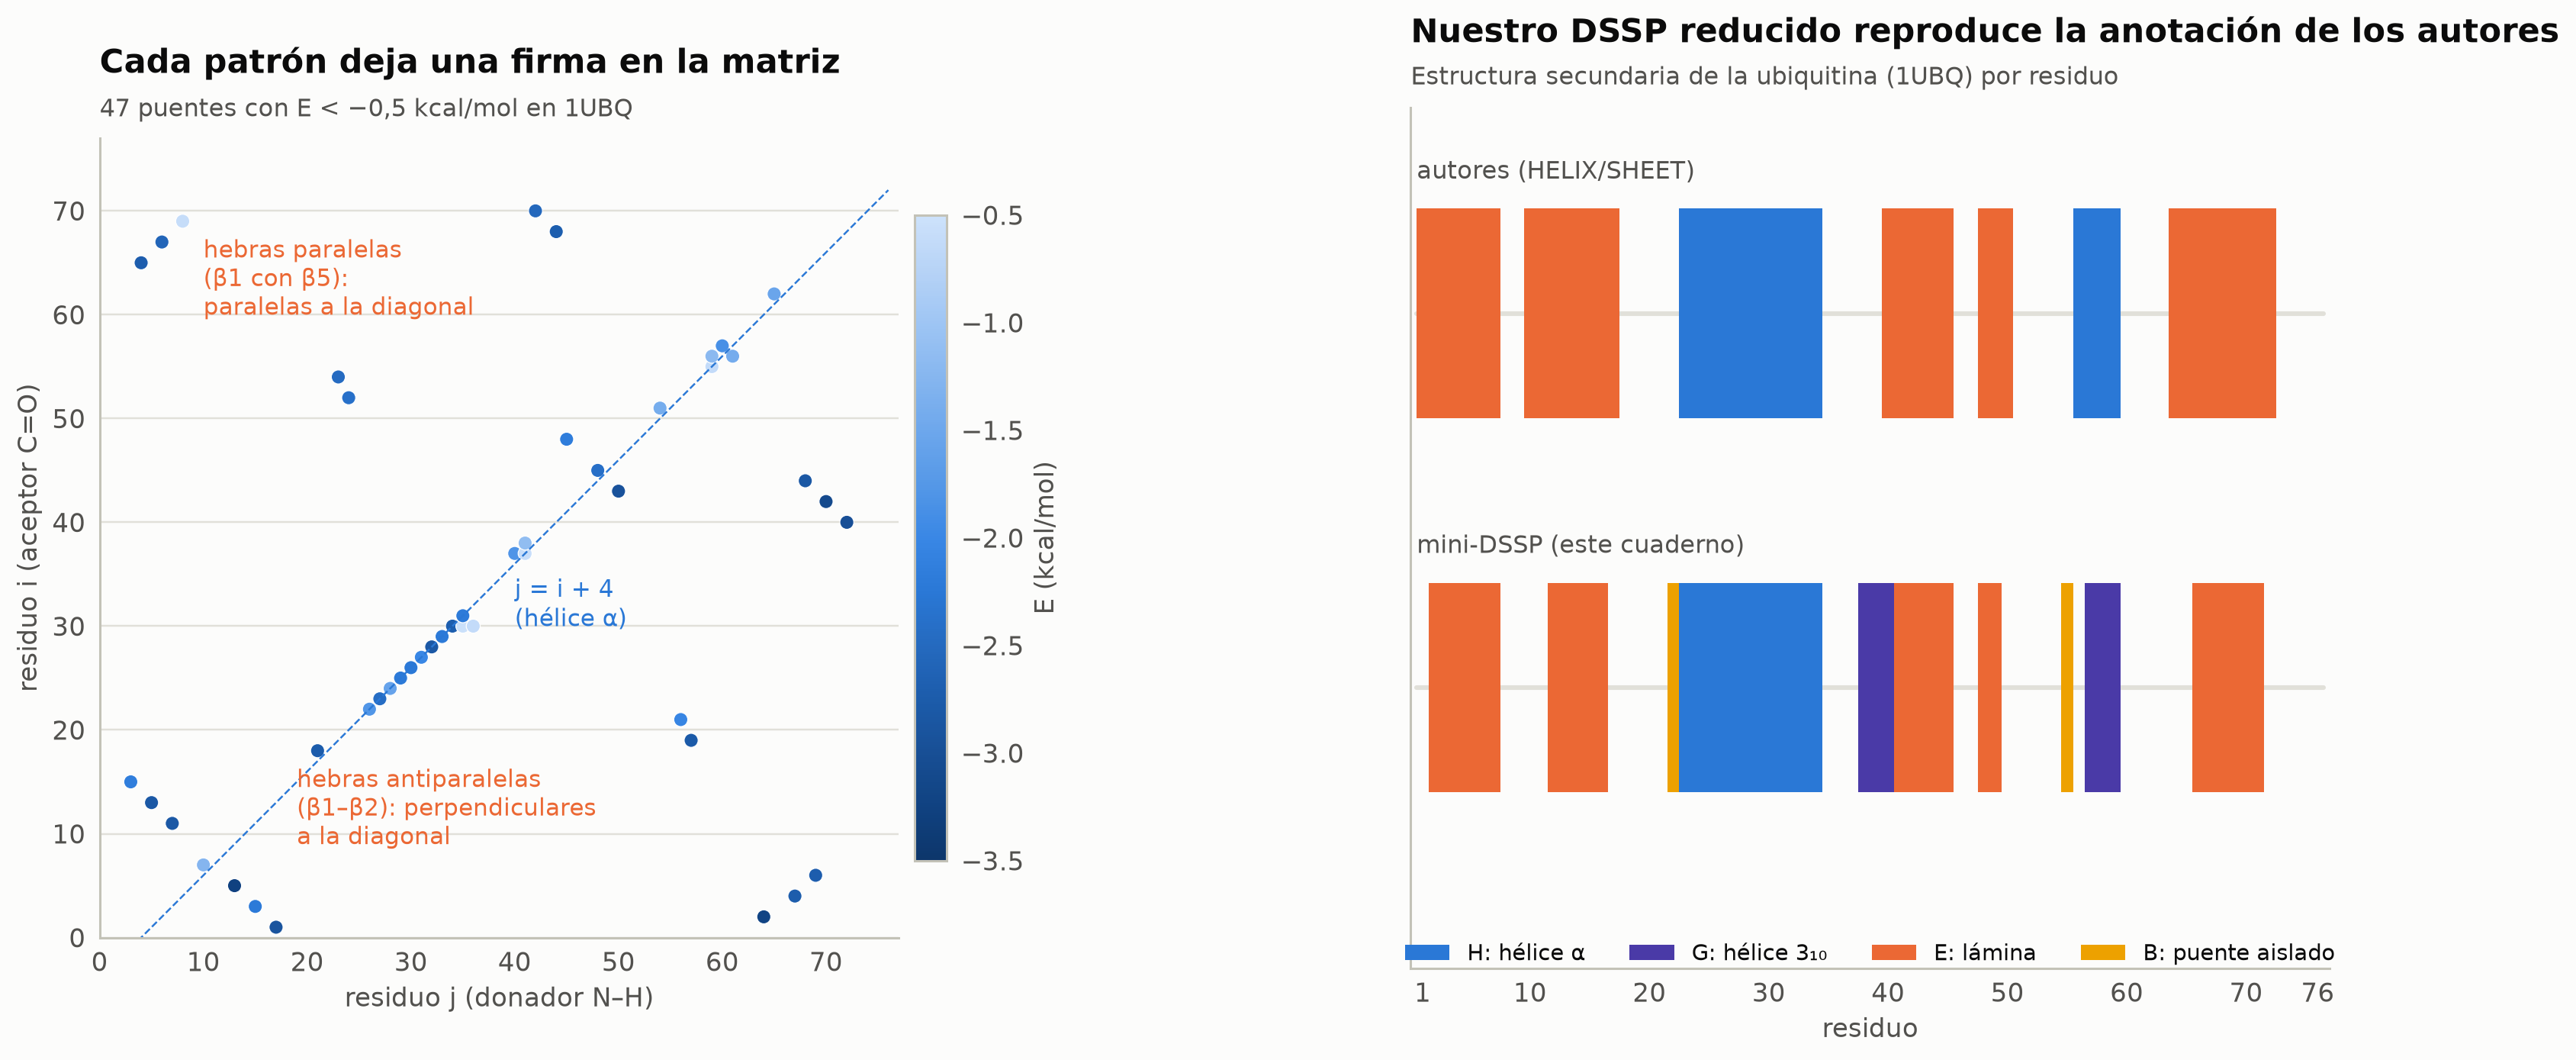

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6.2), gridspec_kw=dict(width_ratios=[1, 1.15], wspace=0.28))
ax = axs[0]
ii, jj = np.where(ubq_hb)
sc = ax.scatter(jj + 1, ii + 1, c=E_ubq[ii, jj], cmap=ec.CMAP_SEQ.reversed(),
                s=36, vmin=-3.5, vmax=-0.5, edgecolor="white", lw=0.4)
ax.plot([1, 76], [1 - 4, 76 - 4], color=ec.BLUE, lw=0.8, ls="--")
ax.text(40, 30, "j = i + 4\n(hélice α)", color=ec.BLUE, fontsize=10)
ax.text(19, 9, "hebras antiparalelas\n(β1–β2): perpendiculares\na la diagonal", color=ec.ORANGE, fontsize=10)
ax.text(10, 60, "hebras paralelas\n(β1 con β5):\nparalelas a la diagonal", color=ec.ORANGE, fontsize=10)
ax.set_xlim(0, 77); ax.set_ylim(0, 77); ax.set_aspect("equal")
ax.set_xlabel("residuo j (donador N–H)"); ax.set_ylabel("residuo i (aceptor C=O)")
cb = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02); cb.set_label("E (kcal/mol)")
ec.title(ax, "Cada patrón deja una firma en la matriz", f"{ubq_hb.sum()} puentes con E < −0,5 kcal/mol en 1UBQ")

ax = axs[1]
tracks = [("autores (HELIX/SHEET)", ubq_ss_header), ("mini-DSSP (este cuaderno)", ubq_ss_dssp)]
colmap = {"H": ec.BLUE, "G": ec.VIOLET, "E": ec.ORANGE, "B": ec.YELLOW}
for row, (lab, trk) in enumerate(tracks):
    y = 1 - row
    ax.plot([0.5, 76.5], [y, y], color=ec.GRID, lw=2, zorder=0)
    for k, s in enumerate(trk):
        if s in colmap:
            ax.add_patch(Rectangle((k + 0.5, y - 0.28), 1, 0.56, color=colmap[s], lw=0))
    ax.text(0.5, y + 0.36, lab, fontsize=10.5, color=ec.INK_2)
for s, lab in [("H", "H: hélice α"), ("G", "G: hélice 3₁₀"), ("E", "E: lámina"), ("B", "B: puente aislado")]:
    ax.bar(0, 0, color=colmap[s], label=lab)
ax.legend(loc="lower center", ncol=4, fontsize=9.5, bbox_to_anchor=(0.5, -0.02), frameon=False)
ax.set_xlim(0, 77); ax.set_ylim(-0.75, 1.55); ax.set_yticks([]); ax.grid(False)
ax.set_xticks([1, 10, 20, 30, 40, 50, 60, 70, 76]); ax.set_xlabel("residuo")
ec.title(ax, "Nuestro DSSP reducido reproduce la anotación de los autores",
         "Estructura secundaria de la ubiquitina (1UBQ) por residuo")
plt.show()

> 🔎 **Qué observamos.** A la izquierda, la hélice 23–34 aparece como una línea de puntos justo sobre la diagonal
> $j=i+4$; las hebras antiparalelas (β1–β2, el horquillado inicial) dibujan segmentos **perpendiculares** a la
> diagonal, y las paralelas (β1 con β5), segmentos **paralelos** a ella. A la derecha, el algoritmo, que sólo sabe
> de cargas y distancias, recupera la hélice, las cinco hebras y la hélice $3_{10}$ (`G` en los residuos 57–59; los autores la sitúan en
> 56–59). Las
> diferencias están en los **bordes** de cada elemento, justo donde los expertos también discrepan: por eso se
> necesitaba una definición algorítmica. Esa asignación es la «verdad» contra la que se evalúan los predictores de
> estructura secundaria; en las 79 estructuras de alta resolución del libro, el 30,9 % de los residuos está en
> hélice, el 25,8 % en lámina y el 43,3 % en giros y lazos.

## 6. Mapas de contactos

La matriz de puentes de hidrógeno es un caso particular de una idea más general: resumir una estructura 3D en una
**matriz 2D** de distancias entre residuos. Si $\mathbf x_i$ es la posición del C$_\alpha$ del residuo $i$, la
matriz de distancias y el **mapa de contactos** son

$$
D_{ij} = \lVert \mathbf x_i - \mathbf x_j \rVert, \qquad
C_{ij} = \begin{cases} 1 & \text{si } D_{ij} < 8\ \text{Å}\\ 0 & \text{en otro caso}\end{cases}
$$

| Símbolo | Significado |
|---|---|
| $\mathbf x_i$ | coordenadas del C$_\alpha$ del residuo $i$ (Å) |
| $D_{ij}$ | distancia entre los C$_\alpha$ de los residuos $i$ y $j$ |
| $C_{ij}$ | 1 si los residuos están «en contacto» (umbral habitual de 8 Å entre C$_\alpha$) |
| $\lvert i-j\rvert$ | separación en la secuencia: corta (< 6), media (6–11) o larga (≥ 12) |

El mapa es **invariante** frente a rotaciones y traslaciones (no depende del sistema de referencia del archivo) y,
salvo por la quiralidad, contiene toda la información de la estructura. Es la representación con la que trabajó la
predicción de estructuras durante una década, desde la coevolución hasta los «distogramas» de AlphaFold (lección
15.2). Los contactos de **largo alcance** ($\lvert i-j\rvert\ge12$) son los que definen el plegamiento.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué dibujo dejará la hélice 23–34 en el mapa? ¿Y las hebras β1 (1–7) y β2
> (10–17), que forman un horquillado antiparalelo?

contactos cortos (3–5)  : 61
contactos medios (6–11) : 24
contactos largos (≥ 12) : 92


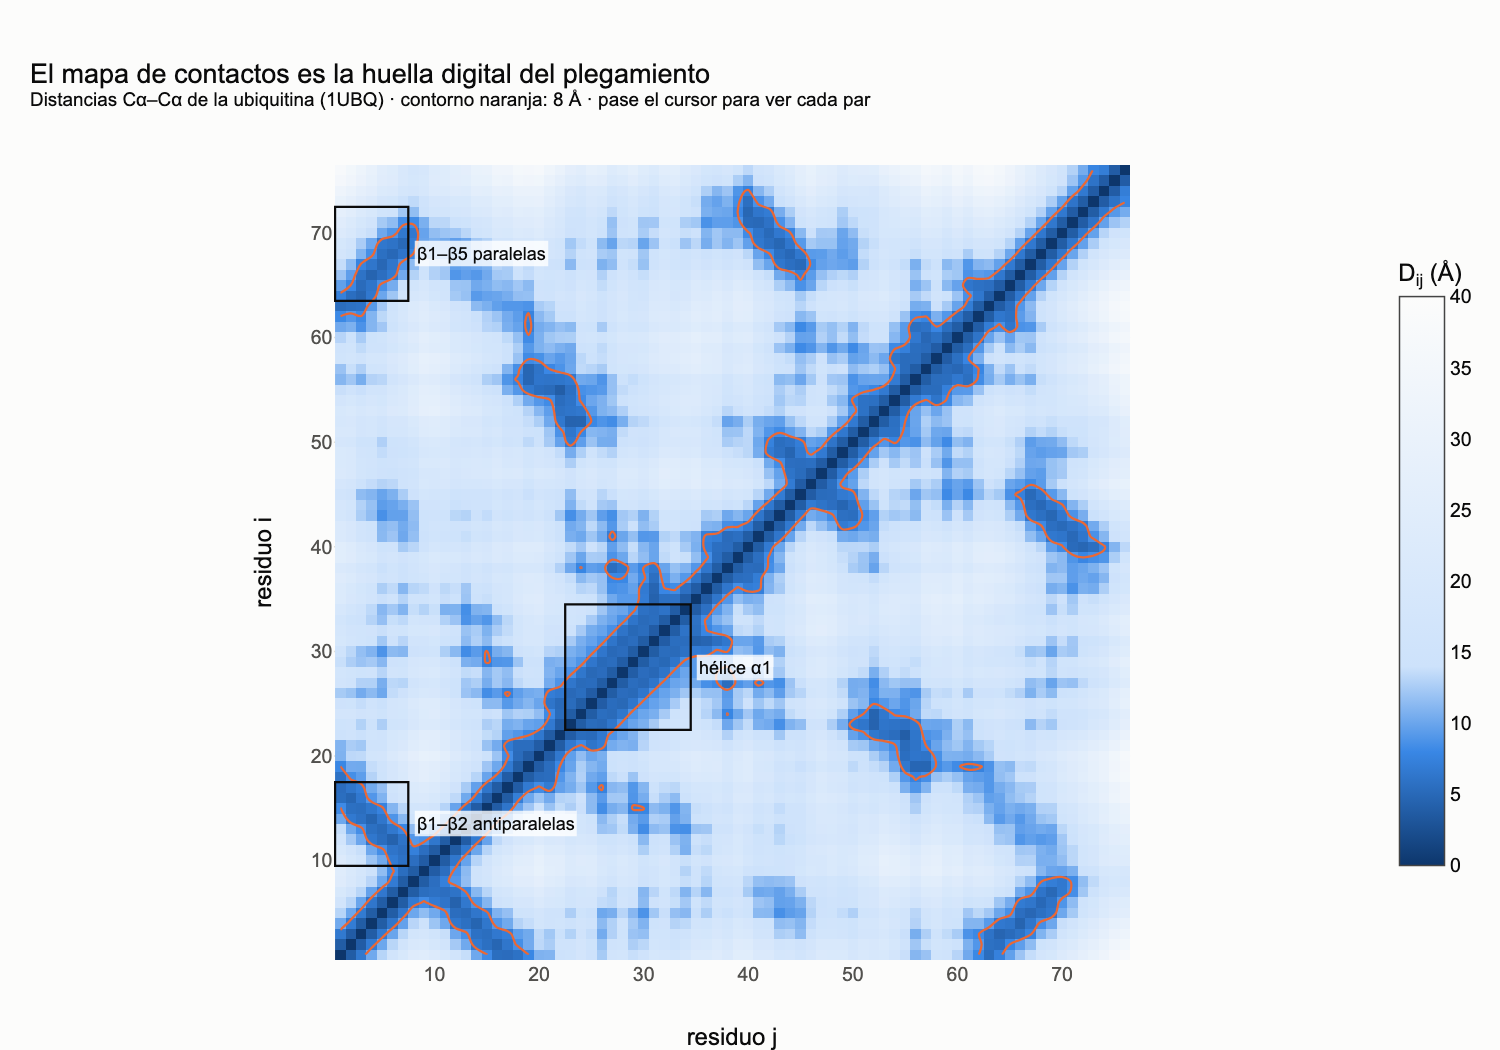

In [13]:
D_ubq = np.linalg.norm(X_ubq[:, None] - X_ubq[None], axis=2)
n = len(X_ubq)
sep = np.abs(np.subtract.outer(np.arange(n), np.arange(n)))
cont = (D_ubq < 8) & (sep >= 3)
for lab, m in [("cortos (3–5)", (sep >= 3) & (sep < 6)), ("medios (6–11)", (sep >= 6) & (sep < 12)),
               ("largos (≥ 12)", sep >= 12)]:
    print(f"contactos {lab:14s}: {np.sum(cont & m) // 2}")

names = [f"{r.get_resname()}{r.id[1]}" for r in ubq_res]
rng_lab = np.where(sep < 6, "corto alcance", np.where(sep < 12, "alcance medio", "largo alcance"))
hover = np.array([[f"<b>{names[i]} ↔ {names[j]}</b><br>D = {D_ubq[i, j]:.1f} Å · |i−j| = {sep[i, j]}<br>"
                   f"{'CONTACTO (< 8 Å) · ' + rng_lab[i, j] if D_ubq[i, j] < 8 and sep[i, j] >= 3 else 'sin contacto'}"
                   f"<br>SS: {ubq_ss_dssp[i]} / {ubq_ss_dssp[j]}"
                   for j in range(n)] for i in range(n)])
fig = go.Figure(go.Heatmap(
    z=D_ubq, x=np.arange(1, n + 1), y=np.arange(1, n + 1), text=hover, hoverinfo="text",
    colorscale=[[0, "#0d366b"], [0.2, "#3987e5"], [0.35, "#cde2fb"], [1, "#fcfcfb"]], zmin=0, zmax=40,
    colorbar=dict(title="D<sub>ij</sub> (Å)", len=0.8)))
fig.add_trace(go.Contour(z=D_ubq, x=np.arange(1, n + 1), y=np.arange(1, n + 1), showscale=False,
                         contours=dict(start=8, end=8, size=1, coloring="none"),
                         line=dict(color=ec.ORANGE, width=1.5), hoverinfo="skip", name="umbral 8 Å"))
for x0, x1, y0, y1, t in [(23, 34, 23, 34, "hélice α1"), (1, 7, 10, 17, "β1–β2 antiparalelas"),
                          (1, 7, 64, 72, "β1–β5 paralelas")]:
    fig.add_shape(type="rect", x0=x0 - 0.5, x1=x1 + 0.5, y0=y0 - 0.5, y1=y1 + 0.5, line=dict(color=ec.INK, width=1.5))
    fig.add_annotation(x=x1 + 1, y=(y0 + y1) / 2, text=t, showarrow=False, xanchor="left",
                       font=dict(size=12, color=ec.INK), bgcolor="rgba(255,255,255,0.8)")
fig.update_layout(
    title="El mapa de contactos es la huella digital del plegamiento"
          "<br><sup>Distancias Cα–Cα de la ubiquitina (1UBQ) · contorno naranja: 8 Å · pase el cursor para ver cada par</sup>",
    xaxis=dict(title="residuo j", constrain="domain", dtick=10), yaxis=dict(title="residuo i", scaleanchor="x", dtick=10),
    height=700, width=800, margin=dict(t=110, l=70, r=30, b=60))
fig.show()

> 🔎 **Qué observamos.** La **hélice** es una banda ancha pegada a la diagonal (cada residuo toca a $i\pm3$ e
> $i\pm4$, a 5–6 Å); una **horquilla antiparalela** (β1–β2) es una franja **perpendicular** a la diagonal, cerca de
> ella; y el par **paralelo** β1–β5, lejos en la secuencia, es una franja **paralela** a la diagonal en una esquina
> del mapa: un contacto de largo alcance que sólo el plegamiento completo puede explicar. Adivinar esas manchas a
> partir de la secuencia fue, durante una década, el problema central de la predicción de estructuras.

> ✅ **Compruebe su comprensión.** Si reflejáramos la proteína en un espejo (todas las $x$ cambiadas de signo),
> ¿cambiaría el mapa de contactos? ¿Y los ángulos $\phi,\psi$? *(El mapa no cambia; los diedros cambian de signo:
> la hélice derecha se volvería izquierda. Por eso la quiralidad no se lee en $D_{ij}$.)*

## 7. Cómo se determina una estructura

Ninguna técnica «fotografía» una proteína: todas miden una **señal indirecta** y construyen un **modelo atómico**
compatible con ella. Conocer la señal es indispensable para saber cuánto confiar en cada parte del modelo.

### 7.1 Cristalografía de rayos X

Una proteína purificada se cristaliza, de modo que billones de copias quedan ordenadas en una red periódica. Al
iluminar el cristal con rayos X, los electrones dispersan la radiación y las ondas interfieren constructivamente
sólo en direcciones discretas, las que cumplen la **ley de Bragg** (ecuación 15-bragg del libro):

$$
2\,d\,\sin\theta = \lambda .
$$

Cada reflexión $\mathbf h=(h,k,l)$ tiene un **factor de estructura** $F_{\mathbf h}=|F_{\mathbf h}|e^{i\varphi_{\mathbf h}}$, y
la densidad electrónica en el punto $\mathbf x$ de la celda es su transformada de Fourier inversa (ecuación
15-fourier):

$$
\rho(\mathbf x) = \frac{1}{V}\sum_{\mathbf h} |F_{\mathbf h}|\,e^{i\varphi_{\mathbf h}}\,e^{-2\pi i\,\mathbf h\cdot\mathbf x}.
$$

| Símbolo | Significado |
|---|---|
| $d$ | espaciado de una familia de planos del cristal (Å) |
| $\theta$ | ángulo de incidencia |
| $\lambda$ | longitud de onda de los rayos X (≈ 1 Å) |
| $\rho(\mathbf x)$ | densidad electrónica (electrones/Å$^3$) en la posición fraccionaria $\mathbf x$ de la celda |
| $V$ | volumen de la celda unidad |
| $\lvert F_{\mathbf h}\rvert$ | amplitud de la reflexión $\mathbf h$; se obtiene de la intensidad medida, $I_{\mathbf h}\propto\lvert F_{\mathbf h}\rvert^2$ |
| $\varphi_{\mathbf h}$ | fase de la reflexión; **no se mide** (el «problema de la fase») |

Dos conceptos salen directamente de esta fórmula, y los podemos ver en una dimensión:

* **Resolución.** Es el menor espaciado $d$ para el que se midieron reflexiones útiles. Una suma de Fourier truncada
  en $|h|\le h_{\max}$ sólo puede dibujar detalles de tamaño $d=a/h_{\max}$ ($a$ = longitud de la celda). A 3,5 Å se
  distingue el trazado de la cadena y las hélices; a 2 Å, la forma de las cadenas laterales; por debajo de 1,2 Å,
  átomos individuales e incluso algunos hidrógenos.
* **El problema de la fase.** El detector registra intensidades $|F|^2$, no fases. Sin fases la suma no puede
  evaluarse. Se resuelve con átomos pesados, con dispersión anómala o, cada vez más, por **reemplazo molecular**
  a partir de un modelo parecido (incluso uno predicho por AlphaFold).

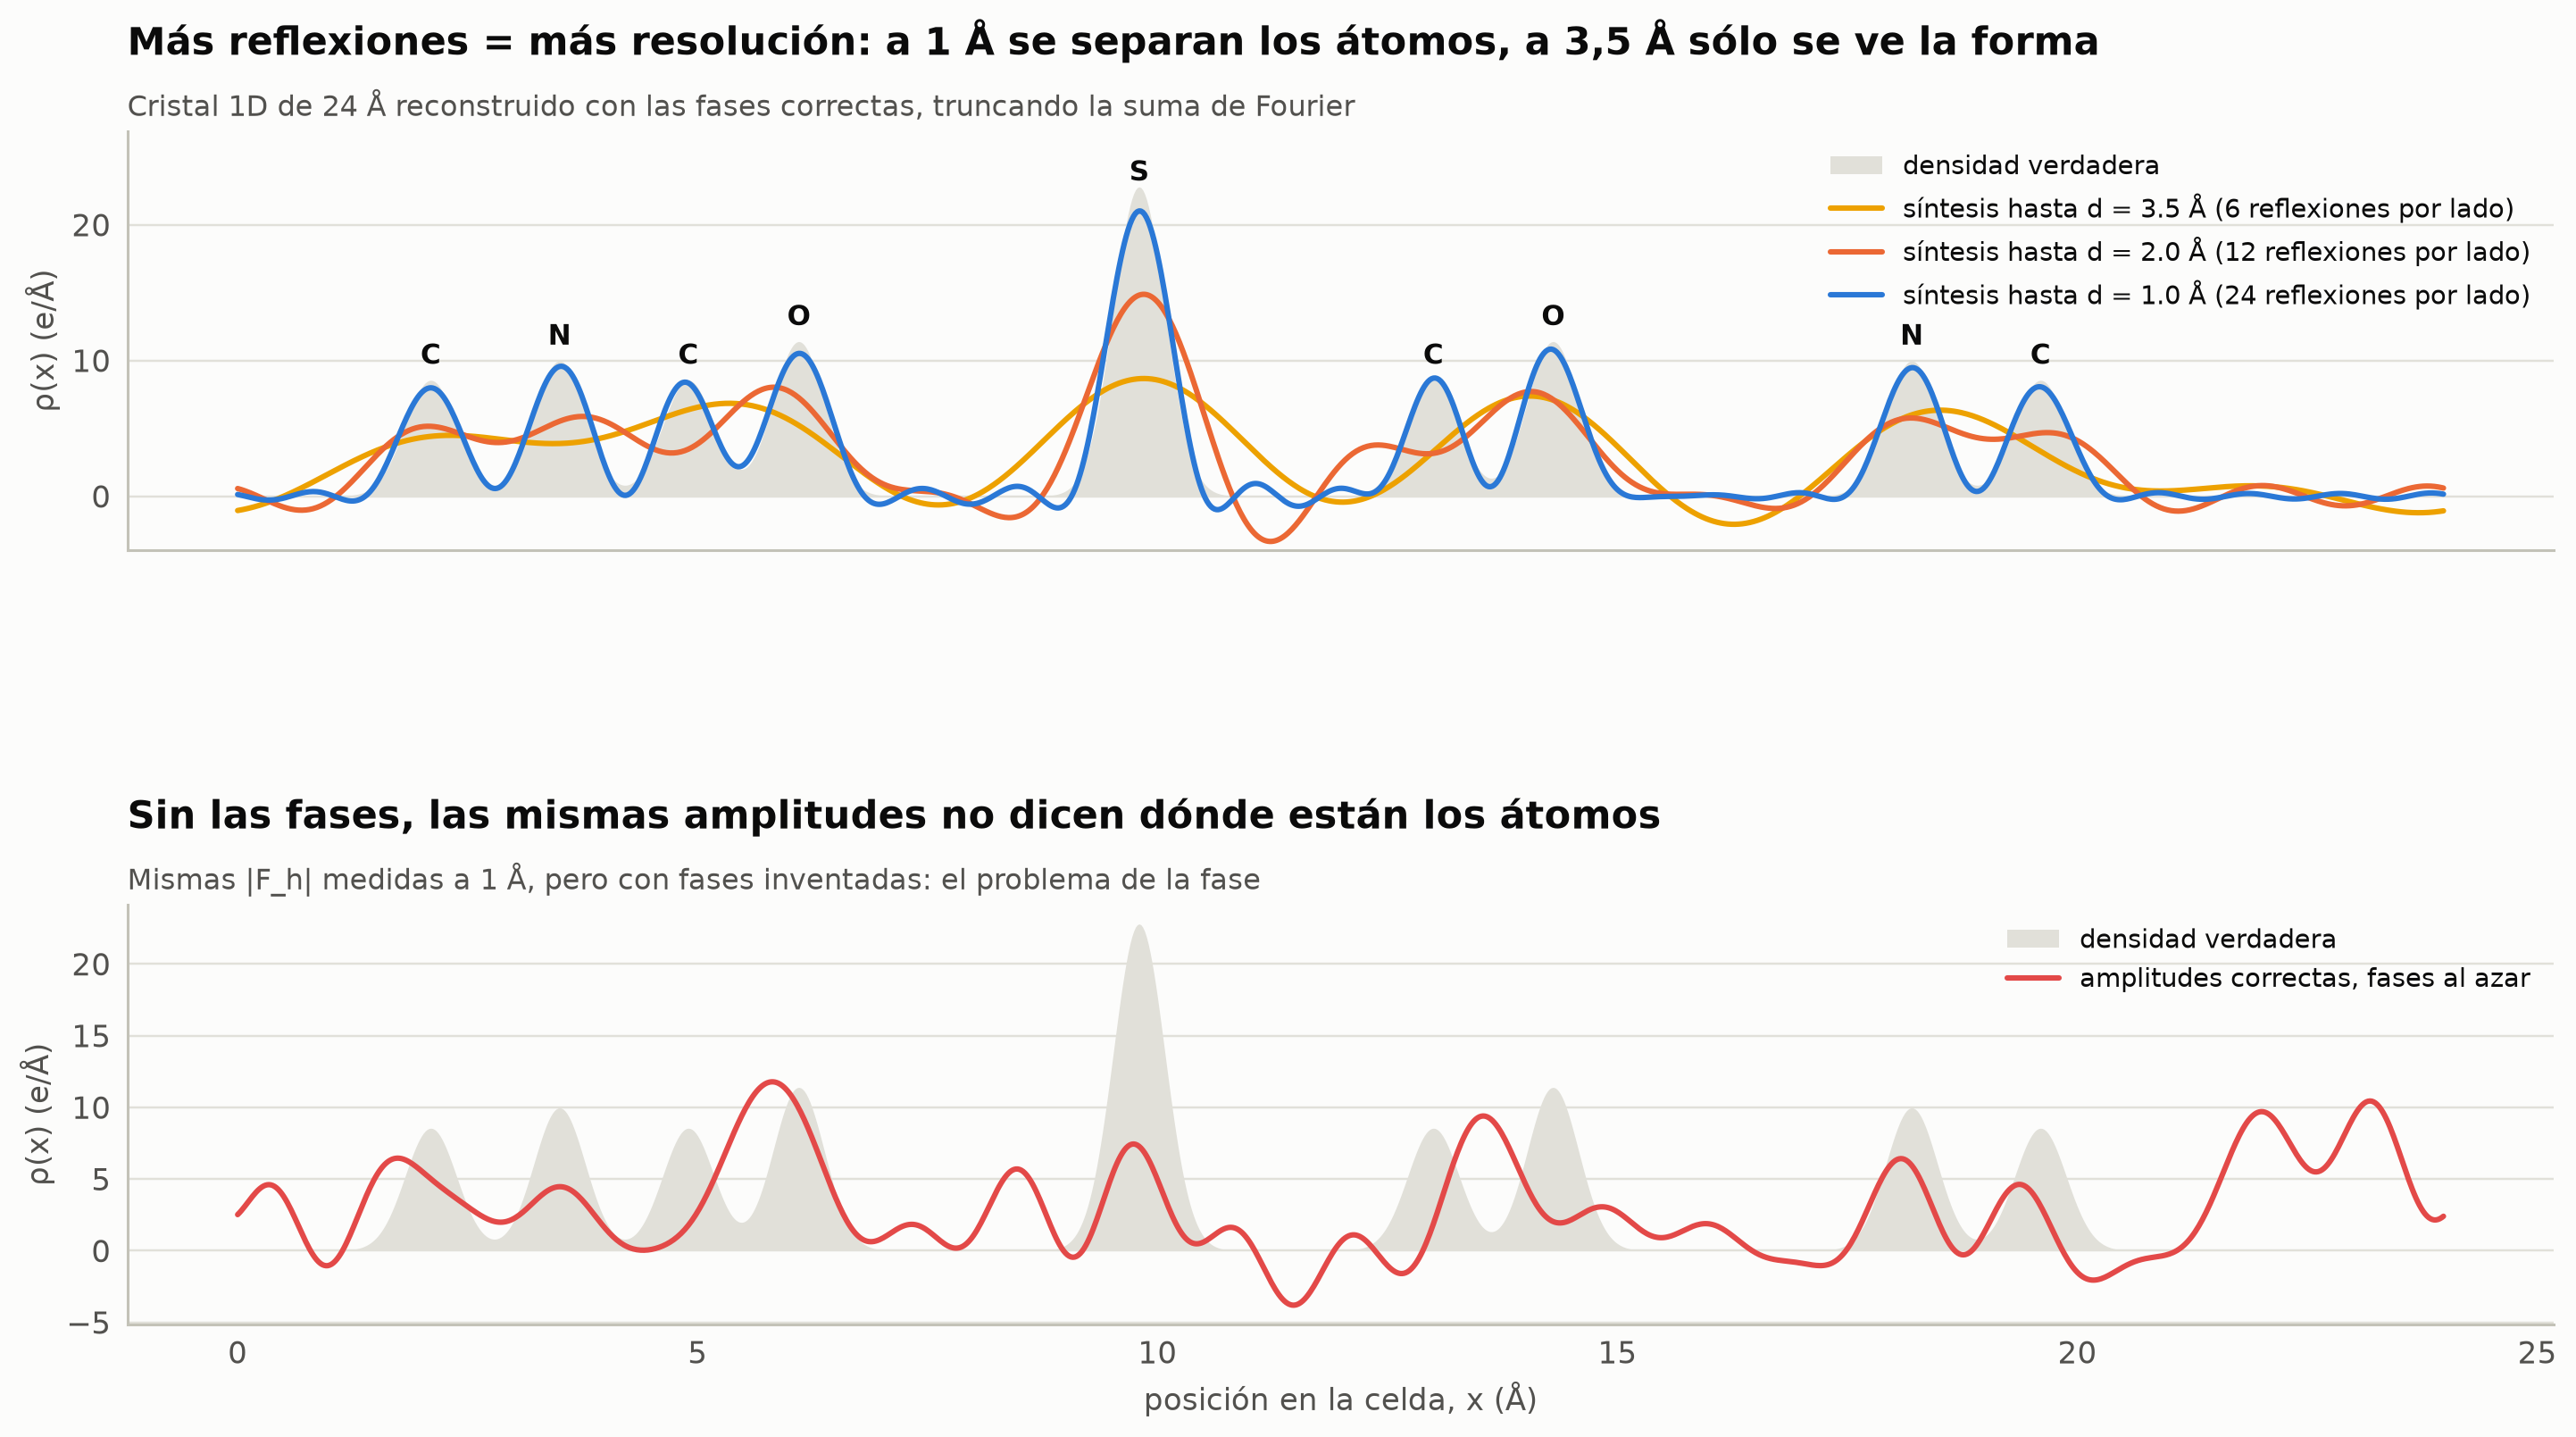

In [14]:
# Un «cristal» unidimensional: celda de a = 24 Å con 7 átomos (C, N, O, S) de anchura térmica realista
a_cell = 24.0
atoms_1d = [(2.1, 6, "C"), (3.5, 7, "N"), (4.9, 6, "C"), (6.1, 8, "O"), (9.8, 16, "S"), (13.0, 6, "C"),
            (14.3, 8, "O"), (18.2, 7, "N"), (19.6, 6, "C")]
x = np.linspace(0, a_cell, 1200, endpoint=False)
def density(x, atoms, width=0.28):
    rho = np.zeros_like(x)
    for pos, z, _ in atoms:
        dx = (x - pos + a_cell / 2) % a_cell - a_cell / 2          # periódico
        rho += z * np.exp(-dx ** 2 / (2 * width ** 2)) / (width * np.sqrt(2 * np.pi))
    return rho

rho_true = density(x, atoms_1d)
F = np.fft.fft(rho_true)                        # factores de estructura F_h (amplitud y fase)
h = np.fft.fftfreq(len(x), d=1 / len(x))        # índice de Miller h = 0, ±1, ±2, …

def reconstruct(F, d_min, phases=None):
    """Síntesis de Fourier con |h| ≤ a/d_min, con las fases verdaderas o con otras."""
    keep = np.abs(h) <= a_cell / d_min
    Fk = np.where(keep, np.abs(F) * np.exp(1j * (np.angle(F) if phases is None else phases)), 0)
    return np.fft.ifft(Fk).real

rng = np.random.default_rng(151)
rand_ph = rng.uniform(-np.pi, np.pi, len(F))     # fases inventadas (nos quedamos con la parte real)
fig, axs = plt.subplots(2, 1, figsize=(13, 7.2), sharex=True, gridspec_kw=dict(hspace=0.35))
ax = axs[0]
ax.fill_between(x, rho_true, color=ec.GRID, label="densidad verdadera")
for d_min, col in [(3.5, ec.YELLOW), (2.0, ec.ORANGE), (1.0, ec.BLUE)]:
    ax.plot(x, reconstruct(F, d_min), color=col, lw=2, label=f"síntesis hasta d = {d_min} Å ({int(a_cell / d_min)} reflexiones por lado)")
for pos, z, el in atoms_1d:
    ax.text(pos, rho_true.max() * 1.02 if el == "S" else density(np.array([pos]), atoms_1d)[0] + 1.2, el,
            ha="center", fontsize=10, fontweight="bold", color=ec.INK)
ax.set_ylabel("ρ(x) (e/Å)"); ax.set_ylim(-4, rho_true.max() * 1.18)
ax.legend(loc="upper right", fontsize=9.5, ncol=1, framealpha=0.95)
ec.title(ax, "Más reflexiones = más resolución: a 1 Å se separan los átomos, a 3,5 Å sólo se ve la forma",
         "Cristal 1D de 24 Å reconstruido con las fases correctas, truncando la suma de Fourier")
ax = axs[1]
ax.fill_between(x, rho_true, color=ec.GRID, label="densidad verdadera")
ax.plot(x, reconstruct(F, 1.0, rand_ph), color=ec.RED, lw=2, label="amplitudes correctas, fases al azar")
ax.set_xlabel("posición en la celda, x (Å)"); ax.set_ylabel("ρ(x) (e/Å)")
ax.legend(loc="upper right", fontsize=9.5, framealpha=0.95)
ec.title(ax, "Sin las fases, las mismas amplitudes no dicen dónde están los átomos",
         "Mismas |F_h| medidas a 1 Å, pero con fases inventadas: el problema de la fase")
plt.show()

> 🔎 **Qué observamos.** Con las fases correctas, truncar la suma a 3,5 Å produce una «mancha» continua (la forma del
> fragmento, pero ningún átomo); a 2 Å aparecen jorobas para los grupos de átomos; a 1 Å cada átomo, incluso el N y el
> C separados por 1,4 Å, tiene su propio pico. Con las mismas amplitudes y fases al azar, en cambio, la densidad es
> ruido: **las fases llevan la mayor parte de la información sobre dónde están los átomos**. Ésa es la razón de que
> el reemplazo molecular con modelos predichos haya cambiado tanto la cristalografía reciente.

La calidad del ajuste del modelo a los datos se mide con el **factor $R$**, la discrepancia relativa entre las
amplitudes observadas y las calculadas con el modelo, y, para evitar el sobreajuste, con el **$R_{\text{free}}$**,
calculado sobre un 5 % de reflexiones que se excluyen del refinamiento: una forma temprana de **validación cruzada**,
la misma idea que se usa en aprendizaje automático.

### 7.2 Resonancia magnética nuclear (RMN)

La proteína se estudia **en disolución**. Los espectros multidimensionales revelan qué núcleos (normalmente $^1$H,
con marcaje de $^{15}$N y $^{13}$C) están a menos de unos 5 Å entre sí (efecto Overhauser nuclear, NOE) y qué valores
toman ciertos diedros. El resultado no es una estructura sino un conjunto de **restricciones** de distancia y ángulo,
y el modelo se entrega como un **ensamble** de 10 a 40 conformaciones que las satisfacen. La RMN está limitada a
proteínas de tamaño modesto (en la práctica, hasta unos 30–40 kDa), pero observa la **dinámica** en disolución, algo
que el cristal oculta.

### 7.3 Criomicroscopía electrónica (crio-EM)

Millones de copias de un complejo se congelan en una capa fina de hielo vítreo y se fotografían con un haz de
electrones. Cada imagen es una proyección 2D ruidosa desde una orientación desconocida; el procesamiento las
clasifica, estima sus orientaciones y reconstruye un mapa 3D. La resolución se estima comparando dos
reconstrucciones independientes con la curva de correlación de capas de Fourier (FSC), y se informa donde esta cae por
debajo de 0,143. Con los detectores directos de electrones y nuevos algoritmos, la técnica pasó en pocos años de
producir «manchas» a mapas con detalle atómico: la «revolución de la resolución» (Kühlbrandt, 2014). No necesita
cristales y brilla con complejos grandes, flexibles o de membrana.

| | **Rayos X** | **RMN** | **Crio-EM** |
|---|---|---|---|
| Muestra | cristal | disolución | partículas en hielo vítreo |
| Señal | difracción (amplitudes) | acoplamientos y NOE entre núcleos | proyecciones 2D |
| Tamaño idóneo | cualquiera que cristalice | ≲ 40 kDa | ≳ 50 kDa |
| Medida de calidad | resolución, $R_{\text{free}}$, factor $B$ | restricciones por residuo, dispersión del ensamble | resolución FSC, resolución local |
| Dinámica | indirecta (factor $B$) | directa (ensamble, relajación) | heterogeneidad por clasificación |
| Entradas en 2025 | 10 083 (57,6 %) | 225 (1,3 %) | 7 198 (41,1 %) |

La última fila no la copiamos: la preguntamos a la **API de búsqueda del RCSB** con la misma consulta que usó el libro
(con copia en caché para que el cuaderno funcione sin red).

In [15]:
def rcsb_count(method, year, tag):
    """Número de entradas liberadas en un año con un método (API de búsqueda del RCSB; caché del curso primero)."""
    name = f"api_cache/rcsb_count_{year}_{tag}.json"
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return json.load(open(local))["total_count"]
    q = {"query": {"type": "group", "logical_operator": "and", "nodes": [
        {"type": "terminal", "service": "text", "parameters": {
            "attribute": "exptl.method", "operator": "exact_match", "value": method}},
        {"type": "terminal", "service": "text", "parameters": {
            "attribute": "rcsb_accession_info.initial_release_date", "operator": "range",
            "value": {"from": f"{year}-01-01", "to": f"{year}-12-31", "include_lower": True, "include_upper": True}}}]},
        "return_type": "entry", "request_options": {"return_counts": True, "results_content_type": ["experimental"]}}
    try:
        req = urllib.request.Request("https://search.rcsb.org/rcsbsearch/v2/query", data=json.dumps(q).encode(),
                                     headers={"Content-Type": "application/json"})
        return json.loads(urllib.request.urlopen(req, timeout=60).read())["total_count"]
    except Exception as err:
        print(f"⚠️ RCSB no respondió ({err}); uso la copia del curso")
        return json.loads(course_bytes(name))["total_count"]

counts = {lab: rcsb_count(m, 2025, tag) for lab, m, tag in
          [("rayos X", "X-RAY DIFFRACTION", "xray"), ("RMN", "SOLUTION NMR", "nmr"), ("crio-EM", "ELECTRON MICROSCOPY", "em")]}
tot = sum(counts.values())
for k_, v in counts.items():
    print(f"2025 · {k_:8s}: {v:6,d} entradas ({v / tot:.1%})")

2025 · rayos X : 10,083 entradas (57.6%)
2025 · RMN     :    225 entradas (1.3%)
2025 · crio-EM :  7,198 entradas (41.1%)


Entradas liberadas 1976–2025: 246,212
       xray  nmr    em  frac_em
anio                           
2000   2231  370    11    0.004
2010   7163  509    53    0.007
2015   8589  419   213    0.023
2020  11204  368  2361    0.169
2025  10083  225  7198    0.411


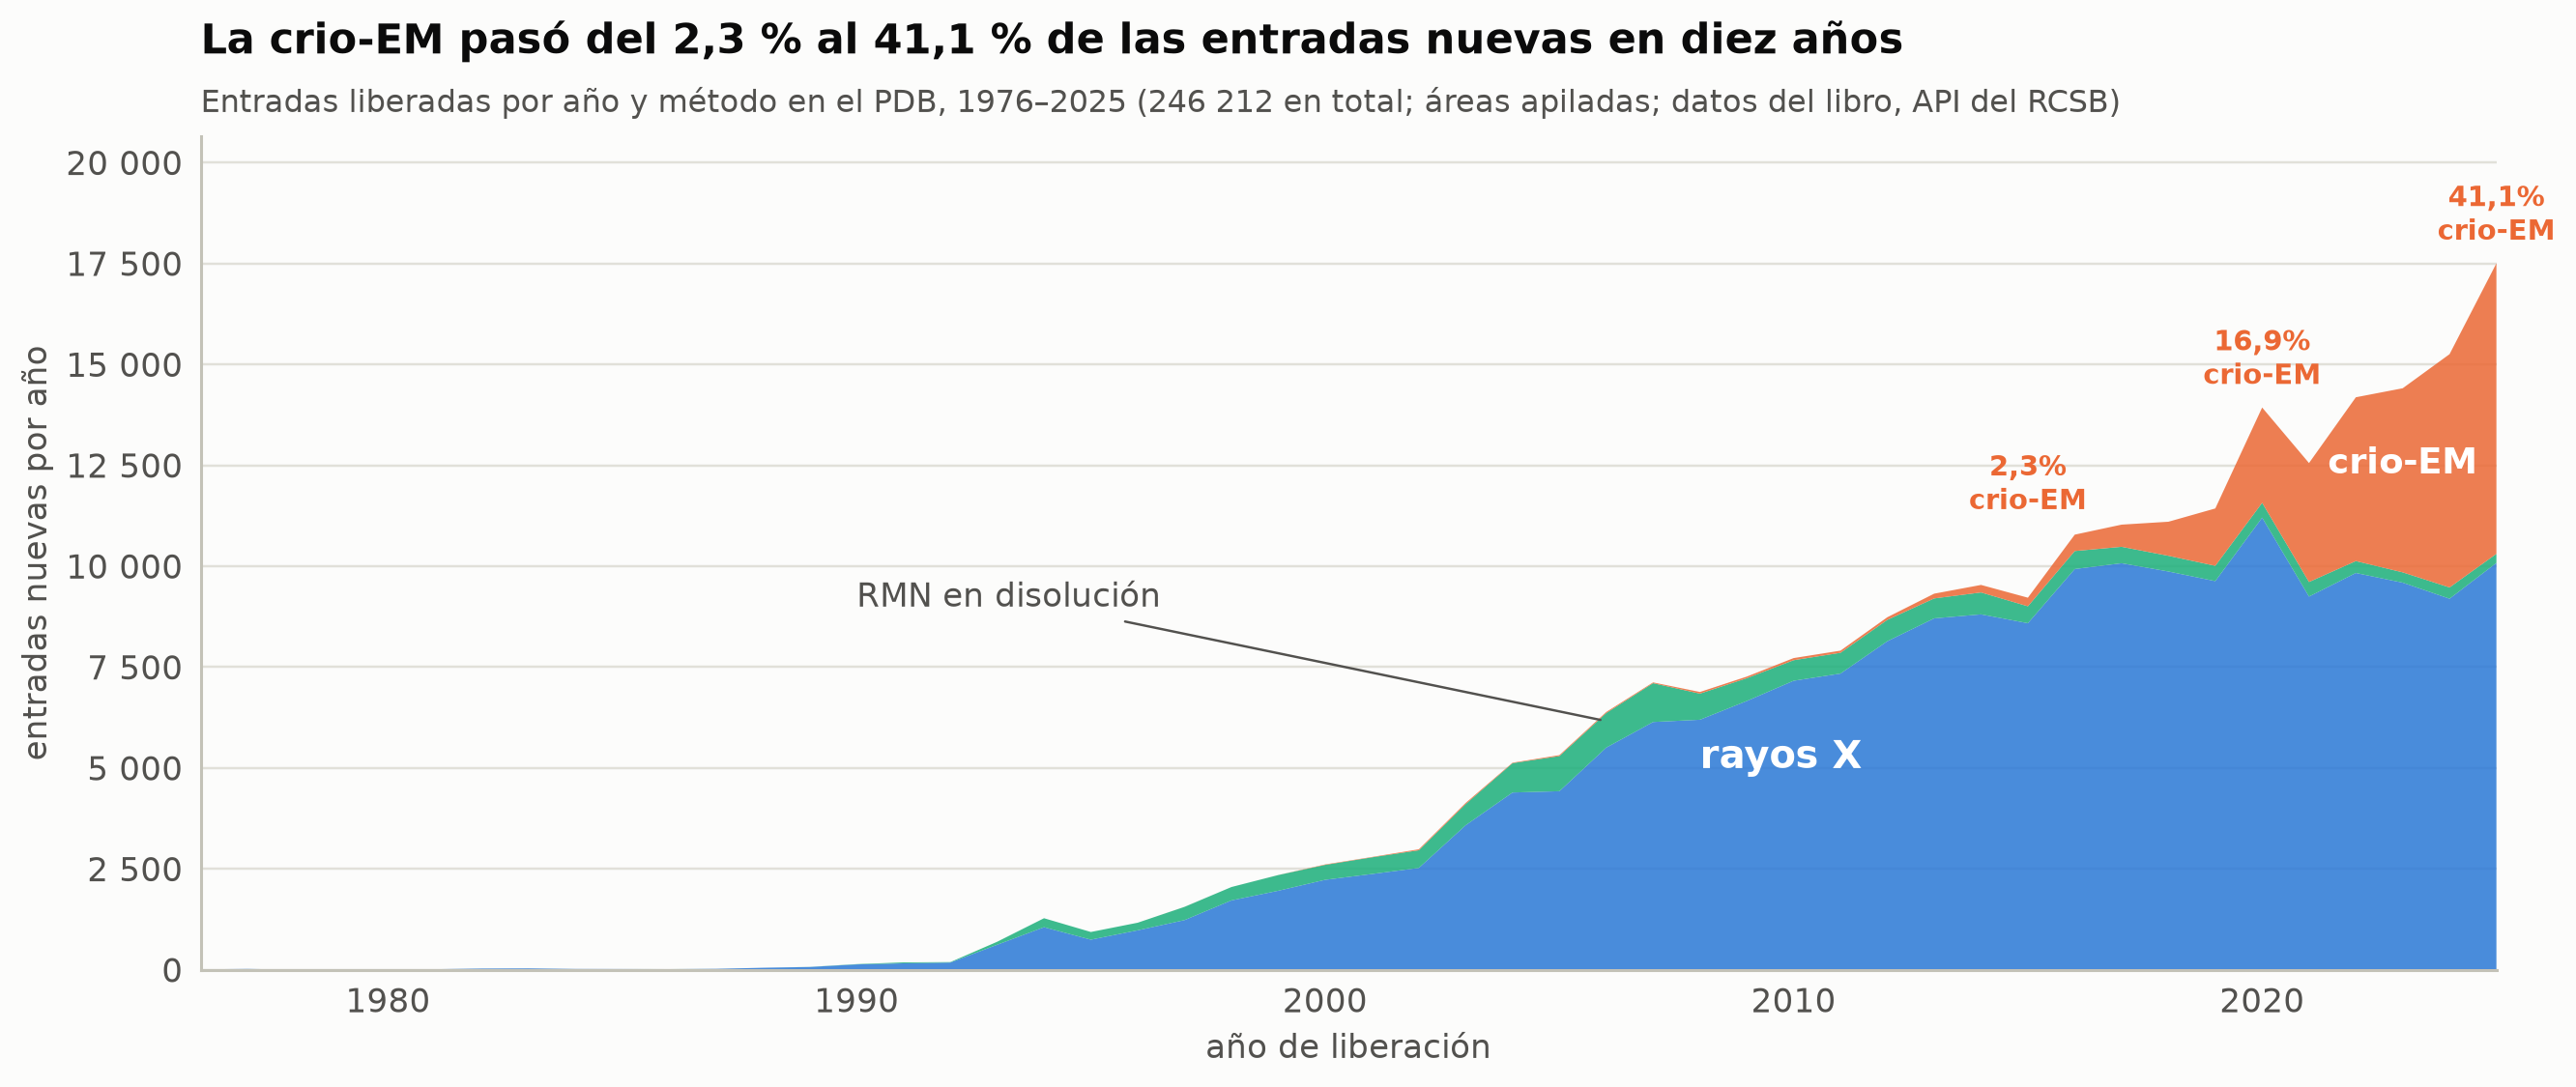

In [16]:
anual = pd.read_csv(io.BytesIO(course_bytes("151_pdb_anual.tsv")), sep=r"\s+")
anual["total"] = anual[["xray", "nmr", "em"]].sum(1)
anual["frac_em"] = anual["em"] / anual["total"]
print(f"Entradas liberadas 1976–2025: {anual['total'].sum():,}")
print(anual.set_index("anio").loc[[2000, 2010, 2015, 2020, 2025], ["xray", "nmr", "em", "frac_em"]].round(3))

fig, ax = plt.subplots(figsize=(12, 5))
ax.stackplot(anual["anio"], anual["xray"], anual["nmr"], anual["em"], colors=[ec.BLUE, ec.AQUA, ec.ORANGE], alpha=0.85)
ax.set_xlim(1976, 2025); ax.set_ylabel("entradas nuevas por año"); ax.set_xlabel("año de liberación")
ax.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}".replace(",", " ")))
ax.text(2008, 5000, "rayos X", color="white", fontsize=13, fontweight="bold")
ax.annotate("RMN en disolución", (2006, anual.set_index("anio").loc[2006, ["xray", "nmr"]].sum() - 200),
            xytext=(1990, 9000), fontsize=11, color=ec.INK_2, arrowprops=dict(arrowstyle="-", color=ec.INK_2, lw=0.8))
ax.text(2023, 12300, "crio-EM", color="white", fontsize=12, fontweight="bold", ha="center")
for y_ in (2015, 2020, 2025):
    fe = anual.set_index("anio").loc[y_, "frac_em"]
    tt = anual.set_index("anio").loc[y_, "total"]
    ax.annotate(f"{fe:.1%}".replace(".", ",") + "\ncrio-EM", (y_, tt), xytext=(0, 30 if y_ == 2015 else 8),
                textcoords="offset points", ha="center",
                fontsize=9.5, color=ec.ORANGE, fontweight="bold")
ax.set_ylim(0, anual["total"].max() * 1.18)
ec.title(ax, "La crio-EM pasó del 2,3 % al 41,1 % de las entradas nuevas en diez años",
         "Entradas liberadas por año y método en el PDB, 1976–2025 (" + f"{anual['total'].sum():,}".replace(",", " ")
         + " en total; áreas apiladas; datos del libro, API del RCSB)")
plt.show()

> 🔎 **Qué observamos.** La cristalografía domina durante cuatro décadas; la RMN alcanza su máximo hacia 2007 (962 entradas) y
> declina; desde 2014 la crio-EM crece de forma explosiva (2,3 % de las entradas en 2015, 16,9 % en 2020, 41,1 % en
> 2025) mientras el número de estructuras cristalográficas se estanca. En total se liberaron 246 212 entradas en el
> periodo. Si usted trabaja con complejos grandes (ribosomas, canales, transportadores de membrana), lo más probable
> es que su estructura de partida sea hoy de crio-EM.

## 8. El Protein Data Bank y el formato mmCIF

Desde 1971, las estructuras de macromoléculas se depositan en un único archivo público, el **Protein Data Bank**
(PDB), a cargo del consorcio RCSB desde 1998–99 (descrito por Berman *et al.*, 2000) y hoy gestionado por el
consorcio internacional wwPDB. El portal RCSB.org ofrece además cerca de un millón de modelos calculados por inteligencia artificial,
claramente separados de los experimentales. Cada entrada tiene un identificador de cuatro caracteres (`1UBQ`) y
contiene mucho más que coordenadas: secuencias, ligandos, condiciones experimentales, resolución, estadísticas de
refinamiento, referencias y un informe de validación.

El formato histórico, de columnas fijas y 80 caracteres por línea, lo vimos en la lección 2.2. Sus límites (cinco
dígitos para el número de átomo, un solo carácter para la cadena) lo hicieron insuficiente para los grandes complejos
de crio-EM, y desde 2014 el formato oficial es **PDBx/mmCIF**: una colección de **tablas con nombre**, cada una
precedida de `loop_` y de la lista de sus columnas. Veamos el archivo real de la ubiquitina.

In [17]:
cif_text = pdb_text("1UBQ", "cif")
lines = cif_text.splitlines()
start = next(k for k, l in enumerate(lines) if l.startswith("_atom_site.group_PDB")) - 1
print("\n".join(lines[start:start + 25]))

loop_
_atom_site.group_PDB 
_atom_site.id 
_atom_site.type_symbol 
_atom_site.label_atom_id 
_atom_site.label_alt_id 
_atom_site.label_comp_id 
_atom_site.label_asym_id 
_atom_site.label_entity_id 
_atom_site.label_seq_id 
_atom_site.pdbx_PDB_ins_code 
_atom_site.Cartn_x 
_atom_site.Cartn_y 
_atom_site.Cartn_z 
_atom_site.occupancy 
_atom_site.B_iso_or_equiv 
_atom_site.pdbx_formal_charge 
_atom_site.auth_seq_id 
_atom_site.auth_comp_id 
_atom_site.auth_asym_id 
_atom_site.auth_atom_id 
_atom_site.pdbx_PDB_model_num 
ATOM   1   N N   . MET A 1 1  ? 27.340 24.430 2.614  1.00 9.67  ? 1   MET A N   1 
ATOM   2   C CA  . MET A 1 1  ? 26.266 25.413 2.842  1.00 10.38 ? 1   MET A CA  1 
ATOM   3   C C   . MET A 1 1  ? 26.913 26.639 3.531  1.00 9.62  ? 1   MET A C   1 


In [18]:
cif = MMCIF2Dict(io.StringIO(cif_text))
meta = {"método": cif["_exptl.method"][0], "resolución (Å)": cif["_refine.ls_d_res_high"][0],
        "R (obs)": cif["_refine.ls_R_factor_obs"][0], "R_free": cif["_refine.ls_R_factor_R_free"][0],
        "título": cif["_struct.title"][0]}
for k_, v in meta.items():
    print(f"{k_:15s}: {v}")

cols = ["group_PDB", "id", "type_symbol", "label_atom_id", "label_comp_id", "label_asym_id", "label_seq_id",
        "Cartn_x", "Cartn_y", "Cartn_z", "occupancy", "B_iso_or_equiv"]
atom_site = pd.DataFrame({c: cif[f"_atom_site.{c}"] for c in cols})
for c in ["Cartn_x", "Cartn_y", "Cartn_z", "occupancy", "B_iso_or_equiv"]:
    atom_site[c] = atom_site[c].astype(float)
print(f"\nTabla _atom_site: {len(atom_site)} filas; {atom_site['group_PDB'].value_counts().to_dict()}")
atom_site.head(6)

método         : X-RAY DIFFRACTION
resolución (Å) : 1.8
R (obs)        : 0.1760000
R_free         : ?
título         : STRUCTURE OF UBIQUITIN REFINED AT 1.8 ANGSTROMS RESOLUTION

Tabla _atom_site: 660 filas; {'ATOM': 602, 'HETATM': 58}


,group_PDB,id,type_symbol,label_atom_id,label_comp_id,label_asym_id,label_seq_id,Cartn_x,Cartn_y,Cartn_z,occupancy,B_iso_or_equiv
0,ATOM,1,N,N,MET,A,1,27.340,24.430,2.614,1.0,9.67
1,ATOM,2,C,CA,MET,A,1,26.266,25.413,2.842,1.0,10.38
2,ATOM,3,C,C,MET,A,1,26.913,26.639,3.531,1.0,9.62
3,ATOM,4,O,O,MET,A,1,27.886,26.463,4.263,1.0,9.62
4,ATOM,5,C,CB,MET,A,1,25.112,24.880,3.649,1.0,13.77
5,ATOM,6,C,CG,MET,A,1,25.353,24.860,5.134,1.0,16.29


> 🔎 **Qué observamos.** El archivo mmCIF es **autodescriptivo**: cada columna lleva su nombre
> (`_atom_site.Cartn_x`, `_atom_site.B_iso_or_equiv`…), de modo que se pueden añadir tablas nuevas sin romper los
> programas existentes, y `MMCIF2Dict` lo convierte en un diccionario de columnas en una línea. Fíjese en un detalle
> histórico: 1UBQ (1987) declara $R=0{,}176$ pero **no tiene $R_{\text{free}}$** (`?`), porque la validación cruzada
> todavía no se usaba en cristalografía cuando se refinó. En una estructura moderna, un $R_{\text{free}}$ mucho mayor
> que $R$ es una señal de sobreajuste. Las 58 filas `HETATM` son moléculas de agua del cristal; por eso filtramos
> siempre `r.id[0] == " "` al extraer residuos de proteína.

## 9. El factor $B$: cuánto se mueve cada átomo

En la tabla `_atom_site`, la columna `occupancy` indica qué fracción de las moléculas del cristal tiene el átomo en
esa posición (menor que 1 si hay conformaciones alternativas). La última, `B_iso_or_equiv`, es el **factor de
desplazamiento atómico** o **factor $B$**: mide cuánto se «emborrona» la densidad de cada átomo por vibración
térmica y por desorden estático entre las copias del cristal. Piense en una foto de grupo tomada con exposición
larga: quien se quedó quieto sale nítido, quien se movió sale borroso. El cristal es una «foto» de billones de
copias promediadas en el tiempo de la medida.

**Teorema (ecuación 15-bfactor del libro).** En el modelo isótropo, la contribución de un átomo a la difracción se
atenúa por el factor $\exp(-B\sin^2\theta/\lambda^2)$, con

$$
\boxed{\;B = 8\pi^2\,\langle u_x^2\rangle
\qquad\Longrightarrow\qquad
\sqrt{\langle u^2\rangle} = \sqrt{3\langle u_x^2\rangle}=\sqrt{\frac{3B}{8\pi^2}}\;}
$$

| Símbolo | Significado |
|---|---|
| $B$ | factor $B$ del átomo, en Å$^2$ |
| $\langle u_x^2\rangle$ | desplazamiento cuadrático medio del átomo a lo largo de una dirección |
| $\sqrt{\langle u^2\rangle}$ | desplazamiento cuadrático medio total en tres dimensiones (isótropo) |

**A mano.** Para $B=10$ Å$^2$: $3B/(8\pi^2)=30/78{,}96=0{,}380$ Å$^2$, cuya raíz es **0,62 Å**. Para $B=20$: 0,87 Å;
para $B=80$: 1,74 Å. Como $\sqrt{\langle u^2\rangle}$ crece con $\sqrt B$, cuadruplicar $B$ sólo duplica el
desplazamiento. Un átomo con $B$ alto está mal definido, y conviene no apoyar conclusiones finas (una distancia de
puente de hidrógeno, la orientación de una cadena lateral) en él. En diseño de fármacos, un bolsillo cuyas paredes
tienen $B$ altos es un bolsillo que «respira»: el ligando puede encontrarlo distinto de como lo dibuja el cristal.

In [19]:
def b_to_urms(B):
    """Desplazamiento cuadrático medio 3D (Å) a partir del factor B (Å²): sqrt(3B / 8π²)."""
    return np.sqrt(3 * np.asarray(B, float) / (8 * np.pi ** 2))

for B in (10, 20, 40, 80):
    print(f"B = {B:3d} Å²  →  √⟨u²⟩ = {b_to_urms(B):.2f} Å")

B =  10 Å²  →  √⟨u²⟩ = 0.62 Å
B =  20 Å²  →  √⟨u²⟩ = 0.87 Å
B =  40 Å²  →  √⟨u²⟩ = 1.23 Å
B =  80 Å²  →  √⟨u²⟩ = 1.74 Å


### 9.1 Ejemplo del libro: cristal frente a disolución, la ubiquitina

La ubiquitina humana, de 76 residuos, se ha resuelto por cristalografía a 1,8 Å (**1UBQ**) y por RMN con un
**ensamble de 10 modelos** (**1D3Z**). Para compararlas necesitamos **superponerlas**: encontrar la rotación y la
traslación que mejor llevan una sobre la otra. Lo hace el algoritmo de Kabsch, que derivaremos con calma en la
sección 10; por ahora usamos la función del libro como una caja negra.

> 🤔 **Antes de ejecutar, prediga.** ¿Qué región de la ubiquitina tendrá los factores $B$ más altos en el cristal?
> ¿Coincidirá con la región en la que más discrepan entre sí los 10 modelos de RMN?

In [20]:
def kabsch(P, Q):
    """Rotación R y traslación t que minimizan ||(P Rᵀ + t) − Q|| (se deriva en la sección 10)."""
    pc, qc = P.mean(0), Q.mean(0)
    H = (P - pc).T @ (Q - qc)
    U, s, Vt = np.linalg.svd(H)
    d = np.sign(np.linalg.det(Vt.T @ U.T))
    D = np.diag([1.0] * (P.shape[1] - 1) + [d])
    R = Vt.T @ D @ U.T
    return R, qc - pc @ R.T

def rmsd(P, Q):
    return float(np.sqrt(((P - Q) ** 2).sum(1).mean()))

def sup_rmsd(P, Q):
    R, t = kabsch(P, Q)
    return rmsd(P @ R.T + t, Q)

nmr = load_structure("1D3Z")
res_ids = list(range(1, 77))
X = np.array([ubq_chain[i]["CA"].coord for i in res_ids], float)          # cristal
Bf = np.array([ubq_chain[i]["CA"].get_bfactor() for i in res_ids])
models = np.array([[list(m)[0][i]["CA"].coord for i in res_ids] for m in nmr], float)
core = np.arange(0, 70)                                                    # residuos 1–70
r_all = [sup_rmsd(M, X) for M in models]
r_core = []
for M in models:
    Rm, tm = kabsch(M[core], X[core]); r_core.append(rmsd((M @ Rm.T + tm)[core], X[core]))
print(f"{len(models)} modelos de RMN · RMSD Cα frente a 1UBQ (1–76): media {np.mean(r_all):.2f} Å "
      f"[{min(r_all):.2f}–{max(r_all):.2f}] · núcleo 1–70: {np.mean(r_core):.2f} Å")

# RMSF del ensamble superpuesto sobre el núcleo (referencia iterada a la media, como en el libro)
ref = models[0].copy()
for _ in range(5):
    al = []
    for M in models:
        Rm, tm = kabsch(M[core], ref[core]); al.append(M @ Rm.T + tm)
    al = np.array(al); ref = al.mean(0)
rmsf = np.sqrt(((al - ref) ** 2).sum(2).mean(0))
print(f"B medio de los Cα: residuos 1–70 = {Bf[:70].mean():.1f} Å² · residuos 72–76 = {Bf[71:].mean():.1f} Å²")
print(f"RMSF máxima: residuo {res_ids[int(rmsf.argmax())]} = {rmsf.max():.2f} Å · correlación(B, RMSF) = {np.corrcoef(Bf, rmsf)[0, 1]:.2f}")

10 modelos de RMN · RMSD Cα frente a 1UBQ (1–76): media 0.97 Å [0.47–1.55] · núcleo 1–70: 0.37 Å
B medio de los Cα: residuos 1–70 = 8.9 Å² · residuos 72–76 = 32.8 Å²
RMSF máxima: residuo 76 = 6.58 Å · correlación(B, RMSF) = 0.71


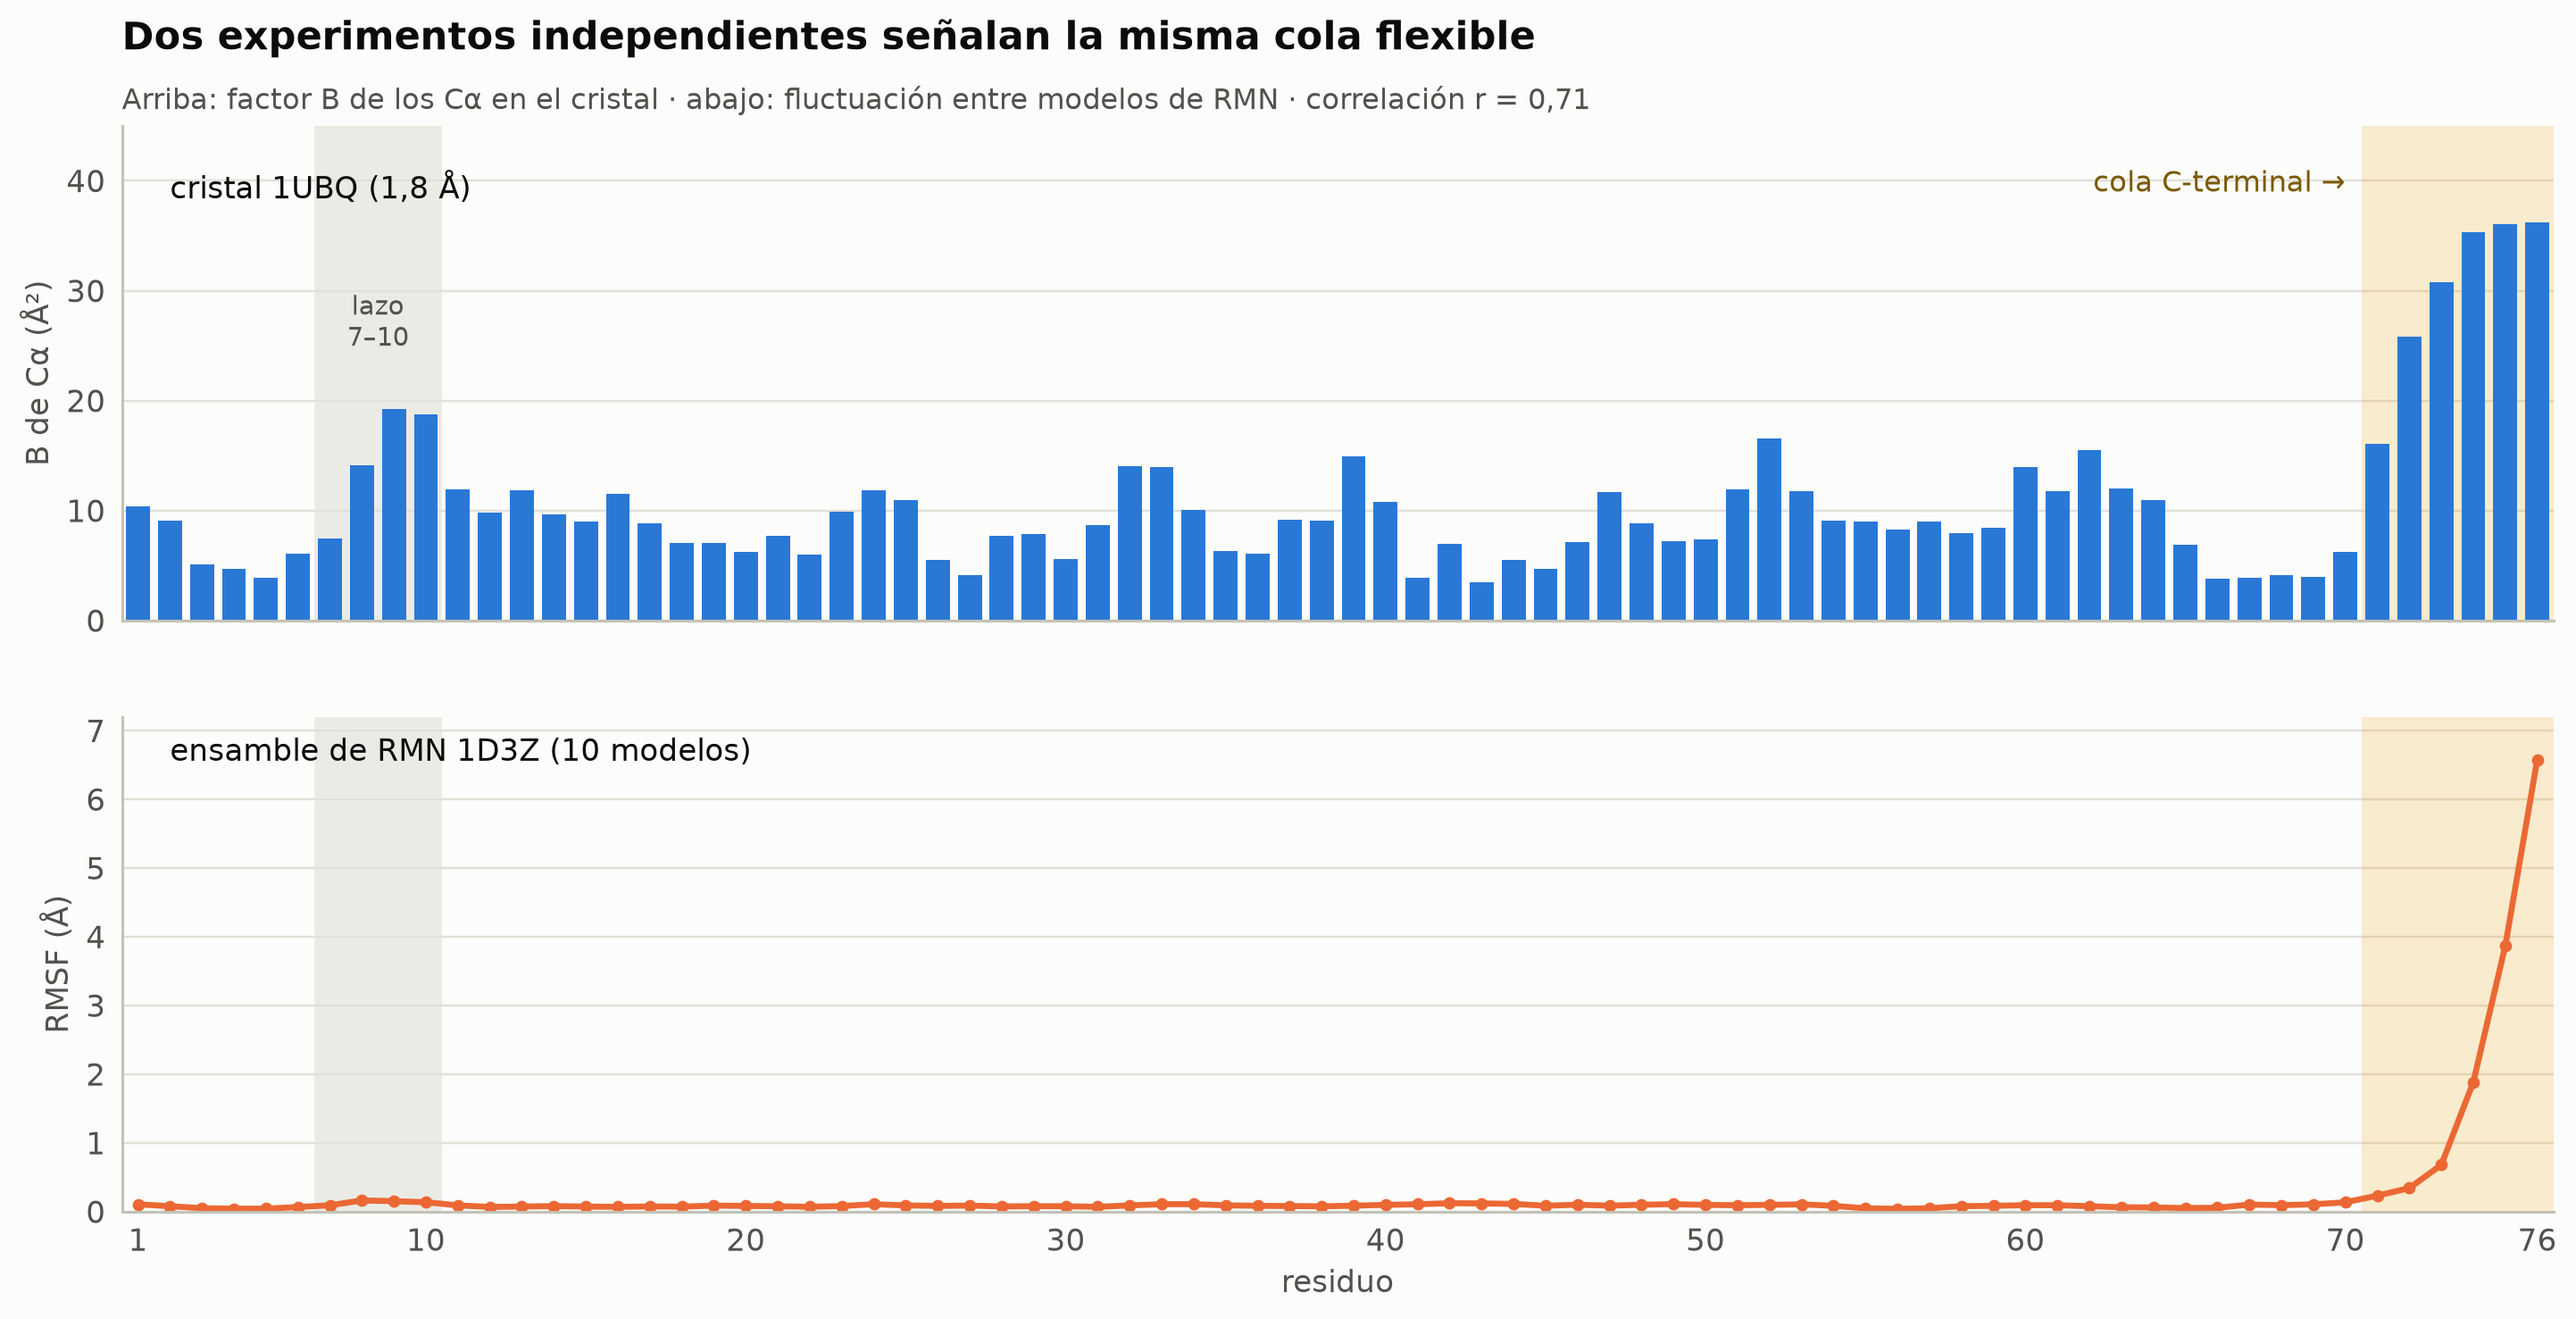

In [21]:
fig, axs = plt.subplots(2, 1, figsize=(13, 6.6), sharex=True, gridspec_kw=dict(hspace=0.12))
for ax in axs:
    ax.axvspan(70.5, 76.5, color=ec.YELLOW, alpha=0.18, lw=0)
    ax.axvspan(6.5, 10.5, color=ec.GRID, alpha=0.6, lw=0)
axs[0].bar(res_ids, Bf, color=ec.BLUE, width=0.75)
axs[0].set_ylabel("B de Cα (Å²)"); axs[0].set_ylim(0, 45)
axs[0].text(2, 41, "cristal 1UBQ (1,8 Å)", fontsize=11, color=ec.INK, va="top")
axs[0].text(70, 41, "cola C-terminal →", fontsize=10.5, color="#7a5a00", ha="right", va="top")
axs[0].text(8.5, 25, "lazo\n7–10", fontsize=9.5, color=ec.INK_2, ha="center")
axs[1].plot(res_ids, rmsf, color=ec.ORANGE, lw=2.2, marker="o", ms=3.5)
axs[1].set_ylabel("RMSF (Å)"); axs[1].set_ylim(0, 7.2); axs[1].set_xlabel("residuo")
axs[1].text(2, 6.9, "ensamble de RMN 1D3Z (10 modelos)", fontsize=11, color=ec.INK, va="top")
axs[1].set_xticks([1, 10, 20, 30, 40, 50, 60, 70, 76]); axs[1].set_xlim(0.5, 76.5)
ec.title(axs[0], "Dos experimentos independientes señalan la misma cola flexible",
         f"Arriba: factor B de los Cα en el cristal · abajo: fluctuación entre modelos de RMN · correlación r = {np.corrcoef(Bf, rmsf)[0, 1]:.2f}".replace(".", ","))
plt.show()

> 🔎 **Qué observamos.** Cada modelo de RMN difiere del cristal en un RMSD medio de **0,97 Å** (entre 0,47 y 1,55);
> si se excluye la cola C-terminal (residuos 71–76), la diferencia cae a **0,37 Å**: el núcleo es prácticamente
> idéntico en el cristal y en disolución. La figura explica por qué: el factor $B$ medio de los C$_\alpha$ es de
> **8,9 Å²** en los residuos 1–70 y de **32,8 Å²** en los residuos 72–76, y la RMSF entre modelos de RMN alcanza
> **6,6 Å** en el último residuo. Dos experimentos completamente distintos coinciden (correlación **0,71**) en que la
> cola es flexible, y ambos detectan además una flexibilidad moderada en el lazo 7–10. Lo que en cristalografía
> aparece como densidad borrosa, en RMN aparece como desacuerdo entre modelos.
>
> No es un detalle menor: la **glicina 76** de esa cola es la que se une covalentemente a las proteínas marcadas
> para su degradación en el proteasoma, una función que exige flexibilidad.

### 9.2 Véalo en 3D

La figura interactiva dibuja la traza de C$_\alpha$ del cristal coloreada por su factor $B$, sobre los 10 modelos de
RMN (en gris) superpuestos en el núcleo. **Gire la molécula y pase el cursor** por los residuos: verá su $B$, el
desplazamiento $\sqrt{\langle u^2\rangle}$ que implica y su RMSF en el ensamble.

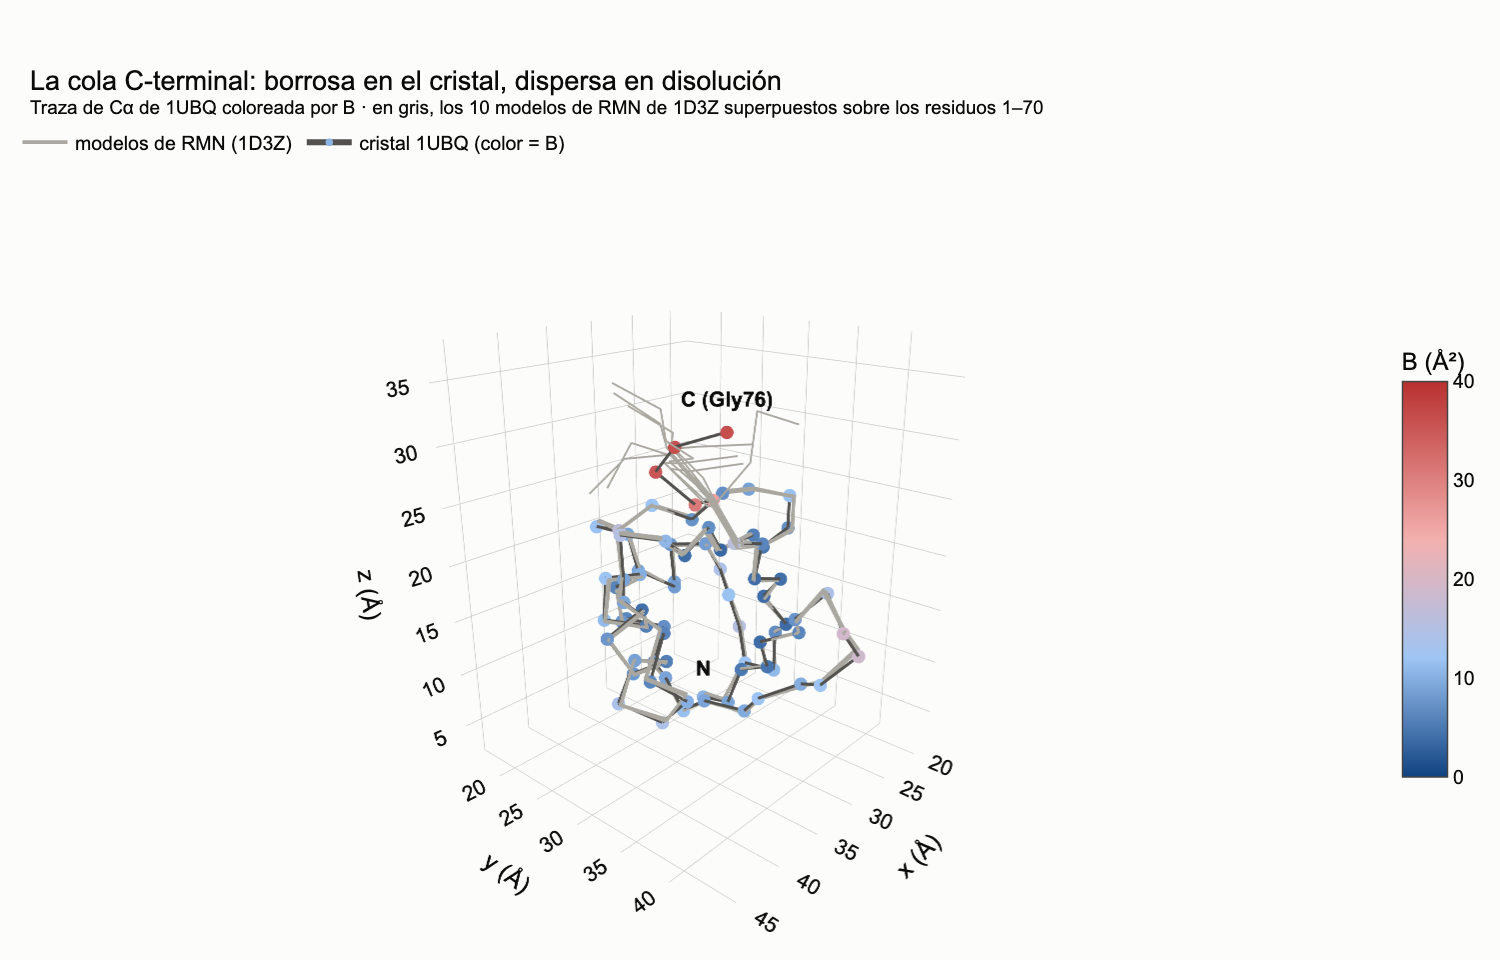

In [22]:
# Superponemos el ensamble (ya alineado entre sí) sobre el cristal usando el núcleo
Rm, tm = kabsch(ref[core], X[core])
al_on_X = al @ Rm.T + tm
fig = go.Figure()
for k, M in enumerate(al_on_X):
    fig.add_trace(go.Scatter3d(x=M[:, 0], y=M[:, 1], z=M[:, 2], mode="lines",
                               line=dict(color="#a9a79f", width=2.5), hoverinfo="skip",
                               name="modelos de RMN (1D3Z)", showlegend=(k == 0), legendgroup="nmr"))
urms = b_to_urms(Bf)
fig.add_trace(go.Scatter3d(
    x=X[:, 0], y=X[:, 1], z=X[:, 2], mode="lines+markers", name="cristal 1UBQ (color = B)",
    line=dict(color=ec.INK_2, width=4),
    marker=dict(size=5, color=Bf, colorscale=[[0, "#104281"], [0.3, "#9ec5f4"], [0.6, "#f3b0ae"], [1, "#b8302f"]],
                cmin=0, cmax=40, colorbar=dict(title="B (Å²)", len=0.6, x=1.0)),
    customdata=np.c_[res_ids, [r.get_resname() for r in ubq_res], Bf, urms, rmsf, ubq_ss_dssp],
    hovertemplate=("<b>%{customdata[1]} %{customdata[0]}</b> (SS: %{customdata[5]})<br>B = %{customdata[2]:.1f} Å²"
                   " → √⟨u²⟩ = %{customdata[3]:.2f} Å<br>RMSF en RMN = %{customdata[4]:.2f} Å<extra></extra>")))
fig.add_trace(go.Scatter3d(x=[X[0, 0], X[-1, 0]], y=[X[0, 1], X[-1, 1]], z=[X[0, 2], X[-1, 2]], mode="text",
                           text=["<b>N</b>", "<b>C (Gly76)</b>"], textfont=dict(size=14, color=ec.INK), showlegend=False,
                           hoverinfo="skip"))
fig.update_layout(
    title="La cola C-terminal: borrosa en el cristal, dispersa en disolución"
          "<br><sup>Traza de Cα de 1UBQ coloreada por B · en gris, los 10 modelos de RMN de 1D3Z superpuestos sobre los residuos 1–70</sup>",
    scene=dict(xaxis_title="x (Å)", yaxis_title="y (Å)", zaxis_title="z (Å)", aspectmode="data",
               camera=dict(eye=dict(x=1.7, y=1.5, z=0.9))),
    height=640, legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=120, l=10, r=10, b=10))
fig.show()

Si su entorno lo permite (Colab sí), el visor **py3Dmol** muestra la estructura completa en representación de
cintas (*cartoon*), descargándola directamente del RCSB en su navegador. A la izquierda, el cristal coloreado por
factor $B$ (azul = rígido, rojo = móvil); a la derecha, los 10 modelos de RMN. Si py3Dmol no está disponible, la
figura Plotly anterior cumple la misma función.

In [23]:
try:
    import py3Dmol
    HAVE_3DMOL = True
except ImportError:
    if IN_COLAB:
        %pip install -q py3Dmol
        import py3Dmol
        HAVE_3DMOL = True
    else:
        HAVE_3DMOL = False

if HAVE_3DMOL:
    view = py3Dmol.view(width=900, height=420, viewergrid=(1, 2), linked=True)
    backbone = lambda l: l.startswith("ATOM") and l[12:16].strip() in ("N", "CA", "C", "O")
    ubq_bb = "\n".join(l[:66] for l in pdb_text("1UBQ").splitlines() if backbone(l))   # sólo esqueleto: cuaderno liviano
    view.addModel(ubq_bb, "pdb", viewer=(0, 0))
    view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "rwb", "min": 40, "max": 0}}}, viewer=(0, 0))
    view.addStyle({"resi": [76], "atom": "CA"}, {"sphere": {"radius": 1.0, "color": "#eda100"}}, viewer=(0, 0))
    nmr_text = "\n".join(l[:66] for l in pdb_text("1D3Z").splitlines() if l.startswith(("MODEL", "ENDMDL")) or backbone(l))
    view.addModels(nmr_text, "pdb", viewer=(0, 1))          # un modelo por cada bloque MODEL/ENDMDL
    view.setStyle({"cartoon": {"color": "spectrum"}}, viewer=(0, 1))
    view.zoomTo()
    view.show()
    print("🖱️ Arrastre para girar · rueda para acercar · izquierda: 1UBQ por B (esfera amarilla = Gly76) · derecha: 1D3Z (10 modelos)")
else:
    print("py3Dmol no está disponible en este entorno: use la figura 3D interactiva de arriba.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

🖱️ Arrastre para girar · rueda para acercar · izquierda: 1UBQ por B (esfera amarilla = Gly76) · derecha: 1D3Z (10 modelos)


## 10. Superponer dos estructuras: el algoritmo de Kabsch

### 10.1 La intuición

Tiene dos calcos del mismo dibujo en papel transparente, uno encima del otro pero corridos y girados. Para
compararlos, primero **desliza** uno hasta que sus centros coincidan y después lo **gira** hasta que las líneas
casen lo mejor posible. Lo que sobra, lo que no casa ni deslizando ni girando, es la diferencia real entre los
dibujos. La pregunta «¿cuánto se parecen dos estructuras?» aparece una y otra vez: dos modelos de la misma
proteína, un modelo predicho frente al experimental, una proteína antes y después de unir un fármaco. Si sabemos
qué átomo corresponde a cuál, la medida natural es el **RMSD**, pero las coordenadas de dos archivos están en
sistemas de referencia arbitrarios: antes de medir hay que superponer.

**Definición (ecuación 15-rmsd del libro).** Sean $\{\mathbf p_k\}_{k=1}^N$ y $\{\mathbf q_k\}_{k=1}^N$ dos
conjuntos de puntos en $\mathbb R^3$ con correspondencia conocida. El RMSD tras superposición óptima es

$$
\mathrm{RMSD} = \min_{\mathbf R\in SO(3),\ \mathbf t\in\mathbb R^3}\ \sqrt{\frac1N\sum_{k=1}^{N}\big\lVert \mathbf R\mathbf p_k+\mathbf t-\mathbf q_k\big\rVert^2}.
$$

| Símbolo | Significado |
|---|---|
| $\mathbf p_k,\ \mathbf q_k$ | coordenadas del átomo $k$ en la estructura móvil y en la de referencia |
| $N$ | número de pares de átomos comparados (por ejemplo, los C$_\alpha$ alineados) |
| $\mathbf R$ | matriz de rotación: ortogonal ($\mathbf R^\top\mathbf R=\mathbf I$) y con $\det\mathbf R=+1$ |
| $SO(3)$ | grupo de las rotaciones propias en tres dimensiones (sin reflexiones) |
| $\mathbf t$ | vector de traslación |

Kabsch (1976) mostró que este problema, que parece exigir una búsqueda sobre todas las rotaciones posibles, tiene
**solución cerrada**. Veamos la derivación moderna, con la descomposición en valores singulares (SVD).

### 10.2 La derivación en tres pasos

**Paso 1: la traslación óptima une los centroides.** Fijada $\mathbf R$, la función
$E(\mathbf t)=\sum_k\lVert\mathbf R\mathbf p_k+\mathbf t-\mathbf q_k\rVert^2$ es cuadrática en $\mathbf t$. Igualando su
gradiente a cero,

$$
\nabla_{\mathbf t}E = 2\sum_k(\mathbf R\mathbf p_k+\mathbf t-\mathbf q_k)=\mathbf 0
\quad\Longrightarrow\quad
\mathbf t^\ast = \bar{\mathbf q}-\mathbf R\bar{\mathbf p},
$$

donde $\bar{\mathbf p}$ y $\bar{\mathbf q}$ son los centroides. Basta, pues, **centrar** ambas estructuras en el origen
y buscar sólo la rotación.

**Paso 2: minimizar el error equivale a maximizar una traza.** Con los puntos centrados, y como una rotación
conserva las normas ($\lVert\mathbf R\mathbf p_k\rVert=\lVert\mathbf p_k\rVert$),

$$
E(\mathbf R)=\sum_k\lVert\mathbf p_k\rVert^2+\sum_k\lVert\mathbf q_k\rVert^2-2\sum_k\mathbf q_k^\top\mathbf R\,\mathbf p_k
=\text{const}-2\,\operatorname{tr}\!\big(\mathbf R\,\mathbf H\big),
\qquad \mathbf H=\sum_k \mathbf p_k\mathbf q_k^\top ,
$$

usando la identidad $\mathbf q^\top\mathbf R\mathbf p=\operatorname{tr}(\mathbf R\,\mathbf p\,\mathbf q^\top)$. Minimizar $E$
equivale a maximizar $\operatorname{tr}(\mathbf R\mathbf H)$, donde $\mathbf H$ es la matriz $3\times3$ de **covarianza
cruzada** entre las dos nubes de puntos.

**Paso 3: la SVD resuelve la maximización.** Escribamos $\mathbf H=\mathbf U\boldsymbol\Sigma\mathbf V^\top$, con
$\mathbf U,\mathbf V$ ortogonales y $\boldsymbol\Sigma=\operatorname{diag}(\sigma_1,\sigma_2,\sigma_3)$,
$\sigma_1\ge\sigma_2\ge\sigma_3\ge0$. Por la propiedad cíclica de la traza,

$$
\operatorname{tr}(\mathbf R\mathbf U\boldsymbol\Sigma\mathbf V^\top)=\operatorname{tr}(\underbrace{\mathbf V^\top\mathbf R\mathbf U}_{\mathbf M}\boldsymbol\Sigma)=\sum_{j=1}^3 M_{jj}\,\sigma_j .
$$

Como $\mathbf M$ es ortogonal, $M_{jj}\le1$, y la suma es máxima cuando $\mathbf M=\mathbf I$, es decir,
$\mathbf R=\mathbf V\mathbf U^\top$. Queda un detalle: si $\det(\mathbf V\mathbf U^\top)=-1$, esa matriz es una
**reflexión**, que convertiría la proteína en su imagen especular (¡con hélices izquierdas!). La mejor rotación
propia se obtiene sacrificando el término del valor singular más pequeño.

**Teorema (algoritmo de Kabsch, ecuación 15-kabsch).** Con las estructuras centradas y
$\mathbf H=\sum_k\mathbf p_k\mathbf q_k^\top=\mathbf U\boldsymbol\Sigma\mathbf V^\top$,

$$
\boxed{\;\mathbf R^\ast=\mathbf V\,\mathbf D\,\mathbf U^\top,\qquad
\mathbf D=\operatorname{diag}\big(1,\,1,\,d\big),\qquad d=\operatorname{sign}\det(\mathbf V\mathbf U^\top)\;}
$$

$$
N\cdot\mathrm{RMSD}^2=\sum_k\lVert\mathbf p_k\rVert^2+\sum_k\lVert\mathbf q_k\rVert^2-2(\sigma_1+\sigma_2+d\,\sigma_3).
$$

| Símbolo | Significado |
|---|---|
| $\mathbf H$ | matriz de covarianza cruzada $3\times3$ entre las estructuras centradas |
| $\mathbf U,\ \mathbf V$ | matrices ortogonales de vectores singulares izquierdos y derechos de $\mathbf H$ |
| $\sigma_j$ | valores singulares de $\mathbf H$, ordenados de mayor a menor |
| $d$ | corrección de quiralidad: $+1$ si $\mathbf V\mathbf U^\top$ ya es una rotación, $-1$ si es una reflexión |

El coste es el de construir $\mathbf H$, $O(N)$, más una SVD de $3\times3$: superponer dos proteínas de mil residuos
toma microsegundos.

### 10.3 Ejemplo del libro: Kabsch a mano, en el plano

En dos dimensiones las matrices son $2\times2$ y la geometría se ve de un vistazo. La estructura móvil (5 puntos)
se construyó girando la de referencia **52°** alrededor de su centroide, trasladándola y añadiendo ruido de unas
centésimas. Según el libro, tras centrar, $\sum\lVert\mathbf p_k\rVert^2=9{,}154$, $\sum\lVert\mathbf q_k\rVert^2=9{,}064$ y

$$
\mathbf H=\begin{pmatrix}1{,}906 & -2{,}558\\ 4{,}741 & 3{,}519\end{pmatrix},
\qquad \sigma_1=5{,}905,\quad \sigma_2=3{,}190,\quad d=+1 .
$$

La fórmula del RMSD (en 2D, con $\mathbf D=\operatorname{diag}(1,d)$) da, **sin haber calculado todavía la rotación**,
$N\cdot\mathrm{RMSD}^2=9{,}154+9{,}064-2(5{,}905+3{,}190)=0{,}029$, de modo que
$\mathrm{RMSD}=\sqrt{0{,}029/5}=0{,}076$ Å. La rotación $\mathbf R^\ast=\mathbf V\mathbf U^\top$ resulta ser
$\left(\begin{smallmatrix}0{,}597 & 0{,}803\\ -0{,}803 & 0{,}597\end{smallmatrix}\right)$, un giro de $-53{,}4^\circ$: el
algoritmo recupera el giro original de 52° (en sentido contrario, para deshacerlo) con un error de algo más de un
grado, causado por el ruido. Comprobémoslo.

In [24]:
Q2 = np.array([[0.0, 0.0], [1.5, 0.3], [2.4, 1.6], [1.2, 2.5], [-0.3, 1.4]])          # referencia
th = np.deg2rad(52.0)
Rt = np.array([[math.cos(th), -math.sin(th)], [math.sin(th), math.cos(th)]])
noise = np.array([[0.08, -0.05], [-0.06, 0.07], [0.05, 0.04], [-0.07, -0.06], [0.04, 0.06]])
P2 = (Q2 - Q2.mean(0)) @ Rt.T + np.array([5.2, 0.4]) + noise                         # móvil

Pc, Qc = P2 - P2.mean(0), Q2 - Q2.mean(0)                    # paso 1: centrar
H2 = Pc.T @ Qc                                                # paso 2: covarianza cruzada
U2, S2, Vt2 = np.linalg.svd(H2)                               # paso 3: SVD
d2 = np.sign(np.linalg.det(Vt2.T @ U2.T))
R2 = Vt2.T @ np.diag([1, d2]) @ U2.T
sp, sq = (Pc ** 2).sum(), (Qc ** 2).sum()
N2 = len(P2)
print(f"Σ‖p‖² = {sp:.3f}   Σ‖q‖² = {sq:.3f}")
print(f"H = {np.round(H2, 3).tolist()}   σ = {np.round(S2, 3).tolist()}   d = {d2:+.0f}")
print(f"N·RMSD² = {sp:.3f} + {sq:.3f} − 2·({S2[0]:.3f} + {d2:.0f}·{S2[1]:.3f}) = {sp + sq - 2 * (S2[0] + d2 * S2[1]):.3f}"
      f"  →  RMSD = {math.sqrt((sp + sq - 2 * (S2[0] + d2 * S2[1])) / N2):.3f} Å")
print(f"R* = {np.round(R2, 3).tolist()}  →  giro de {math.degrees(math.atan2(R2[1, 0], R2[0, 0])):.1f}°")
print(f"RMSD antes = {rmsd(P2, Q2):.2f} Å · tras centrar = {rmsd(Pc, Qc):.2f} Å · tras Kabsch = {rmsd(Pc @ R2.T, Qc):.3f} Å")

Σ‖p‖² = 9.154   Σ‖q‖² = 9.064
H = [[1.906, -2.558], [4.741, 3.519]]   σ = [5.905, 3.19]   d = +1
N·RMSD² = 9.154 + 9.064 − 2·(5.905 + 1·3.190) = 0.029  →  RMSD = 0.076 Å
R* = [[0.597, 0.803], [-0.803, 0.597]]  →  giro de -53.4°
RMSD antes = 4.48 Å · tras centrar = 1.21 Å · tras Kabsch = 0.076 Å


> 🔎 **Qué observamos.** Todas las cifras del libro se reproducen: la traslación sola baja el RMSD de **4,48** a
> **1,21 Å**, y la rotación de Kabsch lo deja en **0,076 Å**, justo el ruido que añadimos a propósito. Fíjese en que
> el RMSD final salió de los valores singulares **antes** de construir $\mathbf R^\ast$: los programas que sólo
> necesitan el número (por ejemplo, para comparar miles de modelos) se ahorran ese paso.

La animación muestra los dos movimientos: primero la traslación que une los centroides y después el giro de
$-53{,}4^\circ$. Las líneas punteadas unen cada punto con su pareja; el panel derecho registra el RMSD.

![Kabsch en el plano: la traslación une los centroides y la rotación R* = V D Uᵀ elimina el resto (RMSD 4,48 → 1,21 → 0,08 Å)](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-15-estructural/15.1_kabsch_plano.gif)

*Kabsch en el plano: la traslación une los centroides y la rotación R* = V D Uᵀ elimina el resto (RMSD 4,48 → 1,21 → 0,08 Å)*

In [25]:
ang_star = math.atan2(R2[1, 0], R2[0, 0])
n_hold, n_tr, n_rot = 6, 16, 22
frames_total = n_hold + n_tr + n_rot + 8

def pose(f):
    """Posición de la estructura móvil en el cuadro f: traslación y luego rotación alrededor del centroide."""
    s_tr = np.clip((f - n_hold) / n_tr, 0, 1)
    s_rot = np.clip((f - n_hold - n_tr) / n_rot, 0, 1)
    s_tr, s_rot = 0.5 - 0.5 * math.cos(math.pi * s_tr), 0.5 - 0.5 * math.cos(math.pi * s_rot)
    c = P2.mean(0) + s_tr * (Q2.mean(0) - P2.mean(0))
    a_ = s_rot * ang_star
    Rf = np.array([[math.cos(a_), -math.sin(a_)], [math.sin(a_), math.cos(a_)]])
    return Pc @ Rf.T + c

hist_rmsd = [rmsd(pose(f), Q2) for f in range(frames_total)]
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw=dict(width_ratios=[1.5, 1], wspace=0.25))
ax.set_xlim(-1.2, 7.2); ax.set_ylim(-1.8, 3.2); ax.set_aspect("equal")
ax.plot(*np.vstack([Q2, Q2[:1]]).T, "-o", color=ec.BLUE, lw=2, ms=9, label="referencia q")
ax.plot(*Q2.mean(0), "+", color=ec.BLUE, ms=16, mew=2.5)
mov_line, = ax.plot([], [], "-o", color=ec.ORANGE, lw=2, ms=9, label="móvil p")
mov_c, = ax.plot([], [], "+", color=ec.ORANGE, ms=16, mew=2.5)
links = [ax.plot([], [], ":", color=ec.INK_2, lw=1)[0] for _ in range(len(Q2))]
stage = ax.text(-1.0, 3.0, "", fontsize=12, fontweight="bold", color=ec.INK, va="top")
ax.legend(loc="lower right", fontsize=10); ax.set_xlabel("x (Å)"); ax.set_ylabel("y (Å)")
ax.set_title("Kabsch en el plano (ejemplo del libro)", loc="left", fontsize=13)
ax2.set_xlim(0, frames_total - 1); ax2.set_ylim(0, 5); ax2.set_xlabel("cuadro"); ax2.set_ylabel("RMSD (Å)")
ax2.axvspan(n_hold, n_hold + n_tr, color=ec.GRID, alpha=0.6, lw=0); ax2.axvspan(n_hold + n_tr, n_hold + n_tr + n_rot, color=ec.YELLOW, alpha=0.15, lw=0)
ax2.text(n_hold + n_tr / 2, 4.7, "traslación", ha="center", fontsize=10, color=ec.INK_2)
ax2.text(n_hold + n_tr + n_rot / 2, 4.7, "rotación", ha="center", fontsize=10, color=ec.INK_2)
curve, = ax2.plot([], [], color=ec.ORANGE, lw=2.5)
val = ax2.text(0.97, 0.55, "", transform=ax2.transAxes, ha="right", fontsize=14, fontweight="bold", color=ec.INK)
ax2.set_title("El RMSD cae en dos escalones", loc="left", fontsize=13)

def update(f):
    P_ = pose(f)
    mov_line.set_data(*np.vstack([P_, P_[:1]]).T); mov_c.set_data([P_.mean(0)[0]], [P_.mean(0)[1]])
    for k, ln in enumerate(links):
        ln.set_data([P_[k, 0], Q2[k, 0]], [P_[k, 1], Q2[k, 1]])
    stage.set_text("posición inicial" if f < n_hold else "paso 1: unir centroides" if f < n_hold + n_tr
                   else "paso 2: rotar R* = V D Uᵀ" if f < n_hold + n_tr + n_rot else "superpuestas")
    curve.set_data(range(f + 1), hist_rmsd[:f + 1])
    val.set_text(f"RMSD = {hist_rmsd[f]:.2f} Å".replace(".", ","))
    return [mov_line, mov_c, *links, stage, curve, val]

ec.animate(fig, update, frames=frames_total, interval=110, name="15.1_kabsch_plano")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

### 10.4 El código del libro, en 3D, y la trampa del espejo

La función `kabsch_rmsd` del libro (programa `kabsch.py`) cabe en diez líneas. Comprobemos que da el mismo RMSD que
nuestra función `kabsch` y veamos para qué sirve la corrección $d$: superpongamos la ubiquitina sobre su **imagen
especular**.

> 🤔 **Antes de ejecutar, prediga.** Si reflejamos la ubiquitina ($z\to-z$) y le pedimos a Kabsch que la superponga
> sobre la original, ¿cuánto valdrá el RMSD? ¿Y si omitiéramos la corrección $d$?

In [26]:
def kabsch_rmsd(P, Q):
    """P, Q: arrays (N, 3) con correspondencia fila a fila (programa kabsch.py del libro)."""
    P = P - P.mean(axis=0)                 # paso 1: centrar
    Q = Q - Q.mean(axis=0)
    H = P.T @ Q                            # paso 2: covarianza 3x3
    U, S, Vt = np.linalg.svd(H)            # paso 3: SVD
    d = np.sign(np.linalg.det(Vt.T @ U.T))  # evitar reflexiones
    D = np.diag([1.0, 1.0, d])
    R = Vt.T @ D @ U.T
    diff = P @ R.T - Q
    return np.sqrt((diff ** 2).sum(axis=1).mean()), R

r_book, _ = kabsch_rmsd(models[0], X)
print(f"Modelo 1 de RMN frente al cristal: kabsch_rmsd = {r_book:.3f} Å · sup_rmsd = {sup_rmsd(models[0], X):.3f} Å")

mirror = X * np.array([1, 1, -1])                       # imagen especular
r_ok, R_ok = kabsch_rmsd(mirror, X)
Pm, Qm = mirror - mirror.mean(0), X - X.mean(0)
U_, S_, Vt_ = np.linalg.svd(Pm.T @ Qm)
R_bad = Vt_.T @ U_.T                                    # sin corrección de quiralidad
print(f"det(V Uᵀ) = {np.linalg.det(R_bad):+.0f}  → d = {np.sign(np.linalg.det(R_bad)):+.0f}")
print(f"Con la corrección d  (rotación propia): RMSD = {r_ok:.2f} Å, det R = {np.linalg.det(R_ok):+.0f}")
print(f"Sin la corrección    (reflexión):       RMSD = {rmsd(Pm @ R_bad.T, Qm):.2f} Å, det R = {np.linalg.det(R_bad):+.0f}")

Modelo 1 de RMN frente al cristal: kabsch_rmsd = 0.521 Å · sup_rmsd = 0.521 Å
det(V Uᵀ) = -1  → d = -1
Con la corrección d  (rotación propia): RMSD = 10.69 Å, det R = +1
Sin la corrección    (reflexión):       RMSD = 0.00 Å, det R = -1


> 🔎 **Qué observamos.** Sin la corrección, Kabsch «encuentra» que la imagen especular es idéntica (RMSD ≈ 0) usando
> una reflexión, que no es un movimiento físico. Con $d=-1$ el algoritmo se ve obligado a usar una rotación propia y
> el RMSD es grande: una proteína y su enantiómero **no** son la misma estructura (sus hélices giran al revés y
> ninguna enzima de la célula la reconocería). Es un error real: los modelos construidos a partir de mapas de
> distancias, que no ven la quiralidad (sección 6), pueden salir especulares.

> ✅ **Compruebe su comprensión.** ¿Por qué el paso 1 (centrar) no necesita conocer la rotación? ¿Qué pasaría con el
> RMSD de dos estructuras idénticas pero con los átomos numerados en distinto orden? *(Kabsch supone la
> correspondencia conocida; con un orden distinto, el RMSD sería enorme aunque las estructuras sean iguales. Buscar
> la correspondencia es el problema del alineamiento estructural, sección 13.)*

## 11. Más allá del RMSD: TM-score

El RMSD tiene dos defectos serios como medida de similitud global:

1. **Depende de la longitud.** Dos proteínas grandes no relacionadas tienen un RMSD mayor que dos pequeñas: el mismo
   valor no significa lo mismo para 50 que para 500 residuos.
2. **Lo dominan los peores pares.** Como promedia *cuadrados*, una cola desordenada o un dominio que gira como bisagra
   inflan el RMSD de una estructura que, en el resto, es idéntica. La ubiquitina lo ilustró: 0,97 Å con la cola,
   0,37 Å sin ella.

Zhang y Skolnick (2004) propusieron una medida que resuelve ambos problemas.

**Definición (ecuación 15-tmscore del libro).** Para una estructura modelo y una de referencia de longitud $L$, con
$N_{\mathrm{al}}$ pares de residuos alineados,

$$
\boxed{\;\mathrm{TM} = \max_{\mathbf R,\mathbf t}\ \frac1L\sum_{k=1}^{N_{\mathrm{al}}}\frac{1}{1+\left(d_k/d_0(L)\right)^2},
\qquad d_0(L)=1{,}24\sqrt[3]{L-15}-1{,}8\;}
$$

| Símbolo | Significado |
|---|---|
| $L$ | longitud de la estructura de referencia (normaliza el puntaje) |
| $N_{\mathrm{al}}$ | número de pares de residuos alineados |
| $d_k$ | distancia (Å) entre los C$_\alpha$ del par $k$ tras la superposición $(\mathbf R,\mathbf t)$ |
| $d_0(L)$ | escala de distancia que crece con la longitud; para $L=141$ vale 4,42 Å |

Cada par contribuye entre 0 y 1: casi 1 si $d_k\ll d_0$ y casi nada si $d_k\gg d_0$, de modo que los residuos muy
desviados **dejan de pesar** en lugar de dominar. El resultado va de 0 a 1; un TM-score mayor que 0,5 indica, casi
siempre, el **mismo plegamiento**. Observe el «máx»: la superposición óptima para el TM-score **no** es la de Kabsch
(que minimiza el RMSD), sino la que maximiza el número de residuos bien superpuestos; se busca de forma heurística,
aplicando Kabsch a fragmentos semilla y ampliándolos. **A mano:** para $L=141$,
$d_0=1{,}24\sqrt[3]{126}-1{,}8=1{,}24\times5{,}013-1{,}8=4{,}42$ Å; un par a 2 Å aporta $1/(1+0{,}205)=0{,}83$ y uno
a 10 Å, $1/(1+5{,}12)=0{,}16$.

In [27]:
def d0(L):
    return 1.24 * (L - 15) ** (1 / 3) - 1.8

def tmscore(P, Q, Lref):
    """TM-score con correspondencia fija (búsqueda heurística de semillas, como en el libro)."""
    d0_ = max(d0(Lref), 0.5)
    n = len(P)
    best = 0.0
    for Lf in sorted({n, n // 2, n // 4, max(n // 8, 4)}, reverse=True):
        for s0 in range(0, n - Lf + 1, max(1, Lf // 2)):
            idx = np.arange(s0, s0 + Lf)
            for _ in range(20):
                R, t = kabsch(P[idx], Q[idx])
                d = np.sqrt(((P @ R.T + t - Q) ** 2).sum(1))
                best = max(best, (1 / (1 + (d / d0_) ** 2)).sum() / Lref)
                new = np.where(d < d0_ + 1.0)[0]
                if len(new) < 3 or np.array_equal(new, idx):
                    break
                idx = new
    return best

print(f"d0(141) = {d0(141):.2f} Å · d0(76) = {d0(76):.2f} Å · d0(500) = {d0(500):.2f} Å")
print(f"Ubiquitina, modelo 1 de RMN frente al cristal: RMSD = {sup_rmsd(models[0], X):.2f} Å · TM = {tmscore(models[0], X, 76):.3f}")

d0(141) = 4.42 Å · d0(76) = 3.08 Å · d0(500) = 7.94 Å
Ubiquitina, modelo 1 de RMN frente al cristal: RMSD = 0.52 Å · TM = 0.975


### 11.1 Ejemplo del libro: mioglobina frente a hemoglobina

La **mioglobina** de cachalote (1A6M, 151 residuos) y la **cadena $\alpha$ de la hemoglobina** humana (2DN2, 141
residuos) son el ejemplo clásico de homología estructural: la primera almacena oxígeno en el músculo, la segunda lo
transporta en la sangre, y ambas lo sujetan con un grupo hemo en un plegamiento de ocho hélices. Seguimos los mismos
pasos que el libro: alineamiento global con BLOSUM62 (apertura −10, extensión −0,5, como en la lección 3), Kabsch
sobre los C$_\alpha$ emparejados, un núcleo obtenido descartando iterativamente los pares a más de 3 Å, el TM-score
normalizado por la cadena $\alpha$ y, como control, el TM-score de una correspondencia barajada al azar.

> 🤔 **Antes de ejecutar, prediga.** Con menos de un 30 % de identidad de secuencia, ¿esperaría un TM-score por
> encima o por debajo de 0,5?

In [28]:
from Bio import Align
from Bio.Align import substitution_matrices

def ca_dict(structure, chain):
    return {r.id[1]: (r["CA"].coord.astype(float), r.get_resname()) for r in protein_residues(structure[0][chain])}

hb_struct = load_structure("2DN2")
mb, hb = ca_dict(mb_struct, "A"), ca_dict(hb_struct, "A")
mk, hk = sorted(mb), sorted(hb)
smb = "".join(seq1(mb[k][1]) for k in mk); shb = "".join(seq1(hb[k][1]) for k in hk)
aligner = Align.PairwiseAligner(mode="global", substitution_matrix=substitution_matrices.load("BLOSUM62"),
                                open_gap_score=-10, extend_gap_score=-0.5)
aln = aligner.align(smb, shb)[0]
pairs = [(i, j) for (a0, a1), (b0, b1) in zip(*aln.aligned) for i, j in zip(range(a0, a1), range(b0, b1))]
ident = np.array([smb[i] == shb[j] for i, j in pairs])
P = np.array([mb[mk[i]][0] for i, _ in pairs]); Q = np.array([hb[hk[j]][0] for _, j in pairs])
print(f"mioglobina {len(smb)} res · hemoglobina α {len(shb)} res · pares alineados {len(pairs)} · identidad {ident.mean():.1%}")
r_mh = sup_rmsd(P, Q)
print(f"Kabsch sobre los {len(pairs)} pares: RMSD = {r_mh:.2f} Å")

idx = np.arange(len(P))                                  # núcleo: descartar iterativamente pares a > 3 Å
for _ in range(10):
    Rc, tc = kabsch(P[idx], Q[idx]); dcore = np.sqrt(((P @ Rc.T + tc - Q) ** 2).sum(1))
    new = np.where(dcore < 3.0)[0]
    if np.array_equal(new, idx):
        break
    idx = new
print(f"núcleo (d < 3 Å): {len(idx)} pares, RMSD = {rmsd((P @ Rc.T + tc)[idx], Q[idx]):.2f} Å")
tm_mh = tmscore(P, Q, len(shb))
print(f"TM-score (normalizado por Hb α, L = {len(shb)}) = {tm_mh:.2f}")
rng_book = np.random.default_rng(15)                     # misma semilla que el libro
Pr = P.copy(); rng_book.shuffle(Pr)
print(f"control: correspondencia barajada al azar → TM = {tmscore(Pr, Q, len(shb)):.2f}")

mioglobina 151 res · hemoglobina α 141 res · pares alineados 138 · identidad 28.3%
Kabsch sobre los 138 pares: RMSD = 1.93 Å
núcleo (d < 3 Å): 129 pares, RMSD = 1.38 Å
TM-score (normalizado por Hb α, L = 141) = 0.87
control: correspondencia barajada al azar → TM = 0.12


> 🔎 **Qué observamos.** Las cifras del libro se reproducen: 138 pares con sólo un **28,3 %** de identidad, cerca de la
> «zona crepuscular» de la lección 3; sin embargo, la superposición de Kabsch de esos 138 C$_\alpha$ da un RMSD de
> **1,93 Å**; descartando los pares a más de 3 Å quedan **129** con **1,38 Å**; y el TM-score es **0,87**,
> inequívocamente el mismo plegamiento. Con la correspondencia barajada, el TM-score cae a **0,12**. *La estructura se
> conserva mucho más que la secuencia*: ésa es la regla que justifica el modelado por homología de la próxima
> lección.

La figura muestra, par a par, la distancia tras la superposición y lo que cada par aporta al TM-score.

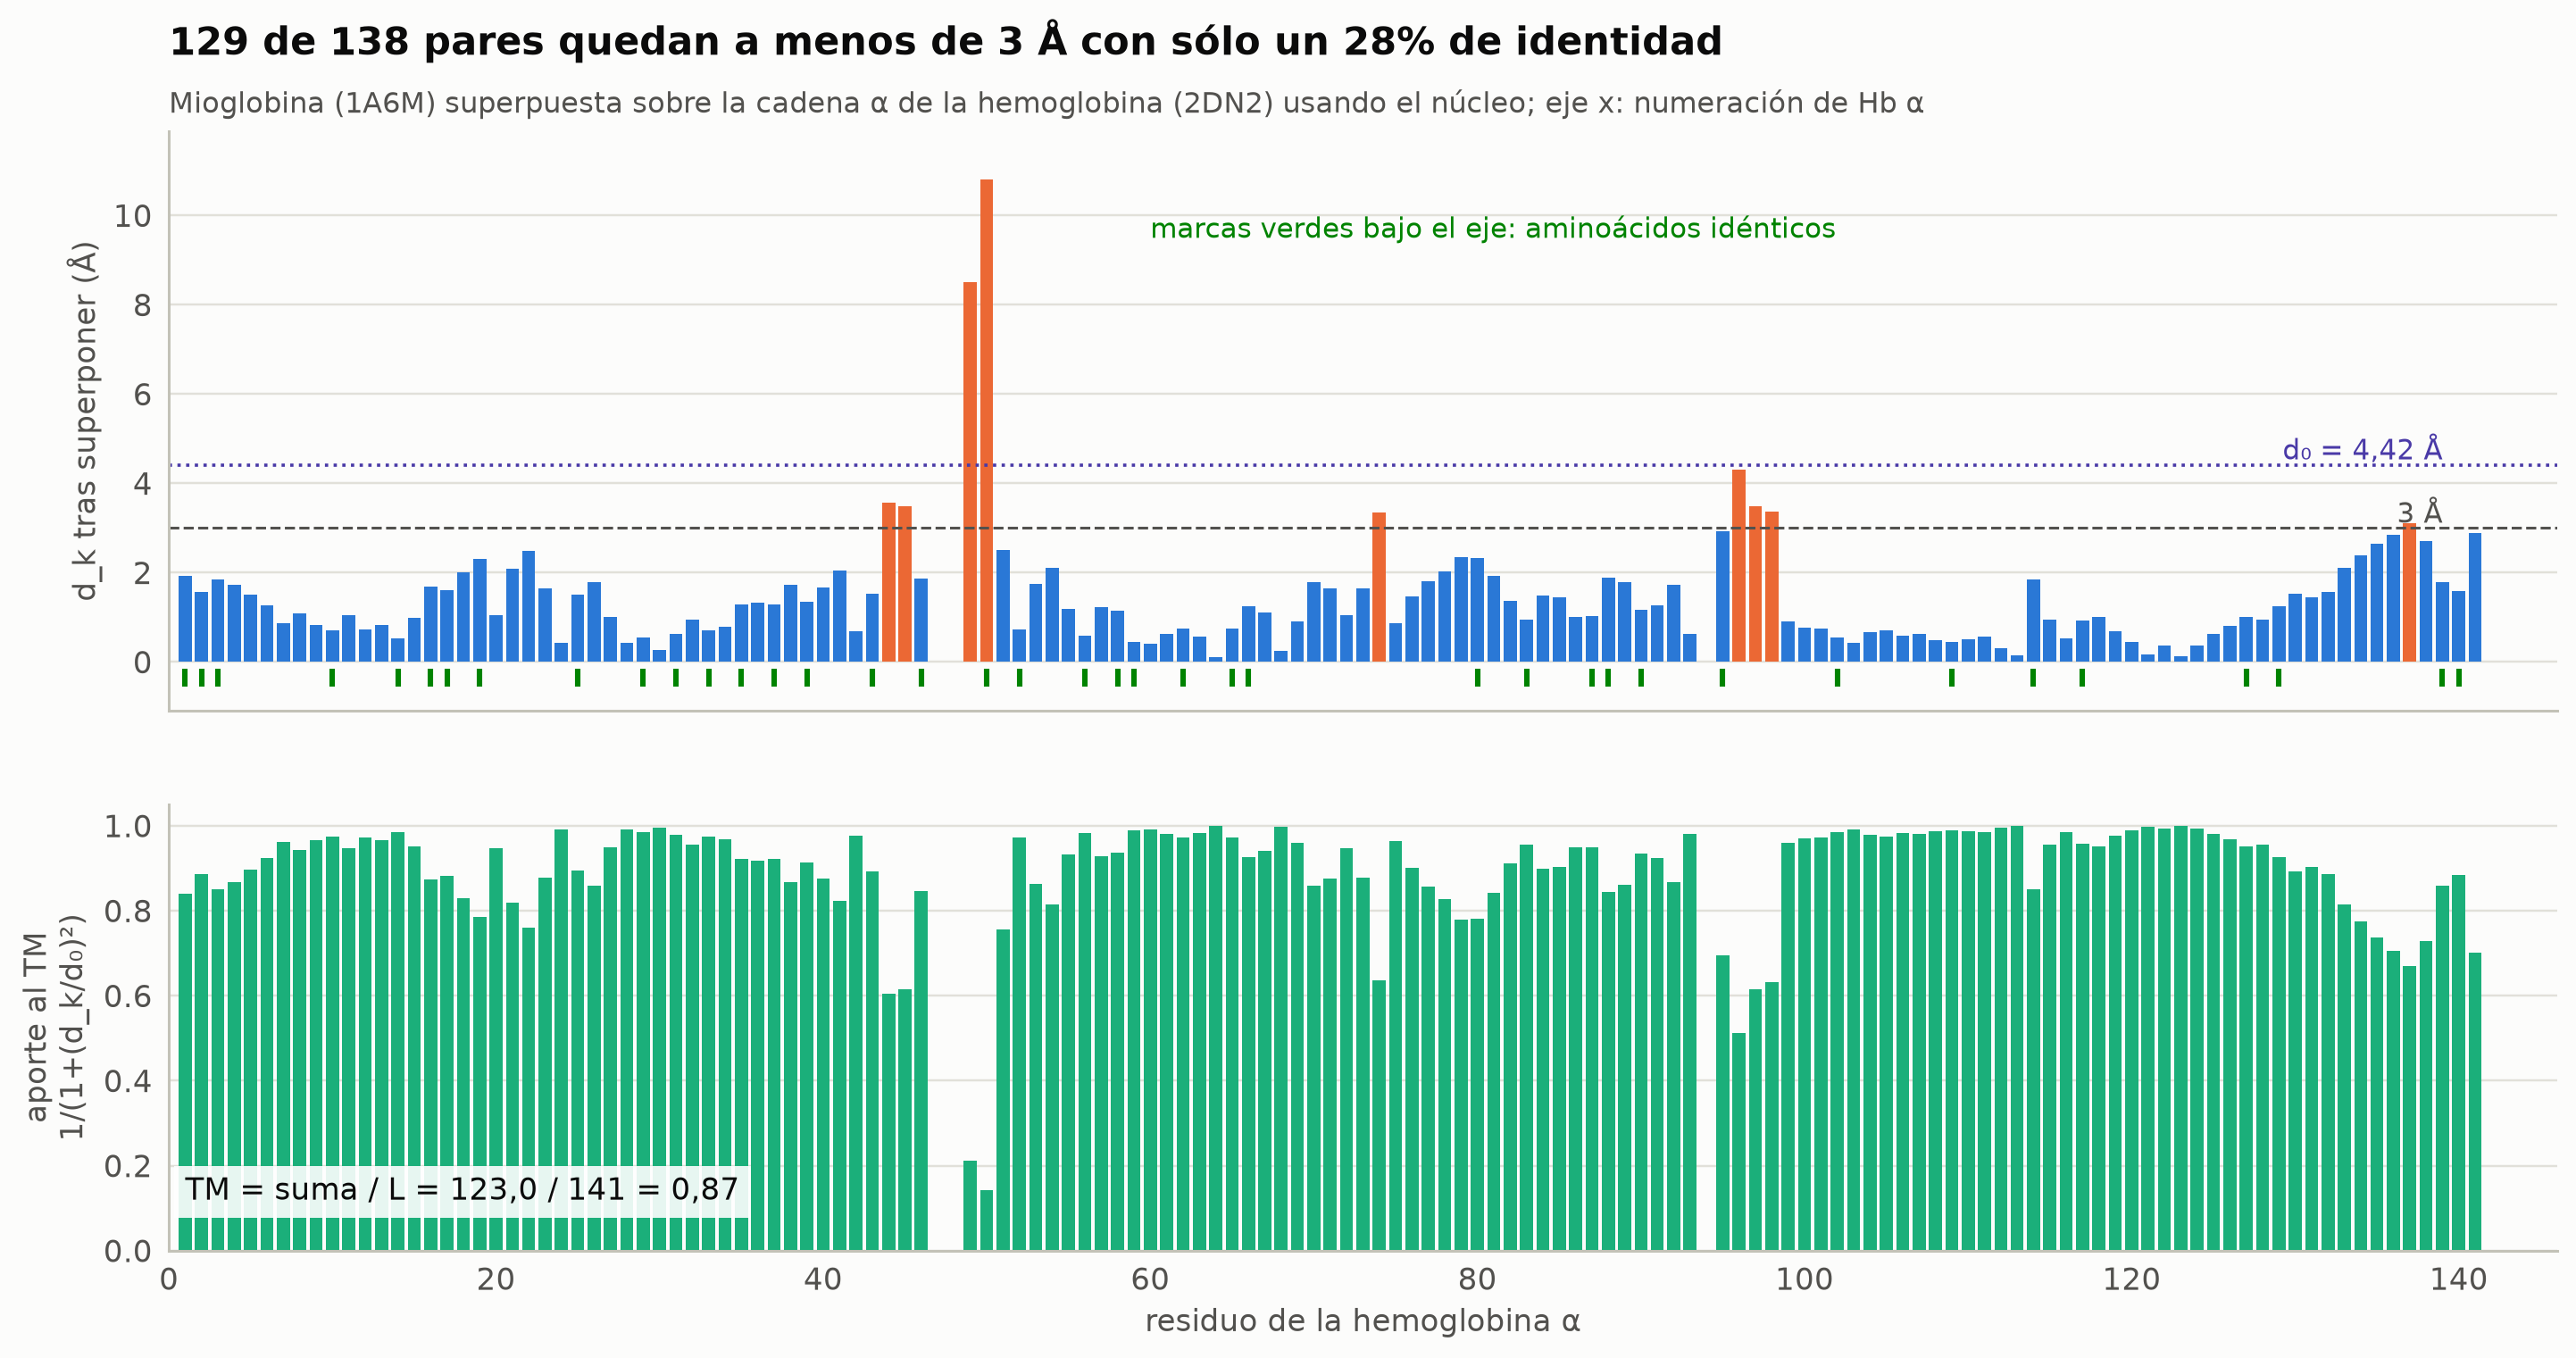

In [29]:
Pc_all = P @ Rc.T + tc                                    # superposición sobre el núcleo
dk = np.sqrt(((Pc_all - Q) ** 2).sum(1))
contrib = 1 / (1 + (dk / d0(len(shb))) ** 2)
hb_num = np.array([hk[j] for _, j in pairs])
fig, axs = plt.subplots(2, 1, figsize=(13, 6.8), sharex=True, gridspec_kw=dict(hspace=0.14, height_ratios=[1.3, 1]))
ax = axs[0]
ax.bar(hb_num, dk, color=np.where(dk < 3, ec.BLUE, ec.ORANGE), width=0.8)
ax.axhline(3, color=ec.INK_2, ls="--", lw=1); ax.text(139, 3.12, "3 Å", fontsize=10, color=ec.INK_2, ha="right")
ax.axhline(d0(len(shb)), color=ec.VIOLET, ls=":", lw=1.2); ax.text(139, d0(len(shb)) + 0.12, "d₀ = 4,42 Å", fontsize=10, color=ec.VIOLET, ha="right")
ax.scatter(hb_num[ident], np.full(ident.sum(), -0.35), marker="|", s=40, color=ec.GREEN)
ax.text(60, 9.5, "marcas verdes bajo el eje: aminoácidos idénticos", fontsize=10, color=ec.GREEN)
ax.set_ylim(-1.1, max(8, dk.max() * 1.1)); ax.set_ylabel("d_k tras superponer (Å)")
ec.title(ax, f"{len(idx)} de {len(pairs)} pares quedan a menos de 3 Å con sólo un {ident.mean():.0%} de identidad".replace(".", ","),
         "Mioglobina (1A6M) superpuesta sobre la cadena α de la hemoglobina (2DN2) usando el núcleo; eje x: numeración de Hb α")
ax = axs[1]
ax.bar(hb_num, contrib, color=ec.AQUA, width=0.8)
ax.set_ylim(0, 1.05); ax.set_ylabel("aporte al TM\n1/(1+(d_k/d₀)²)"); ax.set_xlabel("residuo de la hemoglobina α")
ax.text(1, 0.12, f"TM = suma / L = {contrib.sum():.1f} / {len(shb)} = {contrib.sum() / len(shb):.2f}".replace(".", ","),
        fontsize=11, color=ec.INK, bbox=dict(fc="white", ec="none", alpha=0.9))
ax.set_xlim(0, 146)
plt.show()

> 🔎 **Qué observamos.** Los pocos pares desviados (naranja) están en los extremos y en los lazos entre hélices; en
> el RMSD pesan con el cuadrado de su distancia, en el TM-score apenas restan. Las marcas verdes muestran que los
> aminoácidos idénticos están salpicados a lo largo de toda la cadena (entre ellos, las histidinas que sujetan el
> hemo), y aun así toda la arquitectura de hélices coincide.

**Explore en 3D.** Las dos cadenas superpuestas; pase el cursor para ver cada par alineado, su distancia y su aporte al
TM-score.

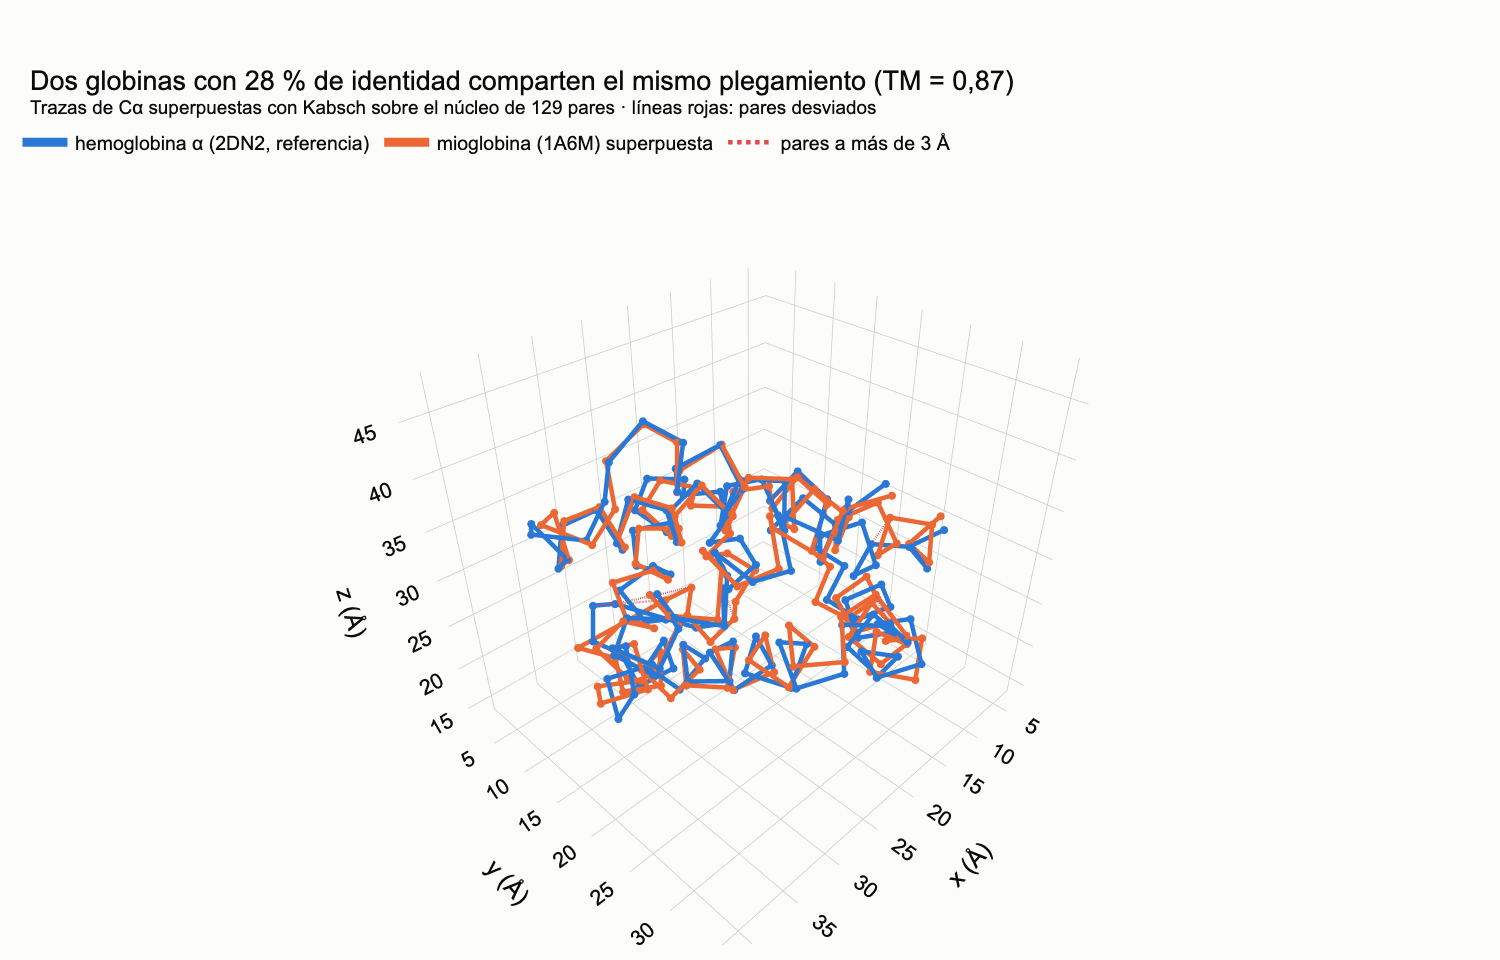

In [30]:
fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=Q[:, 0], y=Q[:, 1], z=Q[:, 2], mode="lines+markers", name="hemoglobina α (2DN2, referencia)",
    line=dict(color=ec.BLUE, width=6), marker=dict(size=3, color=ec.BLUE),
    customdata=np.c_[[f"{hb[hk[j]][1]}{hk[j]}" for _, j in pairs], [f"{mb[mk[i]][1]}{mk[i]}" for i, _ in pairs], dk, contrib,
                     np.where(ident, "idéntico", "distinto")],
    hovertemplate=("<b>Hb α %{customdata[0]}</b> ↔ Mb %{customdata[1]} (%{customdata[4]})<br>d<sub>k</sub> = %{customdata[2]:.2f} Å"
                   " · aporte al TM = %{customdata[3]:.2f}<extra></extra>")))
fig.add_trace(go.Scatter3d(
    x=Pc_all[:, 0], y=Pc_all[:, 1], z=Pc_all[:, 2], mode="lines+markers", name="mioglobina (1A6M) superpuesta",
    line=dict(color=ec.ORANGE, width=6), marker=dict(size=3, color=ec.ORANGE),
    customdata=np.c_[[f"{mb[mk[i]][1]}{mk[i]}" for i, _ in pairs], [f"{hb[hk[j]][1]}{hk[j]}" for _, j in pairs], dk],
    hovertemplate="<b>Mb %{customdata[0]}</b> ↔ Hb α %{customdata[1]}<br>d<sub>k</sub> = %{customdata[2]:.2f} Å<extra></extra>"))
far = dk > 3
xs, ys, zs = [], [], []
for k in np.where(far)[0]:
    xs += [Pc_all[k, 0], Q[k, 0], None]; ys += [Pc_all[k, 1], Q[k, 1], None]; zs += [Pc_all[k, 2], Q[k, 2], None]
fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode="lines", line=dict(color=ec.RED, width=3, dash="dot"),
                           name="pares a más de 3 Å", hoverinfo="skip"))
fig.update_layout(
    title=f"Dos globinas con 28 % de identidad comparten el mismo plegamiento (TM = {tm_mh:.2f})".replace(".", ",")
          + "<br><sup>Trazas de Cα superpuestas con Kabsch sobre el núcleo de 129 pares · líneas rojas: pares desviados</sup>",
    scene=dict(xaxis_title="x (Å)", yaxis_title="y (Å)", zaxis_title="z (Å)", aspectmode="data"),
    height=640, legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0), margin=dict(t=120, l=10, r=10, b=10))
fig.show()

La animación muestra la superposición en 3D: la mioglobina parte de su posición en su propio archivo, se traslada
hasta el centroide de la hemoglobina y gira hasta encajar, mientras la vista rota para apreciar la forma. El RMSD de los
129 pares del núcleo baja hasta 1,38 Å.

![La mioglobina (naranja) se superpone sobre la cadena α de la hemoglobina (azul): traslación, rotación de Kabsch y RMSD del núcleo](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-15-estructural/15.1_globinas_3d.gif)

*La mioglobina (naranja) se superpone sobre la cadena α de la hemoglobina (azul): traslación, rotación de Kabsch y RMSD del núcleo*

In [31]:
from scipy.spatial.transform import Rotation
rotvec = Rotation.from_matrix(Rc).as_rotvec()             # la rotación de Kabsch como eje × ángulo
pc0, qc0 = P.mean(0), Q.mean(0)
n_tr3, n_rot3, n_end3 = 14, 22, 12
F3 = n_tr3 + n_rot3 + n_end3

def pose3(f):
    s_tr = 0.5 - 0.5 * math.cos(math.pi * min(f / n_tr3, 1))
    s_rot = 0.5 - 0.5 * math.cos(math.pi * float(np.clip((f - n_tr3) / n_rot3, 0, 1)))
    Rf = Rotation.from_rotvec(s_rot * rotvec).as_matrix()
    # misma rotación final que Rc, t = qc0 − pc0·Rcᵀ aproximadamente (Kabsch del núcleo)
    center = pc0 + s_tr * ((pc0 @ Rc.T + tc) - pc0)
    return (P - pc0) @ Rf.T + center

rm_hist = [rmsd(pose3(f)[idx], Q[idx]) for f in range(F3)]
fig = plt.figure(figsize=(7.2, 6))
ax = fig.add_subplot(projection="3d")
allpts = np.vstack([Q, P])
lo, hi = allpts.min(0) - 2, allpts.max(0) + 2
ax.plot(*Q.T, color=ec.BLUE, lw=2.2, label="hemoglobina α (2DN2)")
line_m, = ax.plot([], [], [], color=ec.ORANGE, lw=2.2, label="mioglobina (1A6M)")
ax.set_xlim(lo[0], hi[0]); ax.set_ylim(lo[1], hi[1]); ax.set_zlim(lo[2], hi[2])
ax.set_box_aspect(hi - lo)
ax.set_xticklabels([]); ax.set_yticklabels([]); ax.set_zticklabels([])
ax.legend(loc="upper left", fontsize=10)
ttl = ax.text2D(0.02, 0.02, "", transform=ax.transAxes, fontsize=13, fontweight="bold", color=ec.INK)
ax.set_title("Superposición de Kabsch en 3D", loc="left", fontsize=14)

def update(f):
    M = pose3(f)
    line_m.set_data(M[:, 0], M[:, 1]); line_m.set_3d_properties(M[:, 2])
    ax.view_init(elev=18, azim=-60 + 2.5 * f)
    fase = "traslación" if f < n_tr3 else "rotación" if f < n_tr3 + n_rot3 else "superpuestas"
    ttl.set_text(f"{fase} · RMSD del núcleo = {rm_hist[f]:.2f} Å".replace(".", ","))
    return [line_m, ttl]

ec.animate(fig, update, frames=F3, interval=120, name="15.1_globinas_3d")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

## 12. 🧪 Caso real: la hemoglobina falciforme

Volvamos a la pregunta del principio. La hemoglobina S (HbS) de la anemia falciforme difiere de la normal (HbA) en un
solo aminoácido de la cadena $\beta$: **Glu6 → Val**. Tenemos dos estructuras cristalográficas de la forma
desoxigenada, que es la que polimeriza:

* **4HHB**: HbA desoxigenada, 1,74 Å (Fermi *et al.*, 1984);
* **2HBS**: HbS desoxigenada, 2,05 Å (Harrington *et al.*, 1997). Su unidad asimétrica contiene **dos tetrámeros**
  (cadenas A–D y E–H), empaquetados en el cristal igual que en la fibra.

Con las herramientas de esta clase podemos contestar dos preguntas: ¿cambia la mutación el plegamiento de la cadena
$\beta$? (Kabsch) y ¿qué toca la valina 6? (distancias entre átomos).

In [32]:
hbS = load_structure("2HBS")
bA, bS = hbA[0]["B"], hbS[0]["B"]
print(f"residuo 6 de la cadena β: HbA (4HHB) = {bA[6].get_resname()} · HbS (2HBS) = {bS[6].get_resname()}")

common = [i for i in range(1, 147) if i in bA and i in bS and "CA" in bA[i] and "CA" in bS[i]]
PA = np.array([bA[i]["CA"].coord for i in common], float); PS = np.array([bS[i]["CA"].coord for i in common], float)
RS, tS = kabsch(PS, PA)
dAS = np.sqrt(((PS @ RS.T + tS - PA) ** 2).sum(1))
print(f"Cadena β, HbS frente a HbA: {len(common)} Cα · RMSD = {rmsd(PS @ RS.T + tS, PA):.2f} Å · "
      f"TM = {tmscore(PS, PA, len(common)):.3f} · desviación del residuo 6 = {dAS[common.index(6)]:.2f} Å")

# ¿Qué átomos de OTRAS cadenas están a menos de 4,5 Å de la Val6 de cada cadena β de HbS?
ns = NeighborSearch([a for a in hbS[0].get_atoms() if a.get_parent().id[0] == " "])
contacts = []
for ch in "BDFH":
    v6 = hbS[0][ch][6]
    for atom in v6:
        for other in ns.search(atom.coord, 4.5):
            r_ = other.get_parent(); c_ = r_.get_parent().id
            if c_ != ch:
                contacts.append({"Val6 de la cadena": ch, "contacto": f"{r_.get_resname()}{r_.id[1]} (cadena {c_})",
                                 "átomo Val6": atom.get_id(), "átomo vecino": other.get_id(),
                                 "distancia (Å)": round(float(atom - other), 2)})
contacts = pd.DataFrame(contacts)
best = contacts.sort_values("distancia (Å)").groupby("contacto", sort=False).first().reset_index()
print(f"\nContactos intermoleculares de Val6: {len(best)} residuos, todos desde la Val6 de la cadena "
      f"{', '.join(contacts['Val6 de la cadena'].unique())}")
best[["contacto", "Val6 de la cadena", "átomo Val6", "átomo vecino", "distancia (Å)"]]

residuo 6 de la cadena β: HbA (4HHB) = GLU · HbS (2HBS) = VAL
Cadena β, HbS frente a HbA: 146 Cα · RMSD = 0.39 Å · TM = 0.993 · desviación del residuo 6 = 0.69 Å

Contactos intermoleculares de Val6: 5 residuos, todos desde la Val6 de la cadena H


,contacto,Val6 de la cadena,átomo Val6,átomo vecino,distancia (Å)
0,ASP73 (cadena B),H,CB,OD2,3.10
1,THR84 (cadena B),H,CG1,O,3.62
2,ALA70 (cadena B),H,CG2,CB,3.83
3,PHE85 (cadena B),H,CG2,CE1,3.95
4,LEU88 (cadena B),H,CG2,CD1,4.18


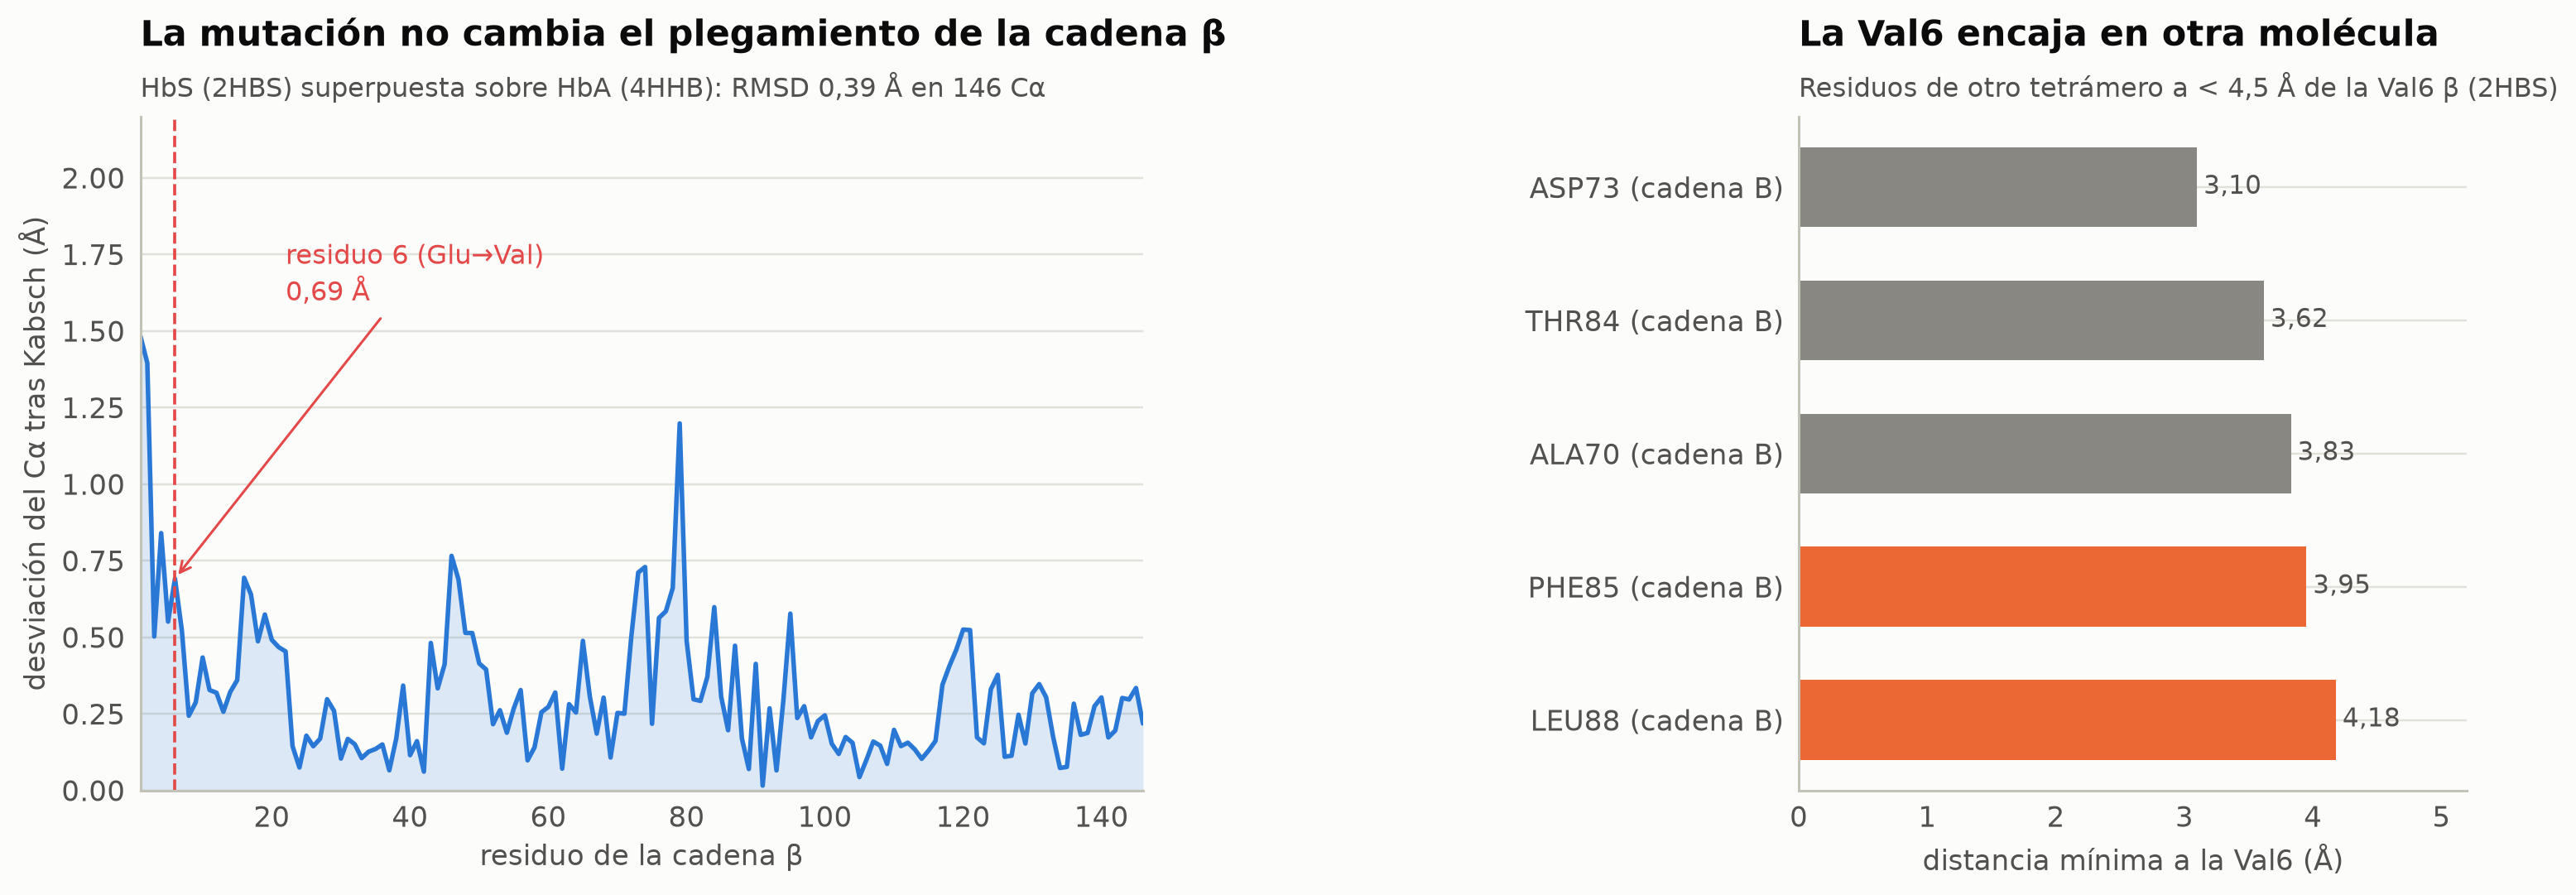

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.8), gridspec_kw=dict(width_ratios=[1.5, 1], wspace=0.3))
ax = axs[0]
ax.plot(common, dAS, color=ec.BLUE, lw=1.8)
ax.fill_between(common, dAS, color=ec.BLUE, alpha=0.15)
ax.axvline(6, color=ec.RED, lw=1.2, ls="--")
ax.annotate(f"residuo 6 (Glu→Val)\n{dAS[common.index(6)]:.2f} Å".replace(".", ","), (6, dAS[common.index(6)]),
            xytext=(22, 1.6), fontsize=10.5, color=ec.RED, arrowprops=dict(arrowstyle="->", color=ec.RED, lw=1))
ax.set_xlabel("residuo de la cadena β"); ax.set_ylabel("desviación del Cα tras Kabsch (Å)")
ax.set_xlim(1, 146); ax.set_ylim(0, max(2.2, dAS.max() * 1.15))
ec.title(ax, "La mutación no cambia el plegamiento de la cadena β",
         f"HbS (2HBS) superpuesta sobre HbA (4HHB): RMSD {rmsd(PS @ RS.T + tS, PA):.2f} Å en {len(common)} Cα".replace(".", ","))
ax = axs[1]
b2 = best.sort_values("distancia (Å)", ascending=False)
cols_ = [ec.ORANGE if any(x in c for x in ("PHE85", "LEU88")) else ec.MUTED for c in b2["contacto"]]
ax.barh(b2["contacto"], b2["distancia (Å)"], color=cols_, height=0.6)
for yv, v in enumerate(b2["distancia (Å)"]):
    ax.text(v + 0.05, yv, f"{v:.2f}".replace(".", ","), va="center", fontsize=10, color=ec.INK_2)
ax.set_xlim(0, 5.2); ax.set_xlabel("distancia mínima a la Val6 (Å)")
ec.title(ax, "La Val6 encaja en otra molécula",
         "Residuos de otro tetrámero a < 4,5 Å de la Val6 β (2HBS)")
plt.show()

> 🔎 **Qué observamos.** La cadena $\beta$ de HbS es prácticamente idéntica a la de HbA (RMSD de unas décimas de
> ångström, del orden del error de coordenadas a esta resolución): la mutación **no** deforma la proteína. Lo que
> cambia es su **superficie**. La valina 6 de una cadena $\beta$ de un tetrámero se aloja en un bolsillo
> hidrofóbico de una cadena $\beta$ del tetrámero **vecino**, formado por la **Phe85** y la **Leu88** (entre otros),
> a unos 4 Å. Ese bolsillo existe también en la HbA desoxigenada, pero el Glu6, cargado, no tiene interés en entrar
> en él; la valina, hidrofóbica, sí. Cada contacto une un tetrámero con el siguiente, y la repetición de ese
> contacto produce las fibras que deforman el glóbulo rojo. La comparación también enseña cuánto informa cada
> medida: el RMSD dice «nada cambió», y es cierto para el plegamiento; la pregunta relevante era otra.
>
> Este tipo de análisis es el punto de partida del **diseño de fármacos basado en estructura**: el voxelotor,
> aprobado en 2019 para la anemia falciforme (y retirado del mercado en 2024 por problemas de seguridad), se diseñó
> para estabilizar la forma oxigenada de la hemoglobina, que no polimeriza.
> La lección 15.3 mostrará cómo se busca computacionalmente una molécula que encaje en un bolsillo.

> ✅ **Compruebe su comprensión.** Sólo una de las cuatro Val6 del cristal toca otra molécula de la unidad asimétrica.
> ¿Significa eso que las otras tres no forman contactos en el cristal? *(No: sus vecinas son copias generadas por la
> simetría cristalográfica, que no están en el archivo; habría que generarlas con las operaciones de simetría.)*

In [34]:
if HAVE_3DMOL:
    v = py3Dmol.view(query="pdb:2HBS", width=820, height=460)
    v.setStyle({"chain": ["A", "C", "D", "E", "F", "G"]}, {"cartoon": {"color": "#e1e0d9", "opacity": 0.6}})
    v.setStyle({"chain": "B"}, {"cartoon": {"color": "#9ec5f4"}})
    v.setStyle({"chain": "H"}, {"cartoon": {"color": "#f3b0ae"}})
    v.addStyle({"chain": "H", "resi": 6}, {"stick": {"color": "#e34948", "radius": 0.35}})
    v.addStyle({"chain": "B", "resi": [85, 88]}, {"stick": {"color": "#eda100", "radius": 0.3}})
    v.zoomTo({"chain": "H", "resi": 6})
    v.show()
    print("🖱️ Rojo: Val6 de la cadena β (H) de un tetrámero · amarillo: Phe85 y Leu88 de la cadena β (B) del vecino")
else:
    print("py3Dmol no está disponible: la tabla y la figura de arriba contienen la misma información.")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

🖱️ Rojo: Val6 de la cadena β (H) de un tetrámero · amarillo: Phe85 y Leu88 de la cadena β (B) del vecino


## 13. Clasificar el universo de plegamientos: SCOP y CATH

Si la estructura se conserva más que la secuencia, clasificar las proteínas por su estructura revela parentescos que
la secuencia ya no muestra (como el de la mioglobina y la hemoglobina $\alpha$, llevado al extremo). Murzin y
colaboradores (1995) crearon **SCOP**, una clasificación jerárquica hecha en gran parte a mano, con cuatro niveles:
**clase** (todo $\alpha$, todo $\beta$, $\alpha/\beta$ con hebras y hélices alternadas, $\alpha+\beta$ con regiones
separadas), **plegamiento** (misma disposición y topología de los elementos secundarios), **superfamilia** (probable
origen evolutivo común, inferido por estructura y función aunque la identidad de secuencia sea baja) y **familia**
(homología clara de secuencia). Casi a la vez, Orengo y colaboradores (1997) presentaron **CATH**, más automatizada,
cuyo nombre enumera sus niveles: **C**lase, **A**rquitectura, **T**opología y superfamilia **H**omóloga.

Ambas clasifican **dominios**, no cadenas completas, y ambas mostraron que el número de plegamientos distintos en la
naturaleza es sorprendentemente pequeño: unos pocos miles, reutilizados una y otra vez. La ubiquitina, por ejemplo,
da nombre a un plegamiento $\alpha+\beta$ («β-agarre» o *β-grasp*) que aparece en decenas de familias sin parecido de
secuencia; las globinas son la familia arquetípica de la clase «todo $\alpha$».

> 🔬 **Para profundizar: alineamiento estructural sin correspondencia conocida.** Todo lo anterior supone que
> sabemos qué residuo corresponde a cuál (en las globinas la obtuvimos de un alineamiento de secuencia). Cuando
> comparamos proteínas sin parecido de secuencia, esa correspondencia es justamente lo que queremos averiguar: hay
> que optimizar a la vez el alineamiento y la superposición. Programas como **TM-align** alternan ambos pasos
> (alinear con programación dinámica sobre las distancias tras superponer; superponer con los pares alineados), y
> herramientas recientes como **Foldseek** traducen la geometría local a un «alfabeto estructural» de 20 letras para
> usar la maquinaria rápida de búsqueda de secuencias sobre millones de estructuras.

## 14. Ejercicios

**Ejercicio 1 (Ramachandran de una proteína toda $\alpha$).** Calcule $\phi$ y $\psi$ de la mioglobina (1A6M, cadena
A) con `backbone_angles` y la fracción de residuos en la caja $-100^\circ<\phi<-30^\circ$, $-80^\circ<\psi<-10^\circ$.
Compárela con la de la ubiquitina. ¿Cuántos residuos de la mioglobina tienen $\phi>0$ y cuántos son glicinas?

**Ejercicio 2 (factor $B$ en ångström).** ¿Qué C$_\alpha$ de la ubiquitina (1UBQ) tienen un desplazamiento
$\sqrt{\langle u^2\rangle}>1$ Å? ¿Qué valor de $B$ corresponde exactamente a 1 Å?

**Ejercicio 3 (RMSD frente a TM-score en el ensamble).** Para cada uno de los 10 modelos de 1D3Z calcule el RMSD
frente al cristal (todos los C$_\alpha$) y el TM-score ($L=76$). ¿Qué modelo es el más parecido y cuál el más
distinto según cada medida? ¿Cuánto varía cada medida entre modelos, en proporción?

**Ejercicio 4 (Kabsch a mano).** Tres puntos de referencia $\mathbf q=\{(1,0),(0,2),(-1,-2)\}$ (centroide en el
origen) y la estructura móvil $\mathbf p$ obtenida girándolos exactamente $90^\circ$ en sentido antihorario.
Construya $\mathbf H$ a mano, obtenga su SVD con NumPy y verifique que $\mathbf R^\ast$ es un giro de $-90^\circ$ y que el
RMSD es 0. ¿Cuánto valen $\sum\lVert\mathbf p_k\rVert^2$, $\sigma_1+\sigma_2$ y $d$?

**Ejercicio 5 (DSSP en una globina).** Aplique `hbond_energy_matrix` y `mini_dssp` a la mioglobina. ¿Qué fracción de
residuos queda en hélice (H o G)? ¿Aparece algún residuo en lámina? Relacione su respuesta con la clase de SCOP de
las globinas.

In [35]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
mb_res = protein_residues(mb_struct[0]["A"])
ang_mb = backbone_angles(mb_res).dropna(subset=["phi", "psi"])
box = lambda d: ((d["phi"] > -100) & (d["phi"] < -30) & (d["psi"] > -80) & (d["psi"] < -10)).mean()
print(f"mioglobina: {box(ang_mb):.0%} de residuos en la caja αR · ubiquitina: {box(ang_ubq.dropna(subset=['phi', 'psi'])):.0%}")
posm = ang_mb[ang_mb["phi"] > 0]
print(f"mioglobina: {len(posm)} residuos con φ > 0, de ellos {(posm['aa'] == 'G').sum()} glicinas:",
      ", ".join(f"{r.resname}{r.resnum}" for r in posm.itertuples()))

mioglobina: 82% de residuos en la caja αR · ubiquitina: 26%
mioglobina: 4 residuos con φ > 0, de ellos 2 glicinas: LYS79, GLY80, LYS98, GLY150


In [36]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
u = b_to_urms(Bf)
print("Cα con √⟨u²⟩ > 1 Å:", ", ".join(f"{ubq_res[k].get_resname()}{res_ids[k]} ({u[k]:.2f} Å)" for k in np.where(u > 1)[0]))
print(f"B que corresponde a 1 Å: B = 8π²/3 = {8 * np.pi ** 2 / 3:.1f} Å²")

Cα con √⟨u²⟩ > 1 Å: LEU73 (1.08 Å), ARG74 (1.16 Å), GLY75 (1.17 Å), GLY76 (1.17 Å)
B que corresponde a 1 Å: B = 8π²/3 = 26.3 Å²


In [37]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
tab = pd.DataFrame({"modelo": np.arange(1, len(models) + 1),
                    "RMSD (Å)": [sup_rmsd(M, X) for M in models],
                    "TM": [tmscore(M, X, 76) for M in models]})
print(tab.round(3).to_string(index=False))
for c in ["RMSD (Å)", "TM"]:
    print(f"{c}: mejor = modelo {tab.loc[tab[c].idxmin() if c.startswith('RMSD') else tab[c].idxmax(), 'modelo']}, "
          f"peor = modelo {tab.loc[tab[c].idxmax() if c.startswith('RMSD') else tab[c].idxmin(), 'modelo']}, "
          f"variación relativa (máx/mín) = {tab[c].max() / tab[c].min():.2f}")
print("El RMSD se triplica entre modelos por culpa de la cola; el TM-score apenas cambia unas centésimas.")

 modelo  RMSD (Å)    TM
      1     0.521 0.975
      2     0.465 0.979
      3     0.754 0.969
      4     0.905 0.966
      5     0.972 0.967
      6     1.473 0.958
      7     1.550 0.960
      8     1.463 0.949
      9     1.037 0.961
     10     0.566 0.972
RMSD (Å): mejor = modelo 2, peor = modelo 7, variación relativa (máx/mín) = 3.33
TM: mejor = modelo 2, peor = modelo 8, variación relativa (máx/mín) = 1.03
El RMSD se triplica entre modelos por culpa de la cola; el TM-score apenas cambia unas centésimas.


In [38]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
q = np.array([[1.0, 0.0], [0.0, 2.0], [-1.0, -2.0]])
R90 = np.array([[0.0, -1.0], [1.0, 0.0]])                 # giro de +90°
p = q @ R90.T
Hh = (p - p.mean(0)).T @ (q - q.mean(0))
U, S, Vt = np.linalg.svd(Hh)
d = np.sign(np.linalg.det(Vt.T @ U.T))
R = Vt.T @ np.diag([1, d]) @ U.T
print("H =\n", Hh)
print(f"σ = {S}, d = {d:+.0f}, Σ‖p‖² = {(p ** 2).sum():.1f}, σ1+σ2 = {S.sum():.1f}")
print("R* =\n", np.round(R, 3), f"\n→ giro de {math.degrees(math.atan2(R[1, 0], R[0, 0])):.0f}°, RMSD = {rmsd(p @ R.T, q):.2e}")
print("N·RMSD² = Σ‖p‖² + Σ‖q‖² − 2(σ1 + dσ2) = 10 + 10 − 2·10 = 0")

H =
 [[-2. -8.]
 [ 2.  2.]]
σ = [8.60555128 1.39444872], d = +1, Σ‖p‖² = 10.0, σ1+σ2 = 10.0
R* =
 [[-0.  1.]
 [-1. -0.]] 
→ giro de -90°, RMSD = 4.79e-16
N·RMSD² = Σ‖p‖² + Σ‖q‖² − 2(σ1 + dσ2) = 10 + 10 − 2·10 = 0


In [39]:
#@title 🔑 Solución — Ejercicio 5 { display-mode: "form" }
E_mb, _ = hbond_energy_matrix(mb_res)
ss_mb, hb_mb = mini_dssp(E_mb)
print("".join(ss_mb))
print(f"hélice (H/G) = {np.isin(ss_mb, ['H', 'G']).mean():.0%} · lámina (E) = {(ss_mb == 'E').mean():.0%} · "
      f"puentes aislados (B) = {(ss_mb == 'B').sum()}")
print("Las globinas son la familia arquetípica de la clase «todo α» de SCOP: ocho hélices y ninguna lámina.")

---HHHHHHHHHHHHHHGGGHHHHHHHHHHHHHHH-HHHHGG---------HHHHH--HHHHHHHHHHHHHHHHHHGG----HHHHHHHHHHHHH-----HHHHHHHHHHHHHHHHHH-GGG--HHHHHHHHHHHHHHHHHHHHHHHHH--


hélice (H/G) = 81% · lámina (E) = 0% · puentes aislados (B) = 0
Las globinas son la familia arquetípica de la clase «todo α» de SCOP: ocho hélices y ninguna lámina.


## 📌 Resumen

* La estructura de una proteína se describe en cuatro niveles (primaria, secundaria, terciaria, cuaternaria). El
  enlace peptídico es plano (C–N ≈ 1,33 Å, $\omega\approx180^\circ$), de modo que el esqueleto queda descrito por los
  pares $(\phi_i,\psi_i)$, calculados con $\theta=\operatorname{atan2}\big((\mathbf n_1\times\mathbf n_2)\cdot\hat{\mathbf b}_2,\ \mathbf n_1\cdot\mathbf n_2\big)$.
* El **diagrama de Ramachandran** tiene tres regiones pobladas ($\alpha_R$, $\beta$/PPII, $\alpha_L$); la glicina ocupa
  además regiones con $\phi>0$ (55 % frente a 3,4 %) y la prolina tiene $\phi$ bloqueado en $-67^\circ\pm11^\circ$. Es la
  primera herramienta de validación de un modelo.
* **DSSP** asigna la estructura secundaria a partir de una energía electrostática de puente de hidrógeno,
  $E=f\,q_1q_2(1/r_{\mathrm{ON}}+1/r_{\mathrm{CH}}-1/r_{\mathrm{OH}}-1/r_{\mathrm{CN}})<-0{,}5$ kcal/mol; los **mapas de
  contactos** resumen el plegamiento en una matriz invariante frente a rotaciones.
* Rayos X, RMN y crio-EM miden señales distintas: amplitudes de difracción (sin fases), restricciones entre núcleos
  (ensambles) y proyecciones 2D. En 2025 la crio-EM ya aporta el 41,1 % de las entradas nuevas del PDB. El formato
  oficial es **mmCIF**, un conjunto de tablas autodescriptivas.
* El **factor $B$** mide la movilidad: $\sqrt{\langle u^2\rangle}=\sqrt{3B/8\pi^2}$. En la ubiquitina, el $B$ del cristal
  y la RMSF del ensamble de RMN señalan la misma cola flexible ($r=0{,}71$).
* **Kabsch**: centrar, $\mathbf H=\sum\mathbf p_k\mathbf q_k^\top=\mathbf U\boldsymbol\Sigma\mathbf V^\top$,
  $\mathbf R^\ast=\mathbf V\mathbf D\mathbf U^\top$ con $d=\operatorname{sign}\det(\mathbf V\mathbf U^\top)$ para evitar
  reflexiones. El **RMSD** lo dominan los peores pares y depende de la longitud; el **TM-score** mide la fracción de
  estructura que coincide (> 0,5: mismo plegamiento). Mioglobina y hemoglobina $\alpha$: 28 % de identidad, TM = 0,87.
* Un cambio de un aminoácido puede no alterar el plegamiento (HbS frente a HbA, RMSD de décimas de Å) y aun así crear
  un contacto nuevo en la superficie (Val6 → Phe85/Leu88) con consecuencias clínicas.

## 📚 Lecturas y referencias

* Ramachandran, G. N., Ramakrishnan, C. y Sasisekharan, V. (1963). Stereochemistry of polypeptide chain
  configurations. *Journal of Molecular Biology*, 7(1), 95–99. https://doi.org/10.1016/S0022-2836(63)80023-6
* Pauling, L., Corey, R. B. y Branson, H. R. (1951). The structure of proteins: two hydrogen-bonded helical
  configurations of the polypeptide chain. *PNAS*, 37(4), 205–211. https://doi.org/10.1073/pnas.37.4.205
* Kendrew, J. C. *et al.* (1958). A three-dimensional model of the myoglobin molecule obtained by X-ray analysis.
  *Nature*, 181, 662–666. https://doi.org/10.1038/181662a0
* Anfinsen, C. B. (1973). Principles that govern the folding of protein chains. *Science*, 181(4096), 223–230.
  https://doi.org/10.1126/science.181.4096.223
* Kabsch, W. (1976). A solution for the best rotation to relate two sets of vectors. *Acta Crystallographica A*,
  32(5), 922–923. https://doi.org/10.1107/S0567739476001873
* Kabsch, W. y Sander, C. (1983). Dictionary of protein secondary structure: pattern recognition of hydrogen-bonded
  and geometrical features. *Biopolymers*, 22(12), 2577–2637. https://doi.org/10.1002/bip.360221211
* Vijay-Kumar, S., Bugg, C. E. y Cook, W. J. (1987). Structure of ubiquitin refined at 1.8 Å resolution. *Journal of
  Molecular Biology*, 194(3), 531–544. https://doi.org/10.1016/0022-2836(87)90679-6 (entrada 1UBQ)
* Cornilescu, G., Marquardt, J. L., Ottiger, M. y Bax, A. (1998). Validation of protein structure from anisotropic
  carbonyl chemical shifts in a dilute liquid crystalline phase. *JACS*, 120, 6836–6837.
  https://doi.org/10.1021/ja9812610 (entrada 1D3Z)
* Fermi, G., Perutz, M. F., Shaanan, B. y Fourme, R. (1984). The crystal structure of human deoxyhaemoglobin at 1.74 Å
  resolution. *Journal of Molecular Biology*, 175(2), 159–174. https://doi.org/10.1016/0022-2836(84)90472-8 (4HHB)
* Harrington, D. J., Adachi, K. y Royer, W. E. (1997). The high resolution crystal structure of deoxyhemoglobin S.
  *Journal of Molecular Biology*, 272(3), 398–407. https://doi.org/10.1006/jmbi.1997.1253 (2HBS)
* Berman, H. M. *et al.* (2000). The Protein Data Bank. *Nucleic Acids Research*, 28(1), 235–242.
  https://doi.org/10.1093/nar/28.1.235
* Burley, S. K. *et al.* (2023). RCSB Protein Data Bank (RCSB.org): delivery of experimentally-determined PDB
  structures alongside one million computed structure models of proteins from artificial intelligence/machine
  learning. *Nucleic Acids Research*, 51(D1), D488–D508. https://doi.org/10.1093/nar/gkac1077
* Kühlbrandt, W. (2014). The resolution revolution. *Science*, 343(6178), 1443–1444. https://doi.org/10.1126/science.1251652
* Zhang, Y. y Skolnick, J. (2004). Scoring function for automated assessment of protein structure template quality.
  *Proteins*, 57(4), 702–710. https://doi.org/10.1002/prot.20264
* Murzin, A. G., Brenner, S. E., Hubbard, T. y Chothia, C. (1995). SCOP: a structural classification of proteins
  database for the investigation of sequences and structures. *Journal of Molecular Biology*, 247(4), 536–540.
  https://doi.org/10.1016/S0022-2836(05)80134-2
* Orengo, C. A. *et al.* (1997). CATH – a hierarchic classification of protein domain structures. *Structure*, 5(8),
  1093–1109. https://doi.org/10.1016/S0969-2126(97)00260-8
* Cock, P. J. A. *et al.* (2009). Biopython: freely available Python tools for computational molecular biology and
  bioinformatics. *Bioinformatics*, 25(11), 1422–1423. https://doi.org/10.1093/bioinformatics/btp163
* Rego, N. y Koes, D. (2015). 3Dmol.js: molecular visualization with WebGL. *Bioinformatics*, 31(8), 1322–1324.
  https://doi.org/10.1093/bioinformatics/btu829
* Branden, C. y Tooze, J. (1999). *Introduction to Protein Structure* (2.ª ed.). Garland Science.

> ➡️ **Próxima lección (15.2):** de la secuencia a la estructura. Del modelado por homología a AlphaFold, y cómo leer
> sus medidas de confianza pLDDT y PAE, usando el RMSD y el TM-score de esta clase para evaluar los modelos.

---

☕ **¿Le sirvió esta clase?** El curso es gratuito y seguirá siéndolo; puede apoyarlo invitándome un café en [buymeacoffee.com/juvenalyosx](https://buymeacoffee.com/juvenalyosx). ¡Gracias!

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Apoye el proyecto: Buy Me a Coffee](https://img.shields.io/badge/Apoye%20el%20proyecto-Buy%20Me%20a%20Coffee-FFDD00?logo=buymeacoffee&logoColor=black)](https://buymeacoffee.com/juvenalyosx)